# Virtual Buffering: Model Development and Separate Independent Evaluations

## Purpose

This notebook develops and evaluates **virtual buffering**, a computational method for estimating the temperature reported by a physical buffered probe from routinely available air-temperature measurements. The prediction target, $T_{\mathrm{P1}}$ (`T_P1`), is the temperature measured by a calibrated, traceable glycol-buffered digital data logger. It is treated as the buffered reference measurement and not as the direct temperature of an individual vaccine vial.

## Study question

Can recent air-temperature measurements be used to estimate the delayed thermal response of the glycol-buffered reference accurately enough to support a more accessible alternative to routine physical buffered-probe monitoring in the evaluated refrigerator system?

## Temperature inputs

The analysis evaluates two temperature inputs:

1. **Refrigerator-reported BLE temperature input:** the temperature reported by the refrigerator through Bluetooth Low Energy, $T_{\mathrm{BLE}}$ (`T_BLE`).
2. **BME280 air-temperature input:** air temperature measured by the additional, centrally positioned BME280, $T_{280}$ (`T_280`).

## Modelling and evaluation strategy

Long short-term memory (LSTM) networks are the primary estimators because the buffered response depends on the preceding air-temperature sequence. Direct-input, affine, first-order thermal and Ridge temporal estimators provide ordered references that separate the contributions of static mapping, thermal inertia, linear temporal information and nonlinear sequence learning.

`data/development_dataset.xlsx` contains all observations used for model fitting, validation and development decisions. `data/holdout_dataset.xlsx` is the original independent holdout. `data/prospective_challenge_dataset.xlsx` is a later, separately collected prospective operational-challenge dataset. Neither evaluation dataset contributes observations to model fitting, scaler fitting, checkpoint selection, model selection, threshold definition or recalibration. Both are processed through the same selected feature, scaling, model and evaluation pipeline, but their results remain separately identified.

All processing is causal and segment-safe: features, rates of change and sequence windows use only current and preceding observations and cannot cross missing-data gaps or separate experimental runs. The notebook produces input-specific models, reference comparisons, pointwise and excursion metrics, transition-rate metrics, saved predictions and publication-ready figures under input-specific evaluation timelines.


## 1. Imports and Configuration


In [1]:
# 1. Reproducibility settings that must be defined before TensorFlow is imported.
import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# 2. Standard Library Imports
import platform
import random
import shutil
import warnings
from pathlib import Path

# 3. Third-Party Data and Computation Imports
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

# 4. Machine Learning and Preprocessing Imports
import sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler, StandardScaler
from scipy.optimize import minimize_scalar
from scipy.signal import lfilter
from tensorflow.keras import callbacks, layers, models, regularizers
import tensorflow as tf

# Seed Python, NumPy, TensorFlow and tf.data shuffling.
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
warnings.simplefilter("default")

try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print(f"Note: TensorFlow determinism not fully supported: {exc}")

# IOP-oriented figure dimensions: approximately 8.5 cm (single column) and 15 cm (double column).
CM_TO_INCH = 1.0 / 2.54
SINGLE_COLUMN_WIDTH_IN = 8.5 * CM_TO_INCH
DOUBLE_COLUMN_WIDTH_IN = 15.0 * CM_TO_INCH

# Publication-oriented defaults. Export line figures as PDF and use PNG only for previews.
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.figsize": (DOUBLE_COLUMN_WIDTH_IN, 3.65),
    "figure.dpi": 160,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "savefig.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9.0,
    "axes.titlesize": 10.0,
    "axes.titleweight": "bold",
    "axes.labelsize": 9.0,
    "xtick.labelsize": 8.0,
    "ytick.labelsize": 8.0,
    "legend.fontsize": 8.0,
    "figure.titlesize": 11.0,
    "lines.linewidth": 1.15,
    "lines.markersize": 4.5,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
    "axes.axisbelow": True,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Sequence histories are input-specific and expressed in minutes/rows.
T_280_LOOKBACK_MIN = 60
T_BLE_LOOKBACK_MIN = 120
MAX_MODEL_LOOKBACK = max(T_280_LOOKBACK_MIN, T_BLE_LOOKBACK_MIN)
X_SCALER_QUANTILE_RANGE = (10, 90)
VAL_FRACTION = 0.15
MIN_VALIDATION_ROWS = MAX_MODEL_LOOKBACK
GAP_THRESHOLD_SECONDS = 90
GAP_THRESHOLD_MINUTES = GAP_THRESHOLD_SECONDS / 60.0
REPO_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents)
                  if (candidate / "notebooks/virtual_buffering_analysis.ipynb").is_file()
                  and (candidate / "data/development_dataset.xlsx").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the virtual-buffering repository.")
OUTPUT_ROOT = REPO_ROOT / "outputs"
JOINT_OUTPUT_ROOT = OUTPUT_ROOT / "run_artifacts"
FINAL_OUTPUT_ROOT = OUTPUT_ROOT / "publication"
JOINT_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PUBLICATION_STAGING_ROOT = JOINT_OUTPUT_ROOT / "publication_outputs"
FINAL_PREDICTION_DIR = PUBLICATION_STAGING_ROOT / "predictions"
FINAL_FIGURE_DIR = PUBLICATION_STAGING_ROOT / "figures"
FINAL_TABLE_DIR = PUBLICATION_STAGING_ROOT / "tables"
for publication_directory in [
    FINAL_PREDICTION_DIR, FINAL_FIGURE_DIR, FINAL_TABLE_DIR,
]:
    publication_directory.mkdir(parents=True, exist_ok=True)

# Source-workbook headers are retained here for traceability and mapped after validation.
TIME_COL = "Time_stamp"
SOURCE_T_P1_COL = "P1"
SOURCE_T_280_COL = "CEN_C"
SOURCE_T_BLE_COL = "fridge_current_C"
SETPOINT_COL = "fridge_set_C"
SOURCE_REQUIRED_COLS = [
    TIME_COL, SOURCE_T_P1_COL, SOURCE_T_280_COL, SOURCE_T_BLE_COL, SETPOINT_COL,
]

# Canonical analysis names match the notation used in the manuscript.
T_P1_COL = "T_P1"
T_280_COL = "T_280"
T_BLE_COL = "T_BLE"
TARGET_COL = T_P1_COL
SEG_COL = "segment_id"
MODEL_INPUT_COLS = [T_BLE_COL, T_280_COL]
REQUIRED_DATA_COLS = [TIME_COL, T_P1_COL, T_BLE_COL, T_280_COL, SETPOINT_COL]
SOURCE_TO_ANALYSIS_COLS = {
    SOURCE_T_P1_COL: T_P1_COL,
    SOURCE_T_280_COL: T_280_COL,
    SOURCE_T_BLE_COL: T_BLE_COL,
}
PLOT_LABELS = {
    T_P1_COL: r"$T_{\mathrm{P1}}$",
    T_280_COL: r"$T_{280}$",
    T_BLE_COL: r"$T_{\mathrm{BLE}}$",
    SETPOINT_COL: r"$T_{\mathrm{set}}$",
}

# Shared 2-8 C clinical range annotation used by the overview and publication plots.
CLINICAL_RANGE = {
    "low": 2.0,
    "high": 8.0,
    "low_label": "Lo=2°C",
    "high_label": "Hi=8°C",
    "low_color": "#2E7D32",
    "high_color": "#C0392B",
    "line_style": (0, (2.0, 2.5)),
    "line_width": 1.15,
    "alpha": 0.84,
}


def add_clinical_range_lines(ax, label_fontsize=9.5):
    """Add the required 2-8 C storage range to a temperature axis."""
    ax.axhline(
        CLINICAL_RANGE["high"], color=CLINICAL_RANGE["high_color"],
        linewidth=CLINICAL_RANGE["line_width"], linestyle=CLINICAL_RANGE["line_style"],
        alpha=CLINICAL_RANGE["alpha"], zorder=1,
    )
    ax.axhline(
        CLINICAL_RANGE["low"], color=CLINICAL_RANGE["low_color"],
        linewidth=CLINICAL_RANGE["line_width"], linestyle=CLINICAL_RANGE["line_style"],
        alpha=CLINICAL_RANGE["alpha"], zorder=1,
    )
    ax.text(
        0.995, CLINICAL_RANGE["high"], CLINICAL_RANGE["high_label"],
        transform=ax.get_yaxis_transform(), ha="right", va="center",
        fontsize=label_fontsize, fontweight="bold", color=CLINICAL_RANGE["high_color"],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.0),
    )
    ax.text(
        0.995, CLINICAL_RANGE["low"], CLINICAL_RANGE["low_label"],
        transform=ax.get_yaxis_transform(), ha="right", va="center",
        fontsize=label_fontsize, fontweight="bold", color=CLINICAL_RANGE["low_color"],
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.0),
    )

# Runtime information retained with the notebook for reproducibility.
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


Python: 3.12.13
NumPy: 1.26.4
pandas: 3.0.2
scikit-learn: 1.8.0
TensorFlow: 2.21.0
GPU devices: []


## 2. Load, Validate and Segment the Analysis Datasets

This section loads the model-development workbook, the original independent holdout and the prospective operational-challenge workbook. It verifies their common five-column schema and data integrity, checks that their timestamps do not overlap, and assigns segment identifiers using the 90-second gap rule. After validation, the source headers `P1`, `CEN_C` and `fridge_current_C` are mapped in memory to the manuscript-aligned names `T_P1`, `T_280` and `T_BLE`, respectively. The source workbooks remain unchanged.


In [2]:
MODEL_DEVELOPMENT_WORKBOOK = REPO_ROOT / "data/development_dataset.xlsx"
ORIGINAL_HOLDOUT_WORKBOOK = REPO_ROOT / "data/holdout_dataset.xlsx"
PROSPECTIVE_CHALLENGE_WORKBOOK = REPO_ROOT / "data/prospective_challenge_dataset.xlsx"
NUMERIC_DATA_COLS = [T_P1_COL, T_280_COL, T_BLE_COL, SETPOINT_COL]


def load_and_validate_workbook(workbook_path, dataset_label):
    """Load one model-ready workbook and fail clearly if its structure is invalid."""
    if not workbook_path.is_file():
        raise FileNotFoundError(
            f"{dataset_label}: workbook not found at {workbook_path.resolve()}"
        )

    df = pd.read_excel(workbook_path)
    missing_columns = [col for col in SOURCE_REQUIRED_COLS if col not in df.columns]
    unexpected_columns = [col for col in df.columns if col not in SOURCE_REQUIRED_COLS]
    if missing_columns or unexpected_columns:
        raise ValueError(
            f"{dataset_label}: invalid column schema. "
            f"Missing={missing_columns}; unexpected={unexpected_columns}"
        )

    df = (
        df.loc[:, SOURCE_REQUIRED_COLS]
        .rename(columns=SOURCE_TO_ANALYSIS_COLS)
        .copy()
    )
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="raise")
    for col in NUMERIC_DATA_COLS:
        df[col] = pd.to_numeric(df[col], errors="raise")

    if df.empty:
        raise ValueError(f"{dataset_label}: workbook contains no observations.")

    missing_counts = df[REQUIRED_DATA_COLS].isna().sum()
    if int(missing_counts.sum()) > 0:
        raise ValueError(
            f"{dataset_label}: missing values detected: "
            f"{missing_counts[missing_counts.gt(0)].to_dict()}"
        )

    finite_mask = np.isfinite(df[NUMERIC_DATA_COLS].to_numpy(dtype=float))
    if not finite_mask.all():
        raise ValueError(f"{dataset_label}: non-finite numeric values detected.")

    df = df.sort_values(TIME_COL).reset_index(drop=True)
    duplicate_count = int(df[TIME_COL].duplicated().sum())
    if duplicate_count:
        raise ValueError(
            f"{dataset_label}: {duplicate_count} duplicate timestamps detected."
        )

    return df


def assign_segment_ids(df, first_segment_id=1):
    """Start a new segment after every gap longer than 90 seconds."""
    segmented = df.copy()
    gap_seconds = segmented[TIME_COL].diff().dt.total_seconds()
    segment_starts = gap_seconds.isna() | gap_seconds.gt(GAP_THRESHOLD_SECONDS)
    segmented[SEG_COL] = (
        segment_starts.cumsum().add(first_segment_id - 1).astype("int32")
    )
    return segmented, gap_seconds


df_train_dev = load_and_validate_workbook(
    MODEL_DEVELOPMENT_WORKBOOK, "model development"
)
df_original_holdout = load_and_validate_workbook(
    ORIGINAL_HOLDOUT_WORKBOOK, "original independent holdout"
)
df_prospective_challenge = load_and_validate_workbook(
    PROSPECTIVE_CHALLENGE_WORKBOOK, "prospective operational challenge"
)


def assert_no_timestamp_overlap(named_datasets):
    """Fail if any observation timestamp appears in more than one dataset role."""
    for left_index, (left_name, left_frame) in enumerate(named_datasets):
        left_times = pd.Index(left_frame[TIME_COL])
        for right_name, right_frame in named_datasets[left_index + 1:]:
            overlap = left_times.intersection(pd.Index(right_frame[TIME_COL]))
            if len(overlap):
                raise ValueError(
                    f"Timestamp overlap between {left_name} and {right_name}: "
                    f"{len(overlap):,} observations; first={overlap.min()}"
                )


assert_no_timestamp_overlap([
    ("model development", df_train_dev),
    ("original independent holdout", df_original_holdout),
    ("prospective operational challenge", df_prospective_challenge),
])

df_train_dev, train_gap_seconds = assign_segment_ids(df_train_dev)
next_segment_id = int(df_train_dev[SEG_COL].max()) + 1
df_original_holdout, original_holdout_gap_seconds = assign_segment_ids(
    df_original_holdout, first_segment_id=next_segment_id
)
next_segment_id = int(df_original_holdout[SEG_COL].max()) + 1
df_prospective_challenge, prospective_challenge_gap_seconds = assign_segment_ids(
    df_prospective_challenge, first_segment_id=next_segment_id
)


def summarize_loaded_data(dataset, workbook_path, df, gap_seconds):
    """Return a compact audit summary without modifying the measurements."""
    return {
        "dataset": dataset,
        "workbook": workbook_path.name,
        "rows": len(df),
        "measurement_columns": len(REQUIRED_DATA_COLS),
        "segments": df[SEG_COL].nunique(),
        "start": df[TIME_COL].min(),
        "end": df[TIME_COL].max(),
        "median_interval_s": gap_seconds.dropna().median(),
        "missing_values": int(df[REQUIRED_DATA_COLS].isna().sum().sum()),
        "duplicate_timestamps": int(df[TIME_COL].duplicated().sum()),
    }


load_summary = pd.DataFrame([
    summarize_loaded_data(
        "model development", MODEL_DEVELOPMENT_WORKBOOK,
        df_train_dev, train_gap_seconds,
    ),
    summarize_loaded_data(
        "original independent holdout", ORIGINAL_HOLDOUT_WORKBOOK,
        df_original_holdout, original_holdout_gap_seconds,
    ),
    summarize_loaded_data(
        "prospective operational challenge", PROSPECTIVE_CHALLENGE_WORKBOOK,
        df_prospective_challenge, prospective_challenge_gap_seconds,
    ),
])

display(load_summary)
print("Loaded and validated the development and two separate evaluation workbooks.")
print("Timestamp overlap across dataset roles: none")


,dataset,workbook,rows,measurement_columns,segments,start,end,median_interval_s,missing_values,duplicate_timestamps
0,model development,development_dataset.xlsx,280571,5,90,2025-10-12 14:40:47,2026-07-24 14:27:04,60.0,0,0
1,original independent holdout,holdout_dataset.xlsx,26810,5,3,2026-07-24 20:28:10,2026-08-12 14:22:46,60.0,0,0
2,prospective operational challenge,prospective_challenge_dataset.xlsx,2844,5,1,2026-09-01 11:41:09,2026-09-03 11:04:18,60.0,0,0


Loaded and validated the development and two separate evaluation workbooks.
Timestamp overlap across dataset roles: none


## 3. Data Characterisation and Input-Signal Overview

This section characterises the traceable glycol-buffered reference temperature, $T_{\mathrm{P1}}$, and the two temperature signals available to the virtual-buffering models: the refrigerator temperature reported through Bluetooth Low Energy, $T_{\mathrm{BLE}}$, and the centrally positioned BME280 air temperature, $T_{280}$. Descriptive statistics, reporting increments and segment-safe rates of temperature change are calculated separately for model development, the original independent holdout and the prospective operational challenge. The controller setpoint, $T_{\mathrm{set}}$, is retained only as experimental metadata and is not used as a model input.

Rates of change are calculated between consecutive observations within the same continuous segment using the actual elapsed time in minutes. The reported summaries include median and 95th-percentile absolute rates, maximum warming rate and maximum cooling rate. They quantify how rapidly each dataset changes without selecting a post-hoc transition threshold.

The overview figure is diagnostic. It preserves discontinuities between experimental segments and displays $T_{\mathrm{set}}$ as a faint contextual trace behind the three measured temperatures. The figure does not alter the one-minute data used for modelling or evaluation.


Descriptive temperature summary:


role  \
dataset                           signal                                                
Model development                 T_P1                             buffered reference   
                                  T_BLE   refrigerator-reported BLE temperature input   
                                  T_280                  BME280 air-temperature input   
                                  T_set                         experimental metadata   
Original independent holdout      T_P1                             buffered reference   
                                  T_BLE   refrigerator-reported BLE temperature input   
                                  T_280                  BME280 air-temperature input   
                                  T_set                         experimental metadata   
Prospective operational challenge T_P1                             buffered reference   
                                  T_BLE   refrigerator-reported BLE temperature input   
                                  T_280                  BME280 air-temperature input   
                                  T_set                         experimental metadata   

                                           count  mean    SD    min    Q1  \
dataset                           signal                                    
Model development                 T_P1    280571  3.69  5.85 -16.93  0.27   
                                  T_BLE   280571  2.78  7.09 -20.00  0.00   
                                  T_280   280571  3.15  6.08 -18.21 -0.05   
                                  T_set   280571  3.32  9.83 -20.00  0.00   
Original independent holdout      T_P1     26810  4.80  2.69  -4.58  4.57   
                                  T_BLE    26810  4.90  2.93  -6.00  4.00   
                                  T_280    26810  4.15  2.87  -6.00  3.36   
                                  T_set    26810  4.73  2.78  -5.00  5.00   
Prospective operational challenge T_P1      2844  5.57  2.64   0.46  4.40   
                                  T_BLE     2844  5.50  2.56  -2.00  4.00   
                                  T_280     2844  4.84  2.97  -1.00  3.38   
                                  T_set     2844  4.69  1.21   0.00  5.00   

                                          median    Q3    max  
dataset                           signal                       
Model development                 T_P1      4.69  6.02  25.08  
                                  T_BLE     4.00  6.00  22.00  
                                  T_280     3.87  5.52  24.69  
                                  T_set     5.00  8.00  20.00  
Original independent holdout      T_P1      4.95  5.44  13.08  
                                  T_BLE     5.00  6.00  12.00  
                                  T_280     4.23  5.19  13.52  
                                  T_set     5.00  5.00  10.00  
Prospective operational challenge T_P1      4.78  5.95  14.59  
                                  T_BLE     6.00  6.00  13.00  
                                  T_280     4.14  5.11  15.07  
                                  T_set     5.00  5.00   5.00

Observed reporting granularity:


role  \
dataset                           signal                                                
Model development                 T_P1                             buffered reference   
                                  T_BLE   refrigerator-reported BLE temperature input   
                                  T_280                  BME280 air-temperature input   
                                  T_set                         experimental metadata   
Original independent holdout      T_P1                             buffered reference   
                                  T_BLE   refrigerator-reported BLE temperature input   
                                  T_280                  BME280 air-temperature input   
                                  T_set                         experimental metadata   
Prospective operational challenge T_P1                             buffered reference   
                                  T_BLE   refrigerator-reported BLE temperature input   
                                  T_280                  BME280 air-temperature input   
                                  T_set                         experimental metadata   

                                          unique_values  \
dataset                           signal                  
Model development                 T_P1             4088   
                                  T_BLE              43   
                                  T_280            4114   
                                  T_set              13   
Original independent holdout      T_P1             1559   
                                  T_BLE              19   
                                  T_280            1760   
                                  T_set               7   
Prospective operational challenge T_P1              818   
                                  T_BLE              16   
                                  T_280             907   
                                  T_set               2   

                                          minimum_observed_increment_C  
dataset                           signal                                
Model development                 T_P1                            0.01  
                                  T_BLE                           1.00  
                                  T_280                           0.01  
                                  T_set                           1.00  
Original independent holdout      T_P1                            0.00  
                                  T_BLE                           1.00  
                                  T_280                           0.00  
                                  T_set                           1.00  
Prospective operational challenge T_P1                            0.01  
                                  T_BLE                           1.00  
                                  T_280                           0.01  
                                  T_set                           5.00

Segment-safe temperature rate-of-change summary:


,dataset,signal,role,rate_observations_n,median_absolute_rate_C_per_min,p95_absolute_rate_C_per_min,maximum_warming_rate_C_per_min,maximum_cooling_rate_C_per_min
0,Model development,T_P1,buffered reference,280481,0.02,0.11,1.5100,-0.6100
1,Model development,T_BLE,refrigerator-reported BLE temperature input,280481,0.00,1.00,3.0000,-12.7869
2,Model development,T_280,BME280 air-temperature input,280481,0.05,0.21,3.7300,-2.5100
3,Original independent holdout,T_P1,buffered reference,26807,0.02,0.05,0.1800,-0.2100
4,Original independent holdout,T_BLE,refrigerator-reported BLE temperature input,26807,0.00,1.00,1.0169,-1.0000
5,Original independent holdout,T_280,BME280 air-temperature input,26807,0.06,0.22,1.2000,-0.3400
6,Prospective operational challenge,T_P1,buffered reference,2843,0.02,0.06,0.1700,-0.1800
7,Prospective operational challenge,T_BLE,refrigerator-reported BLE temperature input,2843,0.00,1.00,1.0000,-1.0000
8,Prospective operational challenge,T_280,BME280 air-temperature input,2843,0.05,0.21,0.3900,-0.3300


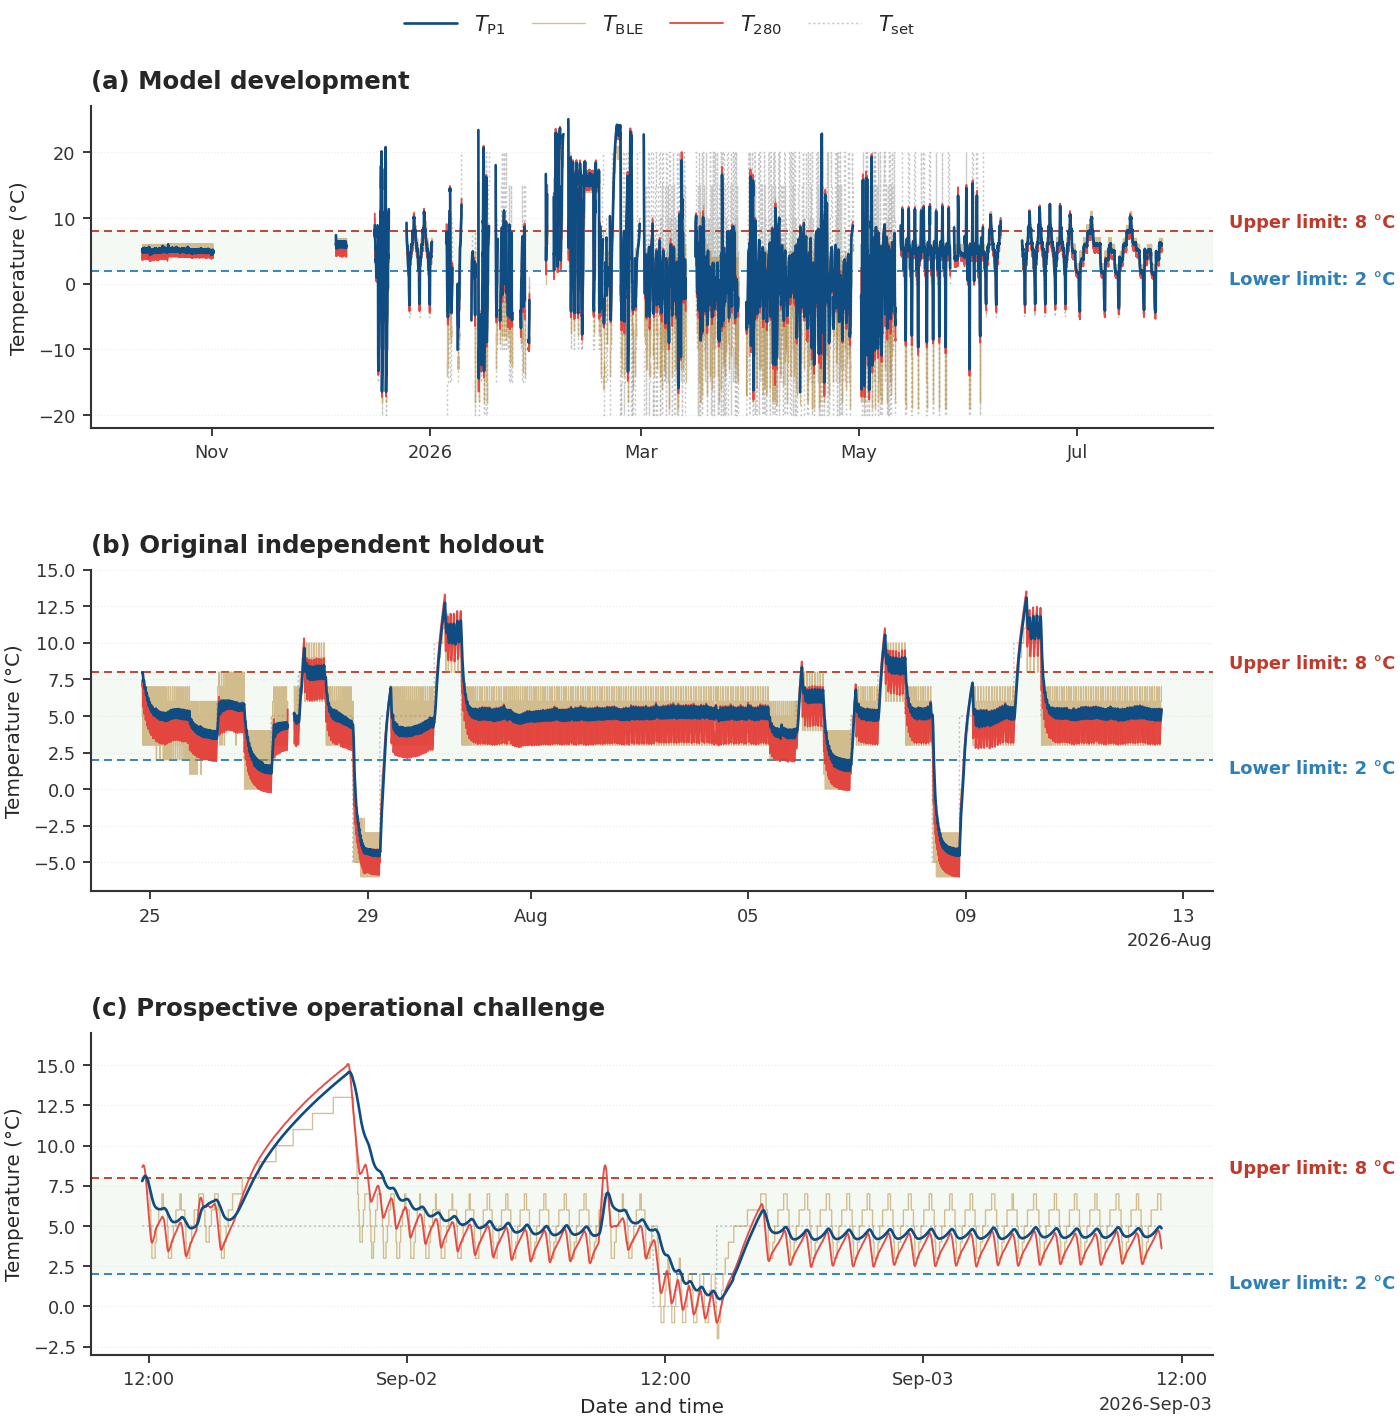

Saved descriptive summary: repository/outputs/run_artifacts/tables/temperature_descriptive_summary.csv
Saved reporting-granularity summary: repository/outputs/run_artifacts/tables/temperature_reporting_granularity.csv
Saved rate-of-change summary: repository/outputs/run_artifacts/tables/temperature_rate_of_change_summary.csv
Saved refined overview PDF: repository/outputs/run_artifacts/figures/diagnostics/temperature_signal_overview.pdf
Saved refined overview PNG: repository/outputs/run_artifacts/figures/diagnostics/temperature_signal_overview.png


In [3]:
# Characterise the target, model inputs and contextual setpoint without pooling datasets.
SUMMARY_COLS = [TARGET_COL, T_BLE_COL, T_280_COL, SETPOINT_COL]
SIGNAL_ROLES = {
    TARGET_COL: "buffered reference",
    T_280_COL: "BME280 air-temperature input",
    T_BLE_COL: "refrigerator-reported BLE temperature input",
    SETPOINT_COL: "experimental metadata",
}
SIGNAL_TABLE_LABELS = {
    TARGET_COL: "T_P1",
    T_280_COL: "T_280",
    T_BLE_COL: "T_BLE",
    SETPOINT_COL: "T_set",
}


def smallest_observed_increment(series, decimals=6):
    """Return the smallest positive difference between observed reported values."""
    values = np.sort(series.dropna().astype(float).round(decimals).unique())
    if len(values) < 2:
        return np.nan
    positive_differences = np.diff(values)
    positive_differences = positive_differences[positive_differences > 0]
    return float(positive_differences.min()) if len(positive_differences) else np.nan


def characterise_temperature_signals(df, dataset_label):
    """Return descriptive and reporting-granularity tables for one dataset."""
    descriptive = (
        df[SUMMARY_COLS]
        .describe()
        .T
        .rename(
            columns={
                "std": "SD",
                "25%": "Q1",
                "50%": "median",
                "75%": "Q3",
            }
        )
    )
    descriptive.insert(0, "role", [SIGNAL_ROLES[column] for column in descriptive.index])
    descriptive.insert(0, "signal", [SIGNAL_TABLE_LABELS[column] for column in descriptive.index])
    descriptive.insert(0, "dataset", dataset_label)
    descriptive["count"] = descriptive["count"].astype(int)
    descriptive = descriptive.set_index(["dataset", "signal"])

    reporting = pd.DataFrame(
        {
            "dataset": dataset_label,
            "signal": [SIGNAL_TABLE_LABELS[column] for column in SUMMARY_COLS],
            "role": [SIGNAL_ROLES[column] for column in SUMMARY_COLS],
            "unique_values": [int(df[column].nunique(dropna=True)) for column in SUMMARY_COLS],
            "minimum_observed_increment_C": [
                smallest_observed_increment(df[column]) for column in SUMMARY_COLS
            ],
        }
    ).set_index(["dataset", "signal"])

    return descriptive, reporting


development_descriptive, development_reporting = characterise_temperature_signals(
    df_train_dev, "Model development"
)
holdout_descriptive, holdout_reporting = characterise_temperature_signals(
    df_original_holdout, "Original independent holdout"
)
prospective_descriptive, prospective_reporting = characterise_temperature_signals(
    df_prospective_challenge, "Prospective operational challenge"
)

temperature_descriptive_summary = pd.concat([
    development_descriptive,
    holdout_descriptive,
    prospective_descriptive,
])
temperature_reporting_summary = pd.concat([
    development_reporting,
    holdout_reporting,
    prospective_reporting,
])

print("Descriptive temperature summary:")
temperature_descriptive_display = temperature_descriptive_summary.copy()
temperature_descriptive_display[
    ["mean", "SD", "min", "Q1", "median", "Q3", "max"]
] = temperature_descriptive_display[
    ["mean", "SD", "min", "Q1", "median", "Q3", "max"]
].round(2)
display(temperature_descriptive_display)

print("Observed reporting granularity:")
temperature_reporting_display = temperature_reporting_summary.copy()
temperature_reporting_display["minimum_observed_increment_C"] = (
    temperature_reporting_display["minimum_observed_increment_C"].round(2)
)
display(temperature_reporting_display)


def observed_temperature_rate_summary(df, dataset_label):
    """Summarize segment-safe temperature rates using actual elapsed minutes."""
    rows = []
    for signal in [TARGET_COL, T_BLE_COL, T_280_COL]:
        rate_parts = []
        for _, segment in df.groupby(SEG_COL, sort=False):
            ordered = segment.sort_values(TIME_COL)
            elapsed_min = ordered[TIME_COL].diff().dt.total_seconds() / 60.0
            rate = ordered[signal].diff() / elapsed_min
            valid = elapsed_min.gt(0) & np.isfinite(rate)
            rate_parts.append(rate.loc[valid].to_numpy(dtype=float))
        rates = np.concatenate(rate_parts) if rate_parts else np.array([], dtype=float)
        if not len(rates):
            raise ValueError(f"{dataset_label} {signal}: no valid rate observations.")
        rows.append({
            "dataset": dataset_label,
            "signal": SIGNAL_TABLE_LABELS[signal],
            "role": SIGNAL_ROLES[signal],
            "rate_observations_n": int(len(rates)),
            "median_absolute_rate_C_per_min": float(np.median(np.abs(rates))),
            "p95_absolute_rate_C_per_min": float(np.percentile(np.abs(rates), 95)),
            "maximum_warming_rate_C_per_min": float(np.max(rates)),
            "maximum_cooling_rate_C_per_min": float(np.min(rates)),
        })
    return pd.DataFrame(rows)


temperature_rate_summary = pd.concat([
    observed_temperature_rate_summary(df_train_dev, "Model development"),
    observed_temperature_rate_summary(
        df_original_holdout, "Original independent holdout"
    ),
    observed_temperature_rate_summary(
        df_prospective_challenge, "Prospective operational challenge"
    ),
], ignore_index=True)

print("Segment-safe temperature rate-of-change summary:")
display(temperature_rate_summary.round({
    "median_absolute_rate_C_per_min": 4,
    "p95_absolute_rate_C_per_min": 4,
    "maximum_warming_rate_C_per_min": 4,
    "maximum_cooling_rate_C_per_min": 4,
}))

tables_output_dir = JOINT_OUTPUT_ROOT / "tables"
tables_output_dir.mkdir(parents=True, exist_ok=True)
descriptive_summary_csv = tables_output_dir / "temperature_descriptive_summary.csv"
reporting_summary_csv = tables_output_dir / "temperature_reporting_granularity.csv"
rate_summary_csv = tables_output_dir / "temperature_rate_of_change_summary.csv"
temperature_descriptive_summary.to_csv(descriptive_summary_csv)
temperature_reporting_summary.to_csv(reporting_summary_csv)
temperature_rate_summary.to_csv(rate_summary_csv, index=False)


# Distinct, colour-blind-safe trace styles for the diagnostic overview.
TEMPERATURE_TRACE_STYLES = {
    T_BLE_COL: {
        "label": PLOT_LABELS[T_BLE_COL], "color": "#B58A3A",
        "linewidth": 0.60, "alpha": 0.55, "zorder": 2,
        "drawstyle": "steps-post",
    },
    T_280_COL: {
        "label": PLOT_LABELS[T_280_COL], "color": "#E53935",
        "linewidth": 0.85, "alpha": 0.90, "zorder": 3,
        "drawstyle": "default",
    },
    TARGET_COL: {
        "label": PLOT_LABELS[TARGET_COL], "color": "#0F4C81",
        "linewidth": 1.20, "alpha": 1.00, "zorder": 4,
        "drawstyle": "default",
    },
}


def aggregate_segment_for_display(segment, frequency, columns):
    """Aggregate one segment for plotting only; return full resolution when frequency is None."""
    segment = segment.sort_values(TIME_COL)
    if frequency is None:
        return segment[[TIME_COL, *columns]].copy()

    indexed = segment.set_index(TIME_COL)
    aggregated = indexed[columns].resample(frequency).median().dropna(how="all")
    return aggregated.reset_index()


def plot_temperature_segments(ax, df, display_frequency=None):
    """Plot temperature signals without connecting separate experimental segments."""
    first_segment = True
    for _, segment in df.groupby(SEG_COL, sort=False):
        display_segment = aggregate_segment_for_display(
            segment,
            display_frequency,
            [TARGET_COL, T_280_COL, T_BLE_COL],
        )
        for column, style in TEMPERATURE_TRACE_STYLES.items():
            ax.plot(
                display_segment[TIME_COL],
                display_segment[column],
                label=style["label"] if first_segment else "_nolegend_",
                color=style["color"],
                linewidth=style["linewidth"],
                alpha=style["alpha"],
                zorder=style["zorder"],
                drawstyle=style["drawstyle"],
                solid_capstyle="round",
            )
        first_segment = False


def plot_setpoint_segments(ax, df, display_frequency=None):
    """Plot contextual controller setpoints without connecting experimental segments."""
    first_segment = True
    for _, segment in df.groupby(SEG_COL, sort=False):
        segment = segment.sort_values(TIME_COL)
        if display_frequency is None:
            display_segment = segment[[TIME_COL, SETPOINT_COL]].copy()
        else:
            display_segment = (
                segment.set_index(TIME_COL)[[SETPOINT_COL]]
                .resample(display_frequency)
                .last()
                .dropna(how="all")
                .reset_index()
            )
        ax.step(
            display_segment[TIME_COL],
            display_segment[SETPOINT_COL],
            where="post",
            label=PLOT_LABELS[SETPOINT_COL] if first_segment else "_nolegend_",
            color="#5B5B5B",
            linewidth=0.65,
            linestyle=(0, (1.5, 1.8)),
            alpha=0.34,
            zorder=1,
        )
        first_segment = False


def set_temperature_limits(ax, df):
    """Use dataset-specific limits so each panel retains useful vertical detail."""
    values = df[[TARGET_COL, T_280_COL, T_BLE_COL]].to_numpy(dtype=float)
    lower = float(np.nanmin(values))
    upper = float(np.nanmax(values))
    padding = max(1.0, 0.04 * (upper - lower))
    ax.set_ylim(np.floor(lower - padding), np.ceil(upper + padding))


with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.sans-serif": ["DejaVu Sans"],
}):
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(9.6, 9.4),
        sharey=False,
    )

    figure_groups = [
        (axes[0], df_train_dev, "(a) Model development", "30min"),
        (axes[1], df_original_holdout, "(b) Original independent holdout", None),
        (
            axes[2], df_prospective_challenge,
            "(c) Prospective operational challenge", None,
        ),
    ]

    for ax, dataset, title, display_frequency in figure_groups:
        # The setpoint is contextual metadata and is deliberately kept faint and behind the measurements.
        plot_setpoint_segments(ax, dataset, display_frequency)
        plot_temperature_segments(ax, dataset, display_frequency)

        # Green shading denotes the recommended 2–8 °C refrigerated-vaccine range.
        ax.axhspan(
            CLINICAL_RANGE["low"],
            CLINICAL_RANGE["high"],
            color="#DFF0DF",
            alpha=0.34,
            zorder=0,
        )
        # Red and blue boundaries distinguish the upper (hot) and lower (cold) limits.
        ax.axhline(
            CLINICAL_RANGE["high"], color="#C0392B", linewidth=0.90,
            linestyle=(0, (4.0, 2.5)), alpha=0.92, zorder=1,
        )
        ax.axhline(
            CLINICAL_RANGE["low"], color="#2C7FB8", linewidth=0.90,
            linestyle=(0, (4.0, 2.5)), alpha=0.92, zorder=1,
        )
        ax.text(
            1.015,
            CLINICAL_RANGE["high"],
            "Upper limit: 8 °C",
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="bottom",
            fontsize=8.0,
            fontweight="semibold",
            color="#C0392B",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, pad=1.0),
            zorder=6,
            clip_on=False,
        )
        ax.text(
            1.015,
            CLINICAL_RANGE["low"],
            "Lower limit: 2 °C",
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="top",
            fontsize=8.0,
            fontweight="semibold",
            color="#2C7FB8",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, pad=1.0),
            zorder=6,
            clip_on=False,
        )

        set_temperature_limits(ax, dataset)
        ax.set_title(title, loc="left", fontsize=11.0, fontweight="semibold", pad=8)
        ax.set_ylabel("Temperature (°C)")
        ax.grid(axis="y", linestyle=":", color="#D7DCE1", linewidth=0.55)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=7))
        ax.xaxis.set_major_formatter(
            mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
        )

    axes[-1].set_xlabel("Date and time")

    handles, labels = axes[0].get_legend_handles_labels()
    handle_by_label = dict(zip(labels, handles))
    legend_labels = [
        PLOT_LABELS[TARGET_COL],
        PLOT_LABELS[T_BLE_COL],
        PLOT_LABELS[T_280_COL],
        PLOT_LABELS[SETPOINT_COL],
    ]
    legend_handles = [handle_by_label[label] for label in legend_labels]
    fig.legend(
        legend_handles,
        legend_labels,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.46, 0.985),
        handlelength=2.5,
        columnspacing=1.25,
        fontsize=9.5,
    )
    sns.despine(fig=fig)
    for ax in axes:
        ax.spines["left"].set_color("#333333")
        ax.spines["bottom"].set_color("#333333")
        ax.spines["left"].set_linewidth(0.95)
        ax.spines["bottom"].set_linewidth(0.95)
        ax.tick_params(axis="both", colors="#333333", width=0.85)
    fig.subplots_adjust(top=0.91, bottom=0.08, left=0.09, right=0.82, hspace=0.44)

    overview_output_dir = JOINT_OUTPUT_ROOT / "figures" / "diagnostics"
    overview_output_dir.mkdir(parents=True, exist_ok=True)
    refined_overview_pdf = overview_output_dir / "temperature_signal_overview.pdf"
    refined_overview_png = overview_output_dir / "temperature_signal_overview.png"
    fig.savefig(refined_overview_pdf)
    fig.savefig(refined_overview_png, dpi=600)
    plt.show()

print("Saved descriptive summary:", descriptive_summary_csv.resolve())
print("Saved reporting-granularity summary:", reporting_summary_csv.resolve())
print("Saved rate-of-change summary:", rate_summary_csv.resolve())
print("Saved refined overview PDF:", refined_overview_pdf.resolve())
print("Saved refined overview PNG:", refined_overview_png.resolve())


## 4. Causal, Input-Specific Feature Engineering

Virtual buffering is treated as a causal temporal-estimation problem. Every engineered feature is calculated independently within a continuous experimental segment so rolling statistics and exponentially weighted histories reset at every recording gap. No future observation is used.

The refrigerator-reported BLE input retains additional rolling statistics because the controller reports whole-degree values. The BME280 input retains the smaller feature set supported by the development analysis. The controller setpoint is excluded from both feature sets so the estimators learn from measured temperature histories rather than from the commanded target. The same fixed feature transformations are applied independently to the development, original-holdout and prospective-challenge datasets.


In [4]:
# Input-specific causal feature construction

T_280_ROLL_MEAN_WINDOWS_MIN = [5]
T_280_ROLL_STD_WINDOWS_MIN = [15]
T_BLE_ROLL_MEAN_WINDOWS_MIN = [15, 30]
T_BLE_ROLL_STD_WINDOWS_MIN = [15, 30]
EMA_TIME_CONSTANTS_MIN = [5, 80]
SLOW_EMA_TIME_CONSTANT_MIN = 80
TRANSIENT_DEPARTURE_CLIP_C = 3.0


def add_causal_temperature_features(
    df,
    sensor_col,
    roll_mean_windows_min,
    roll_std_windows_min,
    ema_time_constants_min=EMA_TIME_CONSTANTS_MIN,
    seg_col=SEG_COL,
):
    """Create current-and-past-only temperature features within each segment."""
    if sensor_col not in df.columns:
        raise KeyError(f"Required model input is absent: {sensor_col}")

    grouped = df.groupby(seg_col, sort=False)[sensor_col]

    for window_min in roll_mean_windows_min:
        feature_col = f"{sensor_col}_roll_mean_{window_min}min"
        df[feature_col] = grouped.transform(
            lambda s, window_min=window_min: s.rolling(
                window=window_min, min_periods=1
            ).mean()
        )

    for window_min in roll_std_windows_min:
        feature_col = f"{sensor_col}_roll_std_{window_min}min"
        df[feature_col] = grouped.transform(
            lambda s, window_min=window_min: s.rolling(
                window=window_min, min_periods=1
            ).std(ddof=0)
        )

    for tau_min in ema_time_constants_min:
        alpha = 1.0 - np.exp(-1.0 / tau_min)
        feature_col = f"{sensor_col}_ema_tau_{tau_min}min"
        df[feature_col] = grouped.transform(
            lambda s, alpha=alpha: s.ewm(alpha=alpha, adjust=False).mean()
        )

    slow_ema_col = (
        f"{sensor_col}_ema_tau_{SLOW_EMA_TIME_CONSTANT_MIN}min"
    )
    departure_col = (
        f"{sensor_col}_minus_ema_tau_"
        f"{SLOW_EMA_TIME_CONSTANT_MIN}min_clipped"
    )
    df[departure_col] = (
        df[sensor_col] - df[slow_ema_col]
    ).clip(
        lower=-TRANSIENT_DEPARTURE_CLIP_C,
        upper=TRANSIENT_DEPARTURE_CLIP_C,
    )
    return df


def temperature_feature_columns(
    sensor_col, roll_mean_windows_min, roll_std_windows_min
):
    """Return the ordered model inputs for one temperature signal."""
    return [
        sensor_col,
        *[
            f"{sensor_col}_roll_mean_{window_min}min"
            for window_min in roll_mean_windows_min
        ],
        *[
            f"{sensor_col}_roll_std_{window_min}min"
            for window_min in roll_std_windows_min
        ],
        *[
            f"{sensor_col}_ema_tau_{tau_min}min"
            for tau_min in EMA_TIME_CONSTANTS_MIN
        ],
        (
            f"{sensor_col}_minus_ema_tau_"
            f"{SLOW_EMA_TIME_CONSTANT_MIN}min_clipped"
        ),
    ]


T_BLE_FEATURE_COLS = temperature_feature_columns(
    T_BLE_COL, T_BLE_ROLL_MEAN_WINDOWS_MIN, T_BLE_ROLL_STD_WINDOWS_MIN
)
T_280_FEATURE_COLS = temperature_feature_columns(
    T_280_COL, T_280_ROLL_MEAN_WINDOWS_MIN, T_280_ROLL_STD_WINDOWS_MIN
)
ALL_MODEL_FEATURE_COLS = T_BLE_FEATURE_COLS + T_280_FEATURE_COLS


def add_all_model_features(df, seg_col=SEG_COL):
    """Create both causal feature sets without target or setpoint information."""
    out = df.copy().sort_values([seg_col, TIME_COL]).reset_index(drop=True)
    out = add_causal_temperature_features(
        out,
        T_BLE_COL,
        T_BLE_ROLL_MEAN_WINDOWS_MIN,
        T_BLE_ROLL_STD_WINDOWS_MIN,
        seg_col=seg_col,
    )
    out = add_causal_temperature_features(
        out,
        T_280_COL,
        T_280_ROLL_MEAN_WINDOWS_MIN,
        T_280_ROLL_STD_WINDOWS_MIN,
        seg_col=seg_col,
    )

    feature_values = out[ALL_MODEL_FEATURE_COLS].to_numpy(dtype=float)
    if not np.isfinite(feature_values).all():
        invalid_counts = (
            ~np.isfinite(out[ALL_MODEL_FEATURE_COLS].astype(float))
        ).sum()
        invalid_counts = invalid_counts[invalid_counts.gt(0)].to_dict()
        raise ValueError(
            "Feature engineering produced missing or non-finite values: "
            f"{invalid_counts}"
        )
    return out


def prepare_feature_workbook(df):
    out = add_all_model_features(df)
    out["source_row_id"] = np.arange(len(out), dtype=np.int64)
    out["source_rows_since_segment_start"] = (
        out.groupby(SEG_COL, sort=False).cumcount().astype(int)
    )
    return out


FEATURE_DICTIONARY = pd.DataFrame([
    {
        "temperature_input": "Refrigerator-reported BLE temperature input",
        "source_signal": "T_BLE",
        "feature": feature,
        "scientific_role": role,
    }
    for feature, role in zip(
        T_BLE_FEATURE_COLS,
        [
            "current whole-degree controller temperature",
            "15-minute level of the quantized signal",
            "30-minute level of the quantized signal",
            "15-minute transition variability",
            "30-minute transition variability",
            "fast thermal state",
            "slow thermal state",
            "clipped departure from the slow thermal state",
        ],
    )
] + [
    {
        "temperature_input": "BME280 air-temperature input",
        "source_signal": "T_280",
        "feature": feature,
        "scientific_role": role,
    }
    for feature, role in zip(
        T_280_FEATURE_COLS,
        [
            "current high-resolution air temperature",
            "recent 5-minute temperature level",
            "short-term 15-minute variability",
            "fast thermal state",
            "slow thermal state",
            "clipped departure from the slow thermal state",
        ],
    )
])

df_train_dev = prepare_feature_workbook(df_train_dev)
df_original_holdout = prepare_feature_workbook(df_original_holdout)
df_prospective_challenge = prepare_feature_workbook(df_prospective_challenge)

feature_dictionary_path = JOINT_OUTPUT_ROOT / "tables" / "feature_dictionary.csv"
feature_dictionary_path.parent.mkdir(parents=True, exist_ok=True)
FEATURE_DICTIONARY.to_csv(feature_dictionary_path, index=False)

print("Causal feature engineering complete.")
print(f"  Refrigerator-reported T_BLE features: {len(T_BLE_FEATURE_COLS)}")
print(f"  BME280 T_280 features: {len(T_280_FEATURE_COLS)}")
print("  T_P1 and T_set are not model inputs.")
print("  No feature values were interpolated or forward/backward filled.")
display(FEATURE_DICTIONARY)
print("Saved feature dictionary:", feature_dictionary_path.resolve())
print(f"Training/development rows: {len(df_train_dev):,}")
print(f"Original independent-holdout rows: {len(df_original_holdout):,}")
print(f"Prospective operational-challenge rows: {len(df_prospective_challenge):,}")


Causal feature engineering complete.
  Refrigerator-reported T_BLE features: 8
  BME280 T_280 features: 6
  T_P1 and T_set are not model inputs.
  No feature values were interpolated or forward/backward filled.


,temperature_input,source_signal,feature,scientific_role
0,Refrigerator-reported BLE temperature input,T_BLE,T_BLE,current whole-degree controller temperature
1,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_roll_mean_15min,15-minute level of the quantized signal
2,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_roll_mean_30min,30-minute level of the quantized signal
3,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_roll_std_15min,15-minute transition variability
4,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_roll_std_30min,30-minute transition variability
5,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_ema_tau_5min,fast thermal state
6,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_ema_tau_80min,slow thermal state
7,Refrigerator-reported BLE temperature input,T_BLE,T_BLE_minus_ema_tau_80min_clipped,clipped departure from the slow thermal state
8,BME280 air-temperature input,T_280,T_280,current high-resolution air temperature
9,BME280 air-temperature input,T_280,T_280_roll_mean_5min,recent 5-minute temperature level


Saved feature dictionary: repository/outputs/run_artifacts/tables/feature_dictionary.csv
Training/development rows: 280,571
Original independent-holdout rows: 26,810
Prospective operational-challenge rows: 2,844


## 5. Temperature Inputs and Estimator Hierarchy

The analysis evaluates two temperature inputs for virtual buffering. The **refrigerator-reported BLE temperature input**, $T_{\mathrm{BLE}}$, uses a 120-minute history. The **BME280 air-temperature input**, $T_{280}$, uses a 60-minute history.

Within each temperature input, five ordered estimator levels test where predictive value arises: (1) the input temperature interpreted directly as the buffered temperature, (2) an instantaneous affine mapping, (3) a first-order lumped thermal-response model, (4) Ridge regression applied to the full engineered history, and (5) an LSTM applied to the same history. The first level is an unfitted measurement reference rather than a trained model. Together, the hierarchy separates the contributions of static mapping, thermal inertia, linear temporal information and nonlinear sequence learning without presuming that the most complex estimator will perform best.

All estimator definitions, feature sets, histories, thresholds and evaluation metrics are fixed during model development before the original-holdout and prospective-challenge evaluations.

In [5]:
ESTIMATOR_HIERARCHY = {
    "direct_input": {
        "label": "Direct input reference",
        "estimator_class": "unfitted measurement reference",
        "uses_history": False,
        "scientific_question": "Can the available input be interpreted directly as buffered temperature?",
    },
    "instantaneous_affine": {
        "label": "Instantaneous affine model",
        "estimator_class": "static linear model",
        "uses_history": False,
        "scientific_question": "Is a fitted offset-and-gain mapping sufficient?",
    },
    "first_order_thermal": {
        "label": "First-order lumped thermal-response model",
        "estimator_class": "dynamic grey-box model",
        "uses_history": True,
        "scientific_question": "Is first-order thermal inertia sufficient?",
    },
    "ridge_temporal": {
        "label": "Ridge temporal model",
        "estimator_class": "regularized linear temporal model",
        "uses_history": True,
        "scientific_question": "Is a linear mapping of the engineered history sufficient?",
    },
    "lstm": {
        "label": "Long short-term memory network",
        "estimator_class": "nonlinear sequence model",
        "uses_history": True,
        "scientific_question": "Does nonlinear sequence learning add predictive value?",
    },
}


TEMPERATURE_INPUTS = {
    "refrigerator_ble_input": {
        "label": "Refrigerator-reported BLE temperature input",
        "input_signal": T_BLE_COL,
        "input_symbol": "T_BLE",
        "feature_cols": T_BLE_FEATURE_COLS,
        "lookback_min": T_BLE_LOOKBACK_MIN,
        "lstm_name": "Refrigerator-reported-temperature LSTM",
        "checkpoint_name": "best_refrigerator_ble_input_lstm.keras",
    },
    "bme280_input": {
        "label": "BME280 air-temperature input",
        "input_signal": T_280_COL,
        "input_symbol": "T_280",
        "feature_cols": T_280_FEATURE_COLS,
        "lookback_min": T_280_LOOKBACK_MIN,
        "lstm_name": "BME280-input LSTM",
        "checkpoint_name": "best_bme280_input_lstm.keras",
    },

}


for configuration in TEMPERATURE_INPUTS.values():
    feature_cols = configuration["feature_cols"]
    duplicate_features = pd.Series(feature_cols)[
        pd.Series(feature_cols).duplicated()
    ].tolist()
    if duplicate_features:
        raise ValueError(
            f"{configuration['label']} has duplicate features: "
            f"{duplicate_features}"
        )

    forbidden_inputs = [
        col for col in [TARGET_COL, SETPOINT_COL] if col in feature_cols
    ]
    if forbidden_inputs:
        raise ValueError(
            f"{configuration['label']} contains prohibited predictors: "
            f"{forbidden_inputs}"
        )
    if not feature_cols or feature_cols[0] != configuration["input_signal"]:
        raise ValueError(
            f"{configuration['label']} must include its raw input signal first."
        )

    for dataset_label, dataset in [
        ("model development", df_train_dev),
        ("original independent holdout", df_original_holdout),
        ("prospective operational challenge", df_prospective_challenge),
    ]:
        missing = [col for col in feature_cols if col not in dataset.columns]
        if missing:
            raise ValueError(
                f"{configuration['label']}: {dataset_label} is missing {missing}"
            )


temperature_input_summary = pd.DataFrame([
    {
        "temperature_input": configuration["label"],
        "input_signal": configuration["input_symbol"],
        "feature_count": len(configuration["feature_cols"]),
        "history_min": configuration["lookback_min"],
        "estimator_levels": len(ESTIMATOR_HIERARCHY),
    }
    for configuration in TEMPERATURE_INPUTS.values()
])
estimator_summary = pd.DataFrame.from_dict(
    ESTIMATOR_HIERARCHY, orient="index"
).rename_axis("estimator_key").reset_index()

scenario_output_dir = JOINT_OUTPUT_ROOT / "tables"
scenario_output_dir.mkdir(parents=True, exist_ok=True)
temperature_input_summary_path = scenario_output_dir / "temperature_inputs.csv"
estimator_summary_path = scenario_output_dir / "estimator_hierarchy.csv"
temperature_input_summary.to_csv(temperature_input_summary_path, index=False)
estimator_summary.to_csv(estimator_summary_path, index=False)

print("Temperature inputs:")
display(temperature_input_summary)
print("Estimator hierarchy:")
display(estimator_summary)
print("Saved temperature-input summary:", temperature_input_summary_path.resolve())
print("Saved estimator hierarchy:", estimator_summary_path.resolve())


Temperature inputs:


,temperature_input,input_signal,feature_count,history_min,estimator_levels
0,Refrigerator-reported BLE temperature input,T_BLE,8,120,5
1,BME280 air-temperature input,T_280,6,60,5


Estimator hierarchy:


,estimator_key,label,estimator_class,uses_history,scientific_question
0,direct_input,Direct input reference,unfitted measurement reference,False,Can the available input be interpreted directl...
1,instantaneous_affine,Instantaneous affine model,static linear model,False,Is a fitted offset-and-gain mapping sufficient?
2,first_order_thermal,First-order lumped thermal-response model,dynamic grey-box model,True,Is first-order thermal inertia sufficient?
3,ridge_temporal,Ridge temporal model,regularized linear temporal model,True,Is a linear mapping of the engineered history ...
4,lstm,Long short-term memory network,nonlinear sequence model,True,Does nonlinear sequence learning add predictiv...


Saved temperature-input summary: repository/outputs/run_artifacts/tables/temperature_inputs.csv
Saved estimator hierarchy: repository/outputs/run_artifacts/tables/estimator_hierarchy.csv


## 6. Whole-Segment Chronological Train/Validation Split

The model-development workbook is divided chronologically without splitting any continuous experimental segment. Complete segments are selected from the end of the workbook until approximately 15% of the model-development observations are assigned to validation. This preserves each uninterrupted thermal experiment as one unit and prevents a single trajectory from contributing to both model fitting and validation.

The separately collected holdout remains outside this split and does not contribute to fitting, scaling, checkpoint selection or model selection. Its two continuous segments are retained as recorded, and sequence history resets at the gap between them.

In [6]:
# Select complete, chronologically latest segments for validation.
def select_latest_complete_segments(
    df,
    validation_fraction=VAL_FRACTION,
    minimum_validation_rows=MIN_VALIDATION_ROWS,
    seg_col=SEG_COL,
):
    """Return source-segment assignments without cutting any segment."""
    segment_summary = (
        df.groupby(seg_col, sort=False)
        .agg(
            rows=(seg_col, "size"),
            start=(TIME_COL, "min"),
            end=(TIME_COL, "max"),
        )
        .sort_values(["start", "end"])
    )
    if len(segment_summary) < 2:
        raise ValueError(
            "At least two complete segments are required for train/validation splitting."
        )

    target_validation_rows = max(
        int(minimum_validation_rows),
        int(round(len(df) * validation_fraction)),
    )
    validation_segment_ids = []
    selected_rows = 0

    # Work backwards from the latest segment while retaining at least one
    # complete earlier segment for model fitting.
    ordered_segment_ids = segment_summary.index.tolist()
    for segment_id in reversed(ordered_segment_ids[1:]):
        validation_segment_ids.append(segment_id)
        selected_rows += int(segment_summary.loc[segment_id, "rows"])
        if selected_rows >= target_validation_rows:
            break

    validation_segment_ids = list(reversed(validation_segment_ids))
    if selected_rows < minimum_validation_rows:
        raise ValueError(
            "Complete-segment validation selection produced insufficient rows."
        )

    training_segment_ids = [
        segment_id
        for segment_id in ordered_segment_ids
        if segment_id not in validation_segment_ids
    ]
    return (
        training_segment_ids,
        validation_segment_ids,
        target_validation_rows,
        segment_summary,
    )


def reset_segments_for_split(df, split_label, seg_col=SEG_COL):
    """Preserve source IDs and create contiguous split-local segment IDs."""
    out = df.sort_values([seg_col, TIME_COL]).reset_index(drop=True).copy()
    out["source_segment_id"] = out[seg_col].astype(int)
    out[seg_col] = (
        out["source_segment_id"].ne(out["source_segment_id"].shift())
        .cumsum().astype(int) - 1
    )
    out["rows_since_split_segment_start"] = (
        out.groupby(seg_col, sort=False).cumcount().astype(int)
    )
    out["split"] = split_label
    return out


(
    training_segment_ids,
    validation_segment_ids,
    target_validation_rows,
    development_segment_summary,
) = select_latest_complete_segments(df_train_dev)

df_train = reset_segments_for_split(
    df_train_dev[df_train_dev[SEG_COL].isin(training_segment_ids)],
    "train",
)
df_val = reset_segments_for_split(
    df_train_dev[df_train_dev[SEG_COL].isin(validation_segment_ids)],
    "validation",
)
df_original_holdout_split = reset_segments_for_split(
    df_original_holdout,
    "original_holdout",
)
df_prospective_challenge_split = reset_segments_for_split(
    df_prospective_challenge,
    "prospective_challenge",
)

train_source_segments = set(df_train["source_segment_id"].unique())
validation_source_segments = set(df_val["source_segment_id"].unique())
segment_overlap = train_source_segments.intersection(validation_source_segments)
if segment_overlap:
    raise AssertionError(
        f"Source segments occur in both training and validation: {segment_overlap}"
    )
if not df_train[TIME_COL].max() < df_val[TIME_COL].min():
    raise AssertionError(
        "Training must end before the whole-segment validation period begins."
    )

actual_validation_fraction = len(df_val) / len(df_train_dev)
split_summary = pd.DataFrame([
    {
        "split": "training",
        "rows": len(df_train),
        "source_segments": len(train_source_segments),
        "start": df_train[TIME_COL].min(),
        "end": df_train[TIME_COL].max(),
        "fraction_of_model_development": len(df_train) / len(df_train_dev),
    },
    {
        "split": "validation",
        "rows": len(df_val),
        "source_segments": len(validation_source_segments),
        "start": df_val[TIME_COL].min(),
        "end": df_val[TIME_COL].max(),
        "fraction_of_model_development": actual_validation_fraction,
    },
    {
        "split": "original independent holdout",
        "rows": len(df_original_holdout_split),
        "source_segments": df_original_holdout_split["source_segment_id"].nunique(),
        "start": df_original_holdout_split[TIME_COL].min(),
        "end": df_original_holdout_split[TIME_COL].max(),
        "fraction_of_model_development": np.nan,
    },
    {
        "split": "prospective operational challenge",
        "rows": len(df_prospective_challenge_split),
        "source_segments": df_prospective_challenge_split["source_segment_id"].nunique(),
        "start": df_prospective_challenge_split[TIME_COL].min(),
        "end": df_prospective_challenge_split[TIME_COL].max(),
        "fraction_of_model_development": np.nan,
    },
])

selected_validation_segments = (
    development_segment_summary.loc[validation_segment_ids]
    .reset_index()
    .rename(columns={SEG_COL: "source_segment_id"})
)

split_output_dir = JOINT_OUTPUT_ROOT / "tables"
split_output_dir.mkdir(parents=True, exist_ok=True)
split_summary_path = split_output_dir / "development_split_summary.csv"
validation_segments_path = split_output_dir / "validation_segments.csv"
split_summary.to_csv(split_summary_path, index=False)
selected_validation_segments.to_csv(validation_segments_path, index=False)

print("Whole-segment chronological split complete.")
print(f"  Target validation rows: {target_validation_rows:,}")
print(f"  Actual validation rows: {len(df_val):,}")
print(f"  Actual validation fraction: {actual_validation_fraction:.2%}")
print(f"  Validation source segments: {validation_segment_ids}")
print("  Source-segment overlap between training and validation: none")
display(split_summary)
print("Selected validation segments:")
display(selected_validation_segments)
print("Saved split summary:", split_summary_path.resolve())
print("Saved validation-segment table:", validation_segments_path.resolve())


Whole-segment chronological split complete.
  Target validation rows: 42,086
  Actual validation rows: 56,078
  Actual validation fraction: 19.99%
  Validation source segments: [87, 88, 89, 90]
  Source-segment overlap between training and validation: none


,split,rows,source_segments,start,end,fraction_of_model_development
0,training,224493,86,2025-10-12 14:40:47,2026-06-09 14:15:39.001,0.800129
1,validation,56078,4,2026-06-15 14:26:48,2026-07-24 14:27:04.000,0.199871
2,original independent holdout,26810,3,2026-07-24 20:28:10,2026-08-12 14:22:46.000,NaN
3,prospective operational challenge,2844,1,2026-09-01 11:41:09,2026-09-03 11:04:18.000,NaN


Selected validation segments:


,source_segment_id,rows,start,end
0,87,19921,2026-06-15 14:26:48,2026-06-29 10:29:02
1,88,15804,2026-06-29 10:35:42,2026-07-10 10:00:28
2,89,14542,2026-07-10 11:12:03,2026-07-20 13:34:41
3,90,5811,2026-07-20 13:36:34,2026-07-24 14:27:04


Saved split summary: repository/outputs/run_artifacts/tables/development_split_summary.csv
Saved validation-segment table: repository/outputs/run_artifacts/tables/validation_segments.csv


## 7. Input-Specific Evaluation Timelines and Segment-Safe Sequence Construction

At the one-minute sampling interval, the refrigerator-reported BLE temperature uses a 120-observation lookback and the BME280 air temperature uses a 60-observation lookback. Within every continuous segment, the first complete prediction therefore occurs at observation 120 or 60, respectively.

Training, validation, original-holdout and prospective-challenge windows are constructed separately. No sequence crosses an experimental boundary or missing-data gap. The original holdout and prospective challenge retain their own timelines and are never concatenated for evaluation. Within a temperature input, every estimator is evaluated on the same eligible target timestamps.


In [7]:

SPLIT_DATASETS = {
    "train": df_train,
    "val": df_val,
    "original_holdout": df_original_holdout_split,
    "prospective_challenge": df_prospective_challenge_split,
}


def make_segment_safe_windows(
    df,
    feature_cols,
    lookback_observations,
    target_col=TARGET_COL,
):
    """Build all complete input-specific windows within segments."""
    lookback_observations = int(lookback_observations)
    if lookback_observations < 1:
        raise ValueError("lookback_observations must be positive.")

    ordered = df.sort_values([SEG_COL, TIME_COL]).reset_index(drop=True)
    grouped_segments = [
        segment.sort_values(TIME_COL).reset_index(drop=True)
        for _, segment in ordered.groupby(SEG_COL, sort=False)
    ]
    eligible_segments = [
        segment
        for segment in grouped_segments
        if len(segment) >= lookback_observations
    ]
    total_windows = sum(
        len(segment) - lookback_observations + 1
        for segment in eligible_segments
    )

    X = np.empty(
        (total_windows, lookback_observations, len(feature_cols)),
        dtype=np.float32,
    )
    y = np.empty(total_windows, dtype=np.float32)

    meta_cols = [
        TIME_COL, SEG_COL, "source_segment_id", "source_row_id",
        "source_rows_since_segment_start",
        "rows_since_split_segment_start", "split",
        target_col, T_280_COL, T_BLE_COL, SETPOINT_COL,
    ]
    meta_cols = [col for col in meta_cols if col in ordered.columns]
    meta_parts = []
    cursor = 0

    for segment in eligible_segments:
        X_segment = segment[feature_cols].to_numpy(dtype=np.float32)
        y_segment = segment[target_col].to_numpy(dtype=np.float32)
        windows = np.lib.stride_tricks.sliding_window_view(
            X_segment, window_shape=lookback_observations, axis=0
        ).swapaxes(1, 2)
        endpoint_indices = np.arange(
            lookback_observations - 1, len(segment), dtype=int
        )
        targets = y_segment[endpoint_indices]

        if len(windows) != len(endpoint_indices):
            raise AssertionError("Window and endpoint counts differ.")
        if not np.isfinite(windows).all():
            raise ValueError("A non-finite feature entered a model window.")
        if not np.isfinite(targets).all():
            raise ValueError("A non-finite target entered an evaluation timeline.")

        n_segment_windows = len(endpoint_indices)
        next_cursor = cursor + n_segment_windows
        X[cursor:next_cursor] = windows
        y[cursor:next_cursor] = targets

        endpoint_meta = segment.iloc[endpoint_indices][meta_cols].copy()
        endpoint_meta["observation_in_segment"] = endpoint_indices + 1
        endpoint_meta["lookback_observations"] = lookback_observations
        meta_parts.append(endpoint_meta)
        cursor = next_cursor

    if cursor != total_windows:
        raise AssertionError("Preallocated window count was not filled exactly.")

    meta = (
        pd.concat(meta_parts, ignore_index=True)
        if meta_parts
        else pd.DataFrame(
            columns=meta_cols
            + ["observation_in_segment", "lookback_observations"]
        )
    )
    if len(meta):
        meta[TIME_COL] = pd.to_datetime(meta[TIME_COL], errors="raise")
    if not (len(X) == len(y) == len(meta)):
        raise AssertionError("Window, target and metadata counts do not match.")
    return X, y, meta


def build_windowing_audit(
    split_name,
    df,
    configuration,
    input_key,
    complete_windows,
):
    """Summarize input-specific sequence eligibility by split."""
    lookback = int(configuration["lookback_min"])
    segment_lengths = df.groupby(SEG_COL, sort=False).size()
    eligible = segment_lengths >= lookback
    expected_windows = int(
        np.maximum(segment_lengths.to_numpy(dtype=int) - lookback + 1, 0).sum()
    )
    if expected_windows != int(complete_windows):
        raise AssertionError("Window audit does not match the constructed arrays.")
    return {
        "split": split_name,
        "input_key": input_key,
        "temperature_input": configuration["label"],
        "lookback_observations": lookback,
        "first_complete_prediction_observation": lookback,
        "source_rows": int(len(df)),
        "source_segments": int(len(segment_lengths)),
        "eligible_segments": int(eligible.sum()),
        "ineligible_segments": int((~eligible).sum()),
        "rows_in_segments_too_short": int(segment_lengths.loc[~eligible].sum()),
        "configuration_specific_prediction_windows": expected_windows,
    }


model_data = {}
windowing_audit_rows = []

for input_key, configuration in TEMPERATURE_INPUTS.items():
    split_results = {}
    for split_name, split_df in SPLIT_DATASETS.items():
        X, y, meta = make_segment_safe_windows(
            split_df,
            configuration["feature_cols"],
            configuration["lookback_min"],
        )
        split_results[split_name] = {"X": X, "y": y, "meta": meta}
        windowing_audit_rows.append(
            build_windowing_audit(
                split_name,
                split_df,
                configuration,
                input_key,
                len(X),
            )
        )

    model_data[input_key] = {
        "X_train": split_results["train"]["X"],
        "X_val": split_results["val"]["X"],
        "X_original_holdout": split_results["original_holdout"]["X"],
        "X_prospective_challenge": split_results["prospective_challenge"]["X"],
        "y_train": split_results["train"]["y"],
        "y_val": split_results["val"]["y"],
        "y_original_holdout": split_results["original_holdout"]["y"],
        "y_prospective_challenge": split_results["prospective_challenge"]["y"],
        "meta_train": split_results["train"]["meta"],
        "meta_val": split_results["val"]["meta"],
        "meta_original_holdout": split_results["original_holdout"]["meta"],
        "meta_prospective_challenge": split_results["prospective_challenge"]["meta"],
    }

    print(
        f"{configuration['label']}: evaluation begins at observation "
        f"{int(configuration['lookback_min'])} of each eligible segment."
    )
    print(
        f"  train={model_data[input_key]['X_train'].shape}, "
        f"validation={model_data[input_key]['X_val'].shape}, "
        f"original holdout={model_data[input_key]['X_original_holdout'].shape}, "
        f"prospective challenge={model_data[input_key]['X_prospective_challenge'].shape}"
    )

windowing_audit = pd.DataFrame(windowing_audit_rows)
windowing_audit_path = JOINT_OUTPUT_ROOT / "tables" / "sequence_windowing_audit.csv"
windowing_audit_path.parent.mkdir(parents=True, exist_ok=True)
windowing_audit.to_csv(windowing_audit_path, index=False)

print("Input-specific evaluation targets:")
for input_key, configuration in TEMPERATURE_INPUTS.items():
    data = model_data[input_key]
    print(
        f"  {configuration['label']}: training={data['y_train'].shape}, "
        f"validation={data['y_val'].shape}, "
        f"original holdout={data['y_original_holdout'].shape}, "
        f"prospective challenge={data['y_prospective_challenge'].shape}"
    )
print("For each temperature input, all estimators use identical target timestamps.")
print("Sequence-windowing audit:")
display(windowing_audit)
print("Saved windowing audit:", windowing_audit_path.resolve())


Refrigerator-reported BLE temperature input: evaluation begins at observation 120 of each eligible segment.
  train=(214648, 120, 8), validation=(55602, 120, 8), original holdout=(26453, 120, 8), prospective challenge=(2725, 120, 8)
BME280 air-temperature input: evaluation begins at observation 60 of each eligible segment.
  train=(219568, 60, 6), validation=(55842, 60, 6), original holdout=(26633, 60, 6), prospective challenge=(2785, 60, 6)
Input-specific evaluation targets:
  Refrigerator-reported BLE temperature input: training=(214648,), validation=(55602,), original holdout=(26453,), prospective challenge=(2725,)
  BME280 air-temperature input: training=(219568,), validation=(55842,), original holdout=(26633,), prospective challenge=(2785,)
For each temperature input, all estimators use identical target timestamps.
Sequence-windowing audit:


,split,input_key,temperature_input,lookback_observations,first_complete_prediction_observation,source_rows,source_segments,eligible_segments,ineligible_segments,rows_in_segments_too_short,configuration_specific_prediction_windows
0,train,refrigerator_ble_input,Refrigerator-reported BLE temperature input,120,120,224493,86,82,4,87,214648
1,val,refrigerator_ble_input,Refrigerator-reported BLE temperature input,120,120,56078,4,4,0,0,55602
2,original_holdout,refrigerator_ble_input,Refrigerator-reported BLE temperature input,120,120,26810,3,3,0,0,26453
3,prospective_challenge,refrigerator_ble_input,Refrigerator-reported BLE temperature input,120,120,2844,1,1,0,0,2725
4,train,bme280_input,BME280 air-temperature input,60,60,224493,86,82,4,87,219568
5,val,bme280_input,BME280 air-temperature input,60,60,56078,4,4,0,0,55842
6,original_holdout,bme280_input,BME280 air-temperature input,60,60,26810,3,3,0,0,26633
7,prospective_challenge,bme280_input,BME280 air-temperature input,60,60,2844,1,1,0,0,2785


Saved windowing audit: repository/outputs/run_artifacts/tables/sequence_windowing_audit.csv


## 8. Training-Only Scaling Without Window Duplication

Each temperature input retains its own `RobustScaler` fitted only on the unique training observations that contribute to complete windows. This prevents heavily overlapping sequences from giving middle observations repeated weight during scaler fitting. The shared $T_{\mathrm{P1}}$ target scaler is also fitted on training observations only.

The fitted scalers are applied unchanged to validation, original-holdout and prospective-challenge data. All three non-training roles contribute zero observations and zero targets to scaler fitting. Window transformation is performed in batches to reduce memory use without changing any value.


In [8]:

WINDOW_TRANSFORM_BATCH_SIZE = 4096


def unique_training_rows_for_scaler(df, feature_cols, lookback_observations):
    """Return each row from segments supporting complete windows exactly once."""
    lookback_observations = int(lookback_observations)
    contributing_parts = []
    ordered = df.sort_values([SEG_COL, TIME_COL]).reset_index(drop=True)
    for _, segment in ordered.groupby(SEG_COL, sort=False):
        segment = segment.sort_values(TIME_COL).reset_index(drop=True)
        if len(segment) < lookback_observations:
            continue
        contributing_parts.append(segment[feature_cols])

    if not contributing_parts:
        raise ValueError("No training rows contribute to complete windows.")
    fit_values = pd.concat(
        contributing_parts, ignore_index=True
    ).to_numpy(dtype=np.float32)
    if not np.isfinite(fit_values).all():
        raise ValueError("Non-finite values entered scaler fitting.")
    return fit_values


def transform_windows_in_batches(
    X, scaler, batch_size=WINDOW_TRANSFORM_BATCH_SIZE
):
    """Apply a fitted scaler to 3D windows without one huge temporary copy."""
    if X.ndim != 3:
        raise ValueError("Expected [samples, timesteps, features].")
    transformed = np.empty(X.shape, dtype=np.float32)
    n_features = X.shape[-1]
    for start in range(0, len(X), int(batch_size)):
        stop = min(start + int(batch_size), len(X))
        flat_batch = X[start:stop].reshape(-1, n_features)
        transformed[start:stop] = scaler.transform(flat_batch).reshape(
            X[start:stop].shape
        ).astype(np.float32, copy=False)
    if not np.isfinite(transformed).all():
        raise ValueError("Non-finite values were produced during feature scaling.")
    return transformed


def prepare_model_output_folders(configuration, input_key):
    output_root = JOINT_OUTPUT_ROOT / input_key
    configuration["checkpoint_dir"] = output_root / "checkpoints"
    configuration["scaler_dir"] = output_root / "scalers"
    for folder in [
        configuration["checkpoint_dir"], configuration["scaler_dir"]
    ]:
        folder.mkdir(parents=True, exist_ok=True)


feature_scaler_parameter_rows = []
scaling_audit_rows = []

for input_key, configuration in TEMPERATURE_INPUTS.items():
    prepare_model_output_folders(configuration, input_key)
    data = model_data[input_key]
    feature_cols = configuration["feature_cols"]
    lookback = int(configuration["lookback_min"])

    missing_raw_arrays = [
        key for key in ["X_train", "X_val", "X_original_holdout", "X_prospective_challenge"]
        if key not in data
    ]
    if missing_raw_arrays:
        raise RuntimeError(
            f"{configuration['label']}: unscaled windows are unavailable. "
            "Rerun Section 7 before rerunning Section 8."
        )

    scaler_fit_values = unique_training_rows_for_scaler(
        df_train, feature_cols, lookback
    )
    scaler_X = RobustScaler(quantile_range=X_SCALER_QUANTILE_RANGE)
    scaler_X.fit(scaler_fit_values)
    joblib.dump(
        scaler_X, configuration["scaler_dir"] / "scaler_X.joblib"
    )

    for feature_name, center, scale in zip(
        feature_cols, scaler_X.center_, scaler_X.scale_
    ):
        feature_scaler_parameter_rows.append({
            "temperature_input": configuration["label"],
            "feature": feature_name,
            "center_training_median": float(center),
            "scale_training_q90_minus_q10": float(scale),
        })

    scaling_audit_rows.append({
        "temperature_input": configuration["label"],
        "feature_scaler": "RobustScaler",
        "quantile_low": X_SCALER_QUANTILE_RANGE[0],
        "quantile_high": X_SCALER_QUANTILE_RANGE[1],
        "feature_count": len(feature_cols),
        "unique_training_rows_used_for_fit": len(scaler_fit_values),
        "validation_rows_used_for_fit": 0,
        "original_holdout_rows_used_for_fit": 0,
        "prospective_challenge_rows_used_for_fit": 0,
    })
    del scaler_fit_values

    for raw_key, scaled_key in [
        ("X_train", "X_train_s"),
        ("X_val", "X_val_s"),
        ("X_original_holdout", "X_original_holdout_s"),
        ("X_prospective_challenge", "X_prospective_challenge_s"),
    ]:
        raw_windows = data[raw_key]
        data[scaled_key] = transform_windows_in_batches(
            raw_windows, scaler_X
        )
        del data[raw_key]
        del raw_windows

    data["scaler_X"] = scaler_X
    print(
        f"{configuration['label']}: RobustScaler fitted on "
        f"{scaling_audit_rows[-1]['unique_training_rows_used_for_fit']:,} "
        "unique training observations; windows transformed in batches."
    )


# One target scale is fitted on training observations only and applied to each
# temperature input's own segment-safe targets.
target_fit_values = df_train[[TARGET_COL]].to_numpy(dtype=np.float32)
if not np.isfinite(target_fit_values).all():
    raise ValueError("Non-finite training targets entered target-scaler fitting.")
scaler_y_p1 = StandardScaler()
scaler_y_p1.fit(target_fit_values)


def scale_y_p1(values):
    return scaler_y_p1.transform(
        np.asarray(values, dtype=float).reshape(-1, 1)
    ).ravel().astype(np.float32)


def inv_y_p1(values):
    return scaler_y_p1.inverse_transform(
        np.asarray(values, dtype=float).reshape(-1, 1)
    ).ravel()


for input_key, configuration in TEMPERATURE_INPUTS.items():
    data = model_data[input_key]
    data["y_train_s"] = scale_y_p1(data["y_train"])
    data["y_val_s"] = scale_y_p1(data["y_val"])
    data["y_original_holdout_s"] = scale_y_p1(data["y_original_holdout"])
    data["y_prospective_challenge_s"] = scale_y_p1(
        data["y_prospective_challenge"]
    )
    joblib.dump(
        scaler_y_p1, configuration["scaler_dir"] / "scaler_y_p1.joblib"
    )

feature_scaler_parameters = pd.DataFrame(feature_scaler_parameter_rows)
scaling_audit = pd.DataFrame(scaling_audit_rows)
target_scaler_parameters = pd.DataFrame([{
    "target": TARGET_COL,
    "scaler": "StandardScaler",
    "training_targets_used_for_fit": len(target_fit_values),
    "training_mean_C": float(scaler_y_p1.mean_[0]),
    "training_standard_deviation_C": float(scaler_y_p1.scale_[0]),
    "validation_targets_used_for_fit": 0,
    "original_holdout_targets_used_for_fit": 0,
    "prospective_challenge_targets_used_for_fit": 0,
}])

scaling_table_dir = JOINT_OUTPUT_ROOT / "tables"
scaling_table_dir.mkdir(parents=True, exist_ok=True)
feature_scaler_parameters_path = (
    scaling_table_dir / "feature_scaler_parameters.csv"
)
target_scaler_parameters_path = (
    scaling_table_dir / "target_scaler_parameters.csv"
)
scaling_audit_path = scaling_table_dir / "scaling_audit.csv"
feature_scaler_parameters.to_csv(feature_scaler_parameters_path, index=False)
target_scaler_parameters.to_csv(target_scaler_parameters_path, index=False)
scaling_audit.to_csv(scaling_audit_path, index=False)

print("Scaling complete.")
print(
    f"  Feature scalers: RobustScaler quantile_range="
    f"{X_SCALER_QUANTILE_RANGE}"
)
print(
    f"  Shared target scaler: StandardScaler fitted on "
    f"{len(target_fit_values):,} training observations"
)
print("  Validation, original-holdout and prospective observations used for fitting: 0")
display(scaling_audit)
display(target_scaler_parameters)
print("Saved feature-scaler parameters:", feature_scaler_parameters_path.resolve())
print("Saved target-scaler parameters:", target_scaler_parameters_path.resolve())
print("Saved scaling audit:", scaling_audit_path.resolve())


Refrigerator-reported BLE temperature input: RobustScaler fitted on 224,406 unique training observations; windows transformed in batches.
BME280 air-temperature input: RobustScaler fitted on 224,406 unique training observations; windows transformed in batches.
Scaling complete.
  Feature scalers: RobustScaler quantile_range=(10, 90)
  Shared target scaler: StandardScaler fitted on 224,493 training observations
  Validation, original-holdout and prospective observations used for fitting: 0


,temperature_input,feature_scaler,quantile_low,quantile_high,feature_count,unique_training_rows_used_for_fit,validation_rows_used_for_fit,original_holdout_rows_used_for_fit,prospective_challenge_rows_used_for_fit
0,Refrigerator-reported BLE temperature input,RobustScaler,10,90,8,224406,0,0,0
1,BME280 air-temperature input,RobustScaler,10,90,6,224406,0,0,0


,target,scaler,training_targets_used_for_fit,training_mean_C,training_standard_deviation_C,validation_targets_used_for_fit,original_holdout_targets_used_for_fit,prospective_challenge_targets_used_for_fit
0,T_P1,StandardScaler,224493,3.442125,6.339074,0,0,0


Saved feature-scaler parameters: repository/outputs/run_artifacts/tables/feature_scaler_parameters.csv
Saved target-scaler parameters: repository/outputs/run_artifacts/tables/target_scaler_parameters.csv
Saved scaling audit: repository/outputs/run_artifacts/tables/scaling_audit.csv


## 9. Evaluation Framework and Shared Metric Helpers

Within each temperature input, all estimators are evaluated on the same segment-safe timestamps using two complementary layers. The first layer quantifies agreement with the traceable glycol-buffered reference, $T_{\mathrm{P1}}$. The signed error is defined as $e_t=\widehat{T}_{\mathrm{P1},t}-T_{\mathrm{P1},t}$, so positive bias indicates systematically warmer predictions and negative bias indicates systematically colder predictions. The retained continuous metrics are RMSE, MAE, mean bias, and the 95th percentile of absolute error.

The second layer evaluates the study's $2$--$8~^\circ$C excursion classification. At each evaluation timestamp, the reference temperature, $T_{\mathrm{P1}}$, and estimated temperature, $\widehat{T}_{\mathrm{P1}}$, are independently classified as cold ($<2~^\circ$C), in range ($2$--$8~^\circ$C inclusive), or hot ($>8~^\circ$C). Cold and hot excursion states are evaluated separately. For each out-of-range state, the notebook reports the reference excursion duration, excursion positive predictive value (PPV), missed reference-excursion duration in minutes and as a percentage of the corresponding reference excursion duration, and false-positive excursion duration. Excursion PPV represents the percentage of estimated excursion time during which the estimate correctly identifies the same out-of-range state as the reference. Excursion classification is evaluated directly from the one-minute temperature series without smoothing or a minimum-duration rule.

In [9]:
LOWER_LIMIT_C = 2.0
UPPER_LIMIT_C = 8.0
SAMPLE_INTERVAL_MIN = 1.0


def _validated_prediction_arrays(y_true, y_pred):
    """Return aligned, finite one-dimensional reference and prediction arrays."""
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    if len(y_true) != len(y_pred):
        raise ValueError("Reference and prediction arrays must have equal length.")
    if len(y_true) == 0:
        raise ValueError("Evaluation arrays cannot be empty.")
    if not np.isfinite(y_true).all() or not np.isfinite(y_pred).all():
        raise ValueError("Evaluation arrays must contain only finite values.")

    return y_true, y_pred


def regression_metrics(y_true, y_pred) -> dict:
    """Return the prespecified continuous agreement metrics."""
    y_true, y_pred = _validated_prediction_arrays(y_true, y_pred)

    error = y_pred - y_true
    abs_error = np.abs(error)

    return {
        "n": int(len(y_true)),
        "rmse": float(np.sqrt(np.mean(error ** 2))),
        "mae": float(np.mean(abs_error)),
        "bias": float(np.mean(error)),
        "p95_abs_error": float(np.percentile(abs_error, 95)),
    }


def rate_of_change_metrics(y_true, y_pred, segment_ids, timestamps) -> dict:
    """Compare reference and predicted rates without crossing segment boundaries."""
    y_true, y_pred = _validated_prediction_arrays(y_true, y_pred)

    segment_ids = np.asarray(segment_ids).reshape(-1)
    timestamps = pd.to_datetime(pd.Series(timestamps), errors="raise")

    if not (len(segment_ids) == len(timestamps) == len(y_true)):
        raise ValueError("Rate inputs must align with the prediction arrays.")

    elapsed_min = (
        timestamps.diff().dt.total_seconds().to_numpy(dtype=float) / 60.0
    )

    same_segment = np.r_[False, segment_ids[1:] == segment_ids[:-1]]
    valid = same_segment & np.isfinite(elapsed_min) & (elapsed_min > 0)

    true_rate = np.diff(y_true, prepend=np.nan)[valid] / elapsed_min[valid]
    predicted_rate = (
        np.diff(y_pred, prepend=np.nan)[valid] / elapsed_min[valid]
    )

    rate_error = predicted_rate - true_rate

    if not len(rate_error):
        raise ValueError("No within-segment rate observations are available.")

    correlation = (
        float(np.corrcoef(true_rate, predicted_rate)[0, 1])
        if np.std(true_rate) > 0 and np.std(predicted_rate) > 0
        else np.nan
    )

    return {
        "rate_n": int(len(rate_error)),
        "reference_median_abs_rate_C_per_min": float(
            np.median(np.abs(true_rate))
        ),
        "reference_p95_abs_rate_C_per_min": float(
            np.percentile(np.abs(true_rate), 95)
        ),
        "reference_max_warming_rate_C_per_min": float(np.max(true_rate)),
        "reference_max_cooling_rate_C_per_min": float(np.min(true_rate)),
        "rate_rmse_C_per_min": float(
            np.sqrt(np.mean(rate_error ** 2))
        ),
        "rate_mae_C_per_min": float(np.mean(np.abs(rate_error))),
        "rate_bias_C_per_min": float(np.mean(rate_error)),
        "rate_p95_abs_error_C_per_min": float(
            np.percentile(np.abs(rate_error), 95)
        ),
        "rate_correlation": correlation,
    }


def print_metric_line(name: str, y_true, y_pred):
    """Print one compact metric line and return the metric dictionary."""
    metrics = regression_metrics(y_true, y_pred)

    print(
        f"{name:<64} "
        f"RMSE {metrics['rmse']:.3f} | "
        f"MAE {metrics['mae']:.3f} | "
        f"Bias {metrics['bias']:+.3f} | "
        f"P95AbsErr {metrics['p95_abs_error']:.3f}"
    )

    return metrics


def metrics_table(records: list) -> pd.DataFrame:
    """Convert prediction records into a continuous-metrics dataframe."""
    rows = []

    for model_key, split_name, model_name, y_true, y_pred in records:
        row = {
            "model_group": model_key,
            "split": split_name,
            "model": model_name,
        }
        row.update(regression_metrics(y_true, y_pred))
        rows.append(row)

    return pd.DataFrame(rows)


def _single_excursion_state_metrics(
    reference_mask,
    prediction_mask,
    prefix,
    sample_interval_min=SAMPLE_INTERVAL_MIN,
):
    """
    Calculate time-based excursion-classification metrics for one
    out-of-range state.
    """
    reference_mask = np.asarray(reference_mask, dtype=bool).reshape(-1)
    prediction_mask = np.asarray(prediction_mask, dtype=bool).reshape(-1)

    if len(reference_mask) != len(prediction_mask):
        raise ValueError(
            "Reference and estimated excursion masks must have equal length."
        )

    reference_excursion_duration_min = float(
        np.sum(reference_mask) * sample_interval_min
    )

    estimated_excursion_duration_min = float(
        np.sum(prediction_mask) * sample_interval_min
    )

    correctly_identified_excursion_duration_min = float(
        np.sum(reference_mask & prediction_mask) * sample_interval_min
    )

    missed_reference_excursion_duration_min = float(
        np.sum(reference_mask & ~prediction_mask) * sample_interval_min
    )

    false_positive_excursion_duration_min = float(
        np.sum(prediction_mask & ~reference_mask) * sample_interval_min
    )

    excursion_ppv_pct = (
        100.0
        * correctly_identified_excursion_duration_min
        / estimated_excursion_duration_min
        if estimated_excursion_duration_min > 0
        else np.nan
    )

    missed_reference_excursion_pct = (
        100.0
        * missed_reference_excursion_duration_min
        / reference_excursion_duration_min
        if reference_excursion_duration_min > 0
        else np.nan
    )

    return {
        f"{prefix}_reference_excursion_duration_min":
            reference_excursion_duration_min,
        f"{prefix}_excursion_ppv_pct":
            float(excursion_ppv_pct),
        f"{prefix}_missed_reference_excursion_duration_min":
            missed_reference_excursion_duration_min,
        f"{prefix}_missed_reference_excursion_pct":
            float(missed_reference_excursion_pct),
        f"{prefix}_false_positive_excursion_duration_min":
            false_positive_excursion_duration_min,
    }


def excursion_metrics(
    y_true,
    y_pred,
    segment_ids,
    lower_limit=LOWER_LIMIT_C,
    upper_limit=UPPER_LIMIT_C,
) -> dict:
    """
    Return time-based cold- and hot-excursion classification metrics.

    Cold excursion: temperature < lower_limit.
    Hot excursion: temperature > upper_limit.
    The interval from lower_limit through upper_limit is in range.
    """
    y_true, y_pred = _validated_prediction_arrays(y_true, y_pred)

    segment_ids = np.asarray(segment_ids).reshape(-1)
    if len(segment_ids) != len(y_true):
        raise ValueError(
            "Segment identifiers must align with the prediction arrays."
        )

    cold_reference = y_true < lower_limit
    cold_estimate = y_pred < lower_limit

    hot_reference = y_true > upper_limit
    hot_estimate = y_pred > upper_limit

    results = {}

    results.update(
        _single_excursion_state_metrics(
            cold_reference,
            cold_estimate,
            "cold",
        )
    )

    results.update(
        _single_excursion_state_metrics(
            hot_reference,
            hot_estimate,
            "hot",
        )
    )

    return results


def excursion_metrics_table(records: list) -> pd.DataFrame:
    """Convert prediction records into a time-based excursion-metrics table."""
    rows = []

    for model_key, split_name, model_name, y_true, y_pred, meta in records:
        if not isinstance(meta, pd.DataFrame) or SEG_COL not in meta.columns:
            raise ValueError(
                f"Each record must include metadata containing {SEG_COL}."
            )

        row = {
            "model_group": model_key,
            "split": split_name,
            "model": model_name,
        }

        row.update(
            excursion_metrics(
                y_true,
                y_pred,
                meta[SEG_COL].to_numpy(),
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)


print(
    "Evaluation helpers ready: RMSE, MAE, bias, P95 absolute error, "
    "time-based cold/hot excursion PPV, "
    "missed reference-excursion duration, false-positive excursion duration, "
    "and segment-safe temperature rate-of-change metrics."
)

Evaluation helpers ready: RMSE, MAE, bias, P95 absolute error, time-based cold/hot excursion PPV, missed reference-excursion duration, false-positive excursion duration, and segment-safe temperature rate-of-change metrics.


## 10. Reference Estimators

Before training the LSTM, four ordered reference estimators are fitted for each temperature input. They test whether the buffered reference can be reproduced by the input alone, static calibration, first-order thermal inertia, or a regularized linear mapping of the engineered temperature history.

**Direct input reference.** The raw $T_{280}$ or $T_{\mathrm{BLE}}$ value is interpreted directly as $T_{\mathrm{P1}}$. This unfitted reference quantifies the error incurred when air temperature is treated as buffered temperature.

**Instantaneous affine model.** An intercept and slope are fitted on aligned training observations, $\widehat{T}_{\mathrm{P1},t}=b_0+b_1T_{\mathrm{input},t}$. This tests whether offset-and-gain calibration is sufficient without thermal history.

**First-order lumped thermal-response model.** A single causal state represents the delayed buffered response, $s_t=s_{t-1}+\alpha(T_{\mathrm{input},t}-s_{t-1})$, where $\alpha=1-\exp(-\Delta t/\tau)$, $\Delta t=1$ min, and $\tau$ is the fitted thermal time constant in minutes. The state is initialized from the first input observation in each segment and never from $T_{\mathrm{P1}}$. The time constant and affine output mapping are estimated from training data only and then applied unchanged.

**Ridge temporal model.** Ridge uses the same scaled, segment-safe engineered-history window as the LSTM, flattened into a single predictor vector. A prespecified regularization grid is evaluated using validation RMSE. The selected model is then applied unchanged to the original holdout and prospective challenge, neither of which contributes to alpha selection.

In [10]:
REFERENCE_ESTIMATOR_KEYS = (
    "direct_input",
    "instantaneous_affine",
    "first_order_thermal",
    "ridge_temporal",
)
RIDGE_ALPHA_GRID = np.unique(
    np.concatenate([
        np.logspace(-4, 10, 15),
        np.logspace(5, 7, 9),
    ])
)
THERMAL_TAU_BOUNDS_MIN = (0.5, 1440.0)


def flatten_windows_for_ridge(X):
    """Flatten [samples, timesteps, features] into 2D inputs for Ridge."""
    return X.reshape(X.shape[0], -1)


def first_order_thermal_state(df, sensor_col, tau_min):
    """Apply a causal one-state thermal response within each segment."""
    tau_min = float(tau_min)
    if not np.isfinite(tau_min) or tau_min <= 0:
        raise ValueError("Thermal time constant must be finite and positive.")

    values = pd.to_numeric(
        df[sensor_col], errors="coerce"
    ).to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError(
            f"{sensor_col} contains non-finite values; the thermal model "
            "does not silently impute model inputs."
        )

    alpha = 1.0 - np.exp(-SAMPLE_INTERVAL_MIN / tau_min)
    decay = 1.0 - alpha
    states = np.full(len(df), np.nan, dtype=float)
    row_order = pd.DataFrame({
        SEG_COL: df[SEG_COL].to_numpy(),
        TIME_COL: df[TIME_COL].to_numpy(),
        "row_position": np.arange(len(df)),
    }).sort_values([SEG_COL, TIME_COL, "row_position"])

    for _, segment in row_order.groupby(SEG_COL, sort=False):
        rows = segment["row_position"].to_numpy(dtype=int)
        segment_values = values[rows]
        if len(segment_values) == 0:
            continue
        # zi makes the first filtered state equal to the first input value.
        filtered, _ = lfilter(
            [alpha], [1.0, -decay], segment_values,
            zi=[decay * segment_values[0]],
        )
        states[rows] = filtered

    if not np.isfinite(states).all():
        raise ValueError("The thermal model produced non-finite states.")
    return states


def aligned_row_positions(df, meta):
    """Locate input-specific evaluation endpoints in a split."""
    position_by_source_row = pd.Series(
        np.arange(len(df)), index=df["source_row_id"].to_numpy()
    )
    positions = meta["source_row_id"].map(position_by_source_row)
    if positions.isna().any():
        raise ValueError("Evaluation metadata could not be aligned to source rows.")
    return positions.to_numpy(dtype=int)


def fit_affine_model(input_values, y_true):
    """Fit T_P1 = intercept + slope * input on training observations."""
    input_values = np.asarray(input_values, dtype=float).reshape(-1)
    y_true = np.asarray(y_true, dtype=float).ravel()
    if len(input_values) != len(y_true):
        raise ValueError("Affine input and target arrays must align.")
    if not np.isfinite(input_values).all() or not np.isfinite(y_true).all():
        raise ValueError("Affine fitting requires finite input and target values.")
    if len(y_true) < 2:
        raise ValueError("At least two observations are required for fitting.")

    design = np.column_stack([np.ones(len(input_values)), input_values])
    intercept, slope = np.linalg.lstsq(design, y_true, rcond=None)[0]
    return {"intercept": float(intercept), "slope": float(slope)}


def predict_affine_model(input_values, calibration):
    input_values = np.asarray(input_values, dtype=float).reshape(-1)
    return calibration["intercept"] + calibration["slope"] * input_values


def fit_first_order_thermal_model(
    df_train, meta_train, y_train, sensor_col,
    tau_bounds_min=THERMAL_TAU_BOUNDS_MIN,
):
    """Fit the thermal time constant and affine mapping on training only."""
    endpoint_positions = aligned_row_positions(df_train, meta_train)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    if len(endpoint_positions) != len(y_train):
        raise ValueError("Thermal training endpoints and targets must align.")

    lower_tau, upper_tau = map(float, tau_bounds_min)
    if not 0 < lower_tau < upper_tau:
        raise ValueError("Thermal time-constant bounds are invalid.")

    def objective(log_tau):
        tau_min = float(np.exp(log_tau))
        state = first_order_thermal_state(df_train, sensor_col, tau_min)
        aligned_state = state[endpoint_positions]
        calibration = fit_affine_model(aligned_state, y_train)
        prediction = predict_affine_model(aligned_state, calibration)
        return float(np.sqrt(np.mean((prediction - y_train) ** 2)))

    result = minimize_scalar(
        objective,
        bounds=(np.log(lower_tau), np.log(upper_tau)),
        method="bounded",
        options={"xatol": 1e-3, "maxiter": 60},
    )
    if not result.success:
        raise RuntimeError(f"Thermal time-constant fitting failed: {result.message}")

    tau_min = float(np.exp(result.x))
    state = first_order_thermal_state(df_train, sensor_col, tau_min)
    aligned_state = state[endpoint_positions]
    calibration = fit_affine_model(aligned_state, y_train)
    train_prediction = predict_affine_model(aligned_state, calibration)
    train_rmse = float(np.sqrt(np.mean((train_prediction - y_train) ** 2)))

    return {
        "tau_min": tau_min,
        "alpha_per_min": float(
            1.0 - np.exp(-SAMPLE_INTERVAL_MIN / tau_min)
        ),
        "intercept": calibration["intercept"],
        "slope": calibration["slope"],
        "train_rmse_C": train_rmse,
        "initialization": "first input observation in each segment",
        "tau_lower_bound_min": lower_tau,
        "tau_upper_bound_min": upper_tau,
    }


def predict_first_order_thermal_model(
    df, meta, sensor_col, calibration
):
    """Apply the training-fitted thermal model to an unchanged split."""
    state = first_order_thermal_state(
        df, sensor_col, calibration["tau_min"]
    )
    endpoint_positions = aligned_row_positions(df, meta)
    return predict_affine_model(state[endpoint_positions], calibration)


def fit_ridge_temporal_model(data, input_label):
    """Select a prespecified Ridge penalty using validation RMSE."""
    X_train_flat = flatten_windows_for_ridge(data["X_train_s"])
    X_val_flat = flatten_windows_for_ridge(data["X_val_s"])
    selection_rows = []
    best = None

    for ridge_alpha in RIDGE_ALPHA_GRID:
        model = Ridge(
            alpha=float(ridge_alpha), solver="lsqr", tol=1e-4,
            max_iter=2000, fit_intercept=True,
        )
        model.fit(X_train_flat, data["y_train_s"])
        validation_prediction = inv_y_p1(
            model.predict(X_val_flat)
        )
        validation_rmse = regression_metrics(
            data["y_val"], validation_prediction
        )["rmse"]
        selection_rows.append({
            "temperature_input": input_label,
            "ridge_alpha": float(ridge_alpha),
            "validation_rmse_C": validation_rmse,
        })
        if best is None or validation_rmse < best["validation_rmse_C"]:
            best = {
                "model": model,
                "validation_prediction": validation_prediction,
                "ridge_alpha": float(ridge_alpha),
                "validation_rmse_C": validation_rmse,
            }

    return best, selection_rows


EVALUATION_SPLIT_NAMES = (
    "validation", "original_holdout", "prospective_challenge"
)


def evaluation_splits_for(data):
    """Return split data on one temperature input's eligible timeline."""
    return {
        "validation": {
            "df": df_val,
            "meta": data["meta_val"],
            "y_true": data["y_val"],
            "X_s": data["X_val_s"],
        },
        "original_holdout": {
            "df": df_original_holdout_split,
            "meta": data["meta_original_holdout"],
            "y_true": data["y_original_holdout"],
            "X_s": data["X_original_holdout_s"],
        },
        "prospective_challenge": {
            "df": df_prospective_challenge_split,
            "meta": data["meta_prospective_challenge"],
            "y_true": data["y_prospective_challenge"],
            "X_s": data["X_prospective_challenge_s"],
        },
    }


reference_estimator_predictions = {
    input_key: {split_name: {} for split_name in EVALUATION_SPLIT_NAMES}
    for input_key in TEMPERATURE_INPUTS
}
reference_estimator_models = {}
reference_parameter_rows = []
ridge_selection_rows = []

for input_key, configuration in TEMPERATURE_INPUTS.items():
    print(f"Fitting reference estimators: {configuration['label']}")
    data = model_data[input_key]
    input_signal = configuration["input_signal"]
    train_input = data["meta_train"][input_signal].to_numpy(dtype=float)
    train_target = data["y_train"]
    evaluation_splits = evaluation_splits_for(data)

    affine_calibration = fit_affine_model(train_input, train_target)
    thermal_calibration = fit_first_order_thermal_model(
        df_train, data["meta_train"], train_target, input_signal
    )
    ridge_best, ridge_rows = fit_ridge_temporal_model(
        data, configuration["label"]
    )
    ridge_selection_rows.extend(ridge_rows)

    reference_estimator_models[input_key] = {
        "direct_input": None,
        "instantaneous_affine": affine_calibration,
        "first_order_thermal": thermal_calibration,
        "ridge_temporal": ridge_best["model"],
    }

    joblib.dump(
        affine_calibration,
        configuration["checkpoint_dir"] / "instantaneous_affine.joblib",
    )
    joblib.dump(
        thermal_calibration,
        configuration["checkpoint_dir"] / "first_order_thermal.joblib",
    )
    joblib.dump(
        ridge_best["model"],
        configuration["checkpoint_dir"] / "ridge_temporal.joblib",
    )

    for parameter_name, parameter_value in affine_calibration.items():
        reference_parameter_rows.append({
            "temperature_input": configuration["label"],
            "estimator_key": "instantaneous_affine",
            "parameter": parameter_name, "value": parameter_value,
        })
    for parameter_name in [
        "tau_min", "alpha_per_min", "intercept", "slope",
        "train_rmse_C", "tau_lower_bound_min",
        "tau_upper_bound_min",
    ]:
        reference_parameter_rows.append({
            "temperature_input": configuration["label"],
            "estimator_key": "first_order_thermal",
            "parameter": parameter_name,
            "value": thermal_calibration[parameter_name],
        })
    reference_parameter_rows.extend([
        {
            "temperature_input": configuration["label"],
            "estimator_key": "ridge_temporal",
            "parameter": "selected_alpha",
            "value": ridge_best["ridge_alpha"],
        },
        {
            "temperature_input": configuration["label"],
            "estimator_key": "ridge_temporal",
            "parameter": "selection_validation_rmse_C",
            "value": ridge_best["validation_rmse_C"],
        },
    ])

    for split_name, split in evaluation_splits.items():
        meta = split["meta"]
        split_input = meta[input_signal].to_numpy(dtype=float)
        predictions = reference_estimator_predictions[input_key][split_name]
        predictions["direct_input"] = split_input.copy()
        predictions["instantaneous_affine"] = predict_affine_model(
            split_input, affine_calibration
        )
        predictions["first_order_thermal"] = (
            predict_first_order_thermal_model(
                split["df"], meta, input_signal, thermal_calibration
            )
        )
        predictions["ridge_temporal"] = inv_y_p1(
            ridge_best["model"].predict(
                flatten_windows_for_ridge(split["X_s"])
            )
        )

    print(
        f"  Thermal tau={thermal_calibration['tau_min']:.2f} min; "
        f"Ridge alpha={ridge_best['ridge_alpha']:g}"
    )


continuous_rows = []
excursion_rows = []
for input_key, configuration in TEMPERATURE_INPUTS.items():
    evaluation_splits = evaluation_splits_for(model_data[input_key])
    for estimator_key in REFERENCE_ESTIMATOR_KEYS:
        estimator_label = ESTIMATOR_HIERARCHY[estimator_key]["label"]
        for split_name, split in evaluation_splits.items():
            prediction = reference_estimator_predictions[input_key][
                split_name
            ][estimator_key]
            common = {
                "input_key": input_key,
                "temperature_input": configuration["label"],
                "estimator_key": estimator_key,
                "estimator": estimator_label,
                "split": split_name,
            }
            continuous_rows.append({
                **common,
                **regression_metrics(split["y_true"], prediction),
            })
            excursion_rows.append({
                **common,
                **excursion_metrics(
                    split["y_true"], prediction,
                    split["meta"][SEG_COL].to_numpy(),
                ),
            })

reference_continuous_metrics = pd.DataFrame(continuous_rows)
reference_excursion_metrics = pd.DataFrame(excursion_rows)
reference_estimator_parameters = pd.DataFrame(reference_parameter_rows)
ridge_alpha_selection = pd.DataFrame(ridge_selection_rows)

input_order = {
    key: order for order, key in enumerate(TEMPERATURE_INPUTS)
}
estimator_order = {
    key: order for order, key in enumerate(REFERENCE_ESTIMATOR_KEYS)
}
split_order = {
    "validation": 0, "original_holdout": 1, "prospective_challenge": 2
}
for table in [reference_continuous_metrics, reference_excursion_metrics]:
    table["_input_order"] = table["input_key"].map(
        input_order
    )
    table["_estimator_order"] = table["estimator_key"].map(
        estimator_order
    )
    table["_split_order"] = table["split"].map(split_order)
    table.sort_values(
        ["_input_order", "_estimator_order", "_split_order"],
        inplace=True,
    )
    table.drop(
        columns=["_input_order", "_estimator_order", "_split_order"],
        inplace=True,
    )
    table.reset_index(drop=True, inplace=True)

reference_table_dir = JOINT_OUTPUT_ROOT / "tables"
reference_table_dir.mkdir(parents=True, exist_ok=True)
continuous_metrics_path = (
    reference_table_dir / "reference_estimator_continuous_metrics.csv"
)
excursion_metrics_path = (
    reference_table_dir / "reference_estimator_excursion_metrics.csv"
)
reference_parameters_path = (
    reference_table_dir / "reference_estimator_parameters.csv"
)
ridge_selection_path = reference_table_dir / "ridge_alpha_selection.csv"
reference_continuous_metrics.to_csv(continuous_metrics_path, index=False)
reference_excursion_metrics.to_csv(excursion_metrics_path, index=False)
reference_estimator_parameters.to_csv(reference_parameters_path, index=False)
ridge_alpha_selection.to_csv(ridge_selection_path, index=False)

for input_key, configuration in TEMPERATURE_INPUTS.items():
    evaluation_splits = evaluation_splits_for(model_data[input_key])
    prediction_dir = JOINT_OUTPUT_ROOT / input_key / "predictions"
    prediction_dir.mkdir(parents=True, exist_ok=True)
    for split_name, split in evaluation_splits.items():
        meta = split["meta"]
        export_cols = [
            col for col in [
                TIME_COL, SEG_COL, "source_segment_id", "source_row_id",
                TARGET_COL, configuration["input_signal"], SETPOINT_COL,
            ] if col in meta.columns
        ]
        prediction_export = meta[export_cols].copy()
        for estimator_key in REFERENCE_ESTIMATOR_KEYS:
            prediction_export[f"T_P1_hat_{estimator_key}"] = (
                reference_estimator_predictions[input_key][split_name][
                    estimator_key
                ]
            )
        prediction_export.to_csv(
            prediction_dir / f"reference_predictions_{split_name}.csv",
            index=False,
        )

continuous_display_columns = [
    "temperature_input", "estimator", "split", "n", "rmse", "mae",
    "bias", "p95_abs_error",
]

excursion_display_columns = [
    "temperature_input", "estimator", "split",
    "cold_reference_excursion_duration_min",
    "cold_excursion_ppv_pct",
    "cold_missed_reference_excursion_duration_min",
    "cold_missed_reference_excursion_pct",
    "cold_false_positive_excursion_duration_min",
    "hot_reference_excursion_duration_min",
    "hot_excursion_ppv_pct",
    "hot_missed_reference_excursion_duration_min",
    "hot_missed_reference_excursion_pct",
    "hot_false_positive_excursion_duration_min",
]

print("Reference-estimator continuous performance:")
display(
    reference_continuous_metrics[continuous_display_columns].round({
        "rmse": 3,
        "mae": 3,
        "bias": 3,
        "p95_abs_error": 3,
    })
)

print("Reference-estimator excursion performance:")
display(
    reference_excursion_metrics[excursion_display_columns].round({
        "cold_reference_excursion_duration_min": 1,
        "cold_excursion_ppv_pct": 2,
        "cold_missed_reference_excursion_duration_min": 1,
        "cold_missed_reference_excursion_pct": 2,
        "cold_false_positive_excursion_duration_min": 1,
        "hot_reference_excursion_duration_min": 1,
        "hot_excursion_ppv_pct": 2,
        "hot_missed_reference_excursion_duration_min": 1,
        "hot_missed_reference_excursion_pct": 2,
        "hot_false_positive_excursion_duration_min": 1,
    })
)

print("Saved continuous metrics:", continuous_metrics_path.resolve())
print("Saved excursion metrics:", excursion_metrics_path.resolve())
print("Saved estimator parameters:", reference_parameters_path.resolve())
print("Saved Ridge selection audit:", ridge_selection_path.resolve())

Fitting reference estimators: Refrigerator-reported BLE temperature input
  Thermal tau=55.04 min; Ridge alpha=562341
Fitting reference estimators: BME280 air-temperature input
  Thermal tau=18.62 min; Ridge alpha=0.0001
Reference-estimator continuous performance:


,temperature_input,estimator,split,n,rmse,mae,bias,p95_abs_error
0,Refrigerator-reported BLE temperature input,Direct input reference,validation,55602,1.468,1.221,0.000,2.550
1,Refrigerator-reported BLE temperature input,Direct input reference,original_holdout,26453,1.349,1.118,0.101,2.260
2,Refrigerator-reported BLE temperature input,Direct input reference,prospective_challenge,2725,1.600,1.285,-0.055,2.816
3,Refrigerator-reported BLE temperature input,Instantaneous affine model,validation,55602,1.401,1.124,0.430,2.659
4,Refrigerator-reported BLE temperature input,Instantaneous affine model,original_holdout,26453,1.341,1.100,0.476,2.649
5,Refrigerator-reported BLE temperature input,Instantaneous affine model,prospective_challenge,2725,1.586,1.270,0.163,2.997
6,Refrigerator-reported BLE temperature input,First-order lumped thermal-response model,validation,55602,0.962,0.834,0.788,1.730
7,Refrigerator-reported BLE temperature input,First-order lumped thermal-response model,original_holdout,26453,1.098,0.997,0.865,1.991
8,Refrigerator-reported BLE temperature input,First-order lumped thermal-response model,prospective_challenge,2725,1.215,1.090,0.635,1.949
9,Refrigerator-reported BLE temperature input,Ridge temporal model,validation,55602,0.817,0.667,0.542,1.577


Reference-estimator excursion performance:


,temperature_input,estimator,split,cold_reference_excursion_duration_min,cold_excursion_ppv_pct,cold_missed_reference_excursion_duration_min,cold_missed_reference_excursion_pct,cold_false_positive_excursion_duration_min,hot_reference_excursion_duration_min,hot_excursion_ppv_pct,hot_missed_reference_excursion_duration_min,hot_missed_reference_excursion_pct,hot_false_positive_excursion_duration_min
0,Refrigerator-reported BLE temperature input,Direct input reference,validation,9342.0,82.88,3237.0,34.65,1261.0,7264.0,84.40,2714.0,37.36,841.0
1,Refrigerator-reported BLE temperature input,Direct input reference,original_holdout,2507.0,89.31,593.0,23.65,229.0,2168.0,92.63,522.0,24.08,131.0
2,Refrigerator-reported BLE temperature input,Direct input reference,prospective_challenge,148.0,67.77,66.0,44.59,39.0,359.0,100.00,86.0,23.96,0.0
3,Refrigerator-reported BLE temperature input,Instantaneous affine model,validation,9342.0,90.05,4358.0,46.65,551.0,7264.0,84.40,2714.0,37.36,841.0
4,Refrigerator-reported BLE temperature input,Instantaneous affine model,original_holdout,2507.0,93.92,823.0,32.83,109.0,2168.0,92.63,522.0,24.08,131.0
5,Refrigerator-reported BLE temperature input,Instantaneous affine model,prospective_challenge,148.0,70.11,87.0,58.78,26.0,359.0,100.00,86.0,23.96,0.0
6,Refrigerator-reported BLE temperature input,First-order lumped thermal-response model,validation,9342.0,100.00,5049.0,54.05,0.0,7264.0,72.47,76.0,1.05,2730.0
7,Refrigerator-reported BLE temperature input,First-order lumped thermal-response model,original_holdout,2507.0,98.49,938.0,37.42,24.0,2168.0,80.83,140.0,6.46,481.0
8,Refrigerator-reported BLE temperature input,First-order lumped thermal-response model,prospective_challenge,148.0,100.00,131.0,88.51,0.0,359.0,100.00,32.0,8.91,0.0
9,Refrigerator-reported BLE temperature input,Ridge temporal model,validation,9342.0,100.00,5093.0,54.52,0.0,7264.0,88.90,2001.0,27.55,657.0


Saved continuous metrics: repository/outputs/run_artifacts/tables/reference_estimator_continuous_metrics.csv
Saved excursion metrics: repository/outputs/run_artifacts/tables/reference_estimator_excursion_metrics.csv
Saved estimator parameters: repository/outputs/run_artifacts/tables/reference_estimator_parameters.csv
Saved Ridge selection audit: repository/outputs/run_artifacts/tables/ridge_alpha_selection.csv


## 11. Shared LSTM Reporting Helpers

These helpers create reproducible TensorFlow datasets, preserve the complete convergence record, and evaluate each unmodified LSTM on the input-specific validation, original-holdout and prospective-challenge timelines. Predictions are assessed with the same continuous-agreement and excursion metrics used for the reference estimators. No evaluation-fitted bias correction and no Ridge–LSTM ensemble are applied, so each LSTM remains one clearly defined estimator in the prespecified hierarchy.


In [11]:
# Containers populated as each LSTM finishes training.
trained_lstm_models = {}
lstm_histories = {}
lstm_training_audits = {}
lstm_hyperparameter_records = {}
lstm_predictions = {
    input_key: {}
    for input_key in TEMPERATURE_INPUTS
}
lstm_continuous_results = {}
lstm_excursion_results = {}
lstm_evaluation_outputs = {}

LSTM_PREDICTION_BATCH_SIZE = 2048
LSTM_HISTORY_FIGURE_DPI = 600


def make_tf_dataset(X, y, batch_size, training=False):
    """Create a deterministic TensorFlow input pipeline."""
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if len(X) != len(y):
        raise ValueError("TensorFlow features and targets must align.")
    if len(X) == 0:
        raise ValueError("TensorFlow datasets cannot be empty.")

    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(X),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.batch(
        int(batch_size), drop_remainder=False
    ).prefetch(tf.data.AUTOTUNE)

    options = tf.data.Options()
    options.experimental_deterministic = True
    return dataset.with_options(options)


def record_lstm_training(input_key, lstm_model, history):
    """Store training artifacts and save the convergence history."""
    if input_key not in TEMPERATURE_INPUTS:
        raise KeyError(f"Unknown temperature input: {input_key}")
    if "loss" not in history.history or "val_loss" not in history.history:
        raise ValueError("Training history must contain loss and val_loss.")

    configuration = TEMPERATURE_INPUTS[input_key]
    history_table = pd.DataFrame(history.history)
    history_table.insert(
        0, "epoch", np.arange(1, len(history_table) + 1, dtype=int)
    )
    best_row = history_table.loc[history_table["val_loss"].idxmin()]
    best_epoch = int(best_row["epoch"])

    training_dir = JOINT_OUTPUT_ROOT / input_key / "training"
    figure_dir = (
        JOINT_OUTPUT_ROOT / input_key / "figures" / "diagnostics"
    )
    training_dir.mkdir(parents=True, exist_ok=True)
    figure_dir.mkdir(parents=True, exist_ok=True)

    history_path = training_dir / "lstm_training_history.csv"
    figure_pdf_path = figure_dir / "lstm_convergence.pdf"
    figure_png_path = figure_dir / "lstm_convergence.png"
    history_table.to_csv(history_path, index=False)

    convergence_style = {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 11,
        "axes.linewidth": 1.1,
    }
    with plt.rc_context(convergence_style):
        fig, ax = plt.subplots(figsize=(8.4, 4.8))
        ax.plot(
            history_table["epoch"], history_table["loss"],
            label="Training loss", color="#0F4C81", linewidth=1.8,
        )
        ax.plot(
            history_table["epoch"], history_table["val_loss"],
            label="Validation loss", color="#C43C2B",
            linewidth=1.8, linestyle="--",
        )
        ax.axvline(
            best_epoch, color="#666666", linewidth=1.0,
            linestyle=":", label=f"Best epoch: {best_epoch}",
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Huber loss (scaled target)")
        ax.set_title(
            f"{configuration['label']}: LSTM convergence",
            loc="left", fontweight="bold", pad=10,
        )
        ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.40)
        ax.legend(loc="best", frameon=False)
        sns.despine(ax=ax)
        fig.tight_layout()
        fig.savefig(
            figure_pdf_path, bbox_inches="tight", facecolor="white"
        )
        fig.savefig(
            figure_png_path, dpi=LSTM_HISTORY_FIGURE_DPI,
            bbox_inches="tight", facecolor="white"
        )
        plt.show()

    trained_lstm_models[input_key] = lstm_model
    lstm_histories[input_key] = history
    lstm_training_audits[input_key] = {
        "temperature_input": configuration["label"],
        "epochs_completed": int(len(history_table)),
        "best_epoch": best_epoch,
        "best_validation_loss": float(best_row["val_loss"]),
        "history_path": str(history_path.resolve()),
        "figure_pdf_path": str(figure_pdf_path.resolve()),
        "figure_png_path": str(figure_png_path.resolve()),
    }
    return lstm_training_audits[input_key]


def evaluate_lstm_model(
    input_key, lstm_model,
    prediction_batch_size=LSTM_PREDICTION_BATCH_SIZE,
):
    """Evaluate the unmodified LSTM on its input-specific timeline."""
    if input_key not in TEMPERATURE_INPUTS:
        raise KeyError(f"Unknown temperature input: {input_key}")

    configuration = TEMPERATURE_INPUTS[input_key]
    data = model_data[input_key]
    estimator_label = ESTIMATOR_HIERARCHY["lstm"]["label"]
    split_specs = {
        "validation": {
            "X": data["X_val_s"],
            "y_true": data["y_val"],
            "meta": data["meta_val"],
        },
        "original_holdout": {
            "X": data["X_original_holdout_s"],
            "y_true": data["y_original_holdout"],
            "meta": data["meta_original_holdout"],
        },
        "prospective_challenge": {
            "X": data["X_prospective_challenge_s"],
            "y_true": data["y_prospective_challenge"],
            "meta": data["meta_prospective_challenge"],
        },
    }

    prediction_dir = (
        JOINT_OUTPUT_ROOT / input_key / "predictions"
    )
    prediction_dir.mkdir(parents=True, exist_ok=True)

    print()
    print(f"LSTM performance: {configuration['label']}")
    print("-" * 112)

    configuration_metrics = {}
    for split_name, split in split_specs.items():
        scaled_prediction = lstm_model.predict(
            split["X"],
            batch_size=int(prediction_batch_size),
            verbose=0,
        ).reshape(-1)
        prediction = np.asarray(
            inv_y_p1(scaled_prediction), dtype=float
        )
        lstm_predictions[input_key][split_name] = prediction

        continuous = regression_metrics(split["y_true"], prediction)
        excursions = excursion_metrics(
            split["y_true"], prediction,
            split["meta"][SEG_COL].to_numpy(),
        )
        result_key = (input_key, split_name)
        common = {
            "input_key": input_key,
            "temperature_input": configuration["label"],
            "estimator_key": "lstm",
            "estimator": estimator_label,
            "split": split_name,
        }
        lstm_continuous_results[result_key] = {
            **common, **continuous,
        }
        lstm_excursion_results[result_key] = {
            **common, **excursions,
        }
        configuration_metrics[split_name] = {
            "continuous": continuous,
            "excursion": excursions,
        }

        print_metric_line(
            f"{configuration['lstm_name']} {split_name.upper()}",
            split["y_true"], prediction,
        )

        export_cols = [
            col for col in [
                TIME_COL, SEG_COL, "source_segment_id", "source_row_id",
                TARGET_COL, configuration["input_signal"], SETPOINT_COL,
            ] if col in split["meta"].columns
        ]
        prediction_export = split["meta"][export_cols].copy()
        prediction_export["T_P1_hat_lstm"] = prediction
        prediction_export.to_csv(
            prediction_dir / f"lstm_predictions_{split_name}.csv",
            index=False,
        )

    print("-" * 112)

    continuous_table = pd.DataFrame(
        list(lstm_continuous_results.values())
    ).sort_values(["input_key", "split"]).reset_index(drop=True)
    excursion_table = pd.DataFrame(
        list(lstm_excursion_results.values())
    ).sort_values(["input_key", "split"]).reset_index(drop=True)

    table_dir = JOINT_OUTPUT_ROOT / "tables"
    table_dir.mkdir(parents=True, exist_ok=True)
    continuous_path = table_dir / "lstm_continuous_metrics.csv"
    excursion_path = table_dir / "lstm_excursion_metrics.csv"
    continuous_table.to_csv(continuous_path, index=False)
    excursion_table.to_csv(excursion_path, index=False)

    display(
        continuous_table.loc[
            continuous_table["input_key"] == input_key,
            [
                "temperature_input", "estimator", "split", "n", "rmse",
                "mae", "bias", "p95_abs_error",
            ],
        ].round({
            "rmse": 3,
            "mae": 3,
            "bias": 3,
            "p95_abs_error": 3,
        })
    )

    display(
        excursion_table.loc[
            excursion_table["input_key"] == input_key,
            [
                "temperature_input", "estimator", "split",
                "cold_reference_excursion_duration_min",
                "cold_excursion_ppv_pct",
                "cold_missed_reference_excursion_duration_min",
                "cold_missed_reference_excursion_pct",
                "cold_false_positive_excursion_duration_min",
                "hot_reference_excursion_duration_min",
                "hot_excursion_ppv_pct",
                "hot_missed_reference_excursion_duration_min",
                "hot_missed_reference_excursion_pct",
                "hot_false_positive_excursion_duration_min",
            ],
        ].round({
            "cold_reference_excursion_duration_min": 1,
            "cold_excursion_ppv_pct": 2,
            "cold_missed_reference_excursion_duration_min": 1,
            "cold_missed_reference_excursion_pct": 2,
            "cold_false_positive_excursion_duration_min": 1,
            "hot_reference_excursion_duration_min": 1,
            "hot_excursion_ppv_pct": 2,
            "hot_missed_reference_excursion_duration_min": 1,
            "hot_missed_reference_excursion_pct": 2,
            "hot_false_positive_excursion_duration_min": 1,
        })
    )

    lstm_evaluation_outputs[input_key] = {
        "temperature_input": configuration["label"],
        "estimator": estimator_label,
        "metrics": configuration_metrics,
        "continuous_metrics_path": str(continuous_path.resolve()),
        "excursion_metrics_path": str(excursion_path.resolve()),
        "prediction_directory": str(prediction_dir.resolve()),
    }
    print("Saved LSTM continuous metrics:", continuous_path.resolve())
    print("Saved LSTM excursion metrics:", excursion_path.resolve())
    print("Saved input-specific predictions:", prediction_dir.resolve())
    return lstm_evaluation_outputs[input_key]


print(
    "LSTM helpers ready: reproducible datasets, convergence artifacts, "
    "unaltered predictions, and input-specific continuous/excursion evaluation."
)

LSTM helpers ready: reproducible datasets, convergence artifacts, unaltered predictions, and input-specific continuous/excursion evaluation.


## 12. Refrigerator-Reported BLE Temperature Input ($T_{\mathrm{BLE}}$) LSTM Training and Evaluation

The refrigerator-reported BLE temperature input estimates $T_{\mathrm{P1}}$ from a 120-observation history of the whole-degree refrigerator-controller measurement $T_{\mathrm{BLE}}$ and its eight causal features. This represents the most accessible temperature input because it uses temperature information already reported through the refrigerator's Bluetooth interface and requires no additional temperature sensor.

A single-layer LSTM provides the nonlinear sequence estimator in the prespecified hierarchy. Its weights are selected by minimum validation Huber loss; the original holdout and prospective challenge remain excluded from training, checkpoint selection and early stopping.

Predictions come directly from the restored best-validation weights. No bias correction, recalibration, ensemble or physics-informed post-processing is applied after holdout evaluation.


Training Refrigerator-reported-temperature LSTM
Input tensor: [samples, 120 observations, 8 features]
Locked random seed: 42
Batch size: 896
Architecture and training settings are shared by both primary LSTMs.


Model: "refrigerator_ble_input_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ controller_history (InputLayer) │ (None, 120, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 110)            │        52,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 110)            │           440 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Dense)              │ (None, 16)             │         1,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_P1_scaled (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,373 (212.39 KB)

 Non-trainable params: 220 (880.00 B)

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.1387 - mae: 0.3897  
Epoch 1: val_loss improved from None to 0.10879, saving model to repository/outputs/run_artifacts/refrigerator_ble_input/checkpoints/best_refrigerator_ble_input_lstm.keras

Epoch 1: finished saving model to repository/outputs/run_artifacts/refrigerator_ble_input/checkpoints/best_refrigerator_ble_input_lstm.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 86s 353ms/step - loss: 0.0904 - mae: 0.3099 - val_loss: 0.1088 - val_mae: 0.3824 - learning_rate: 5.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.0412 - mae: 0.2093  
Epoch 2: val_loss improved from 0.10879 to 0.05133, saving model to repository/outputs/run_artifacts/refrigerator_ble_input/checkpoints/best_refrigerator_ble_input_lstm.keras

Epoch 2: finished saving model to repository/outputs/run_artifacts/refrigerator_ble_input/checkpoints/best_refrigerator_ble_input_lstm.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 87s 356ms/step - loss: 0.0368 

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


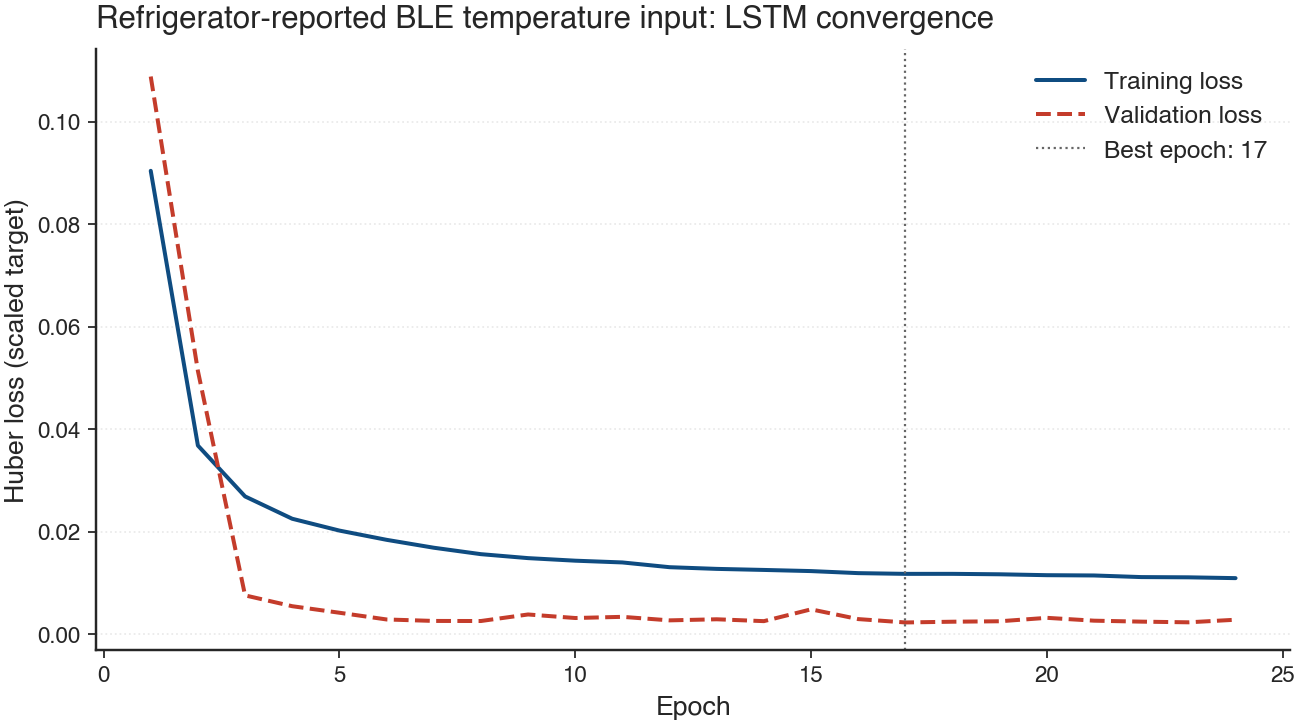


LSTM performance: Refrigerator-reported BLE temperature input
----------------------------------------------------------------------------------------------------------------


E0000 00:00:1790108803.022067 3144772 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Refrigerator-reported-temperature LSTM VALIDATION                RMSE 0.409 | MAE 0.320 | Bias -0.007 | P95AbsErr 0.795


E0000 00:00:1790108810.425081 3144772 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Refrigerator-reported-temperature LSTM ORIGINAL_HOLDOUT          RMSE 0.471 | MAE 0.294 | Bias +0.014 | P95AbsErr 0.973
Refrigerator-reported-temperature LSTM PROSPECTIVE_CHALLENGE     RMSE 0.473 | MAE 0.391 | Bias +0.028 | P95AbsErr 0.884
----------------------------------------------------------------------------------------------------------------


,temperature_input,estimator,split,n,rmse,mae,bias,p95_abs_error
0,Refrigerator-reported BLE temperature input,Long short-term memory network,original_holdout,26453,0.471,0.294,0.014,0.973
1,Refrigerator-reported BLE temperature input,Long short-term memory network,prospective_challenge,2725,0.473,0.391,0.028,0.884
2,Refrigerator-reported BLE temperature input,Long short-term memory network,validation,55602,0.409,0.320,-0.007,0.795


,temperature_input,estimator,split,cold_reference_excursion_duration_min,cold_excursion_ppv_pct,cold_missed_reference_excursion_duration_min,cold_missed_reference_excursion_pct,cold_false_positive_excursion_duration_min,hot_reference_excursion_duration_min,hot_excursion_ppv_pct,hot_missed_reference_excursion_duration_min,hot_missed_reference_excursion_pct,hot_false_positive_excursion_duration_min
0,Refrigerator-reported BLE temperature input,Long short-term memory network,original_holdout,2507.0,89.94,156.0,6.22,263.0,2168.0,81.45,126.0,5.81,465.0
1,Refrigerator-reported BLE temperature input,Long short-term memory network,prospective_challenge,148.0,100.00,1.0,0.68,0.0,359.0,97.98,20.0,5.57,7.0
2,Refrigerator-reported BLE temperature input,Long short-term memory network,validation,9342.0,83.09,1327.0,14.20,1631.0,7264.0,81.97,1317.0,18.13,1308.0


Saved LSTM continuous metrics: repository/outputs/run_artifacts/tables/lstm_continuous_metrics.csv
Saved LSTM excursion metrics: repository/outputs/run_artifacts/tables/lstm_excursion_metrics.csv
Saved input-specific predictions: repository/outputs/run_artifacts/refrigerator_ble_input/predictions
Refrigerator-reported-temperature LSTM training audit:


,temperature_input,epochs_completed,best_epoch,best_validation_loss,history_path,figure_pdf_path,figure_png_path
0,Refrigerator-reported BLE temperature input,24,17,0.002254,repository/...,repository/...,repository/...


Saved LSTM hyperparameters: repository/outputs/run_artifacts/tables/lstm_hyperparameters.csv


In [12]:
input_key = "refrigerator_ble_input"
configuration = TEMPERATURE_INPUTS[input_key]
data = model_data[input_key]

CONTROLLER_LSTM_UNITS = 110
CONTROLLER_DENSE_UNITS = 16
CONTROLLER_DROPOUT_RATE = 0.20
CONTROLLER_L2_WEIGHT = 1e-5
CONTROLLER_LEARNING_RATE = 5e-4
CONTROLLER_BATCH_SIZE = 896
CONTROLLER_MAX_EPOCHS = 100
CONTROLLER_EARLY_STOPPING_PATIENCE = 7
CONTROLLER_LR_PATIENCE = 4
CONTROLLER_LR_REDUCTION_FACTOR = 0.5
CONTROLLER_MIN_LEARNING_RATE = 1e-6
CONTROLLER_HUBER_DELTA = 1.0

n_timesteps = data["X_train_s"].shape[1]
n_features = data["X_train_s"].shape[2]

if n_timesteps != int(configuration["lookback_min"]):
    raise ValueError("Refrigerator-reported-temperature LSTM history does not match its prescribed lookback.")
if n_features != len(configuration["feature_cols"]):
    raise ValueError("Refrigerator-reported-temperature LSTM feature count is inconsistent.")

print(f"Training {configuration['lstm_name']}")
print(
    f"Input tensor: [samples, {n_timesteps} observations, "
    f"{n_features} features]"
)
print(f"Locked random seed: {SEED}")
print(f"Batch size: {CONTROLLER_BATCH_SIZE}")
print("Architecture and training settings are shared by both primary LSTMs.")

# Use the same global seed and model capacity as the BME280 air-temperature input.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)


def build_refrigerator_ble_input_lstm(timesteps, feature_count):
    """Build the matched refrigerator-reported-temperature sequence estimator."""
    inputs = layers.Input(
        shape=(int(timesteps), int(feature_count)), name="controller_history"
    )
    x = layers.LSTM(
        CONTROLLER_LSTM_UNITS,
        kernel_regularizer=regularizers.l2(CONTROLLER_L2_WEIGHT),
        name="lstm",
    )(inputs)
    x = layers.BatchNormalization(name="batch_normalization")(x)
    x = layers.Dropout(CONTROLLER_DROPOUT_RATE, name="dropout")(x)
    x = layers.Dense(
        CONTROLLER_DENSE_UNITS, activation="relu", name="dense_relu"
    )(x)
    outputs = layers.Dense(1, activation="linear", name="T_P1_scaled")(x)

    model = models.Model(
        inputs=inputs, outputs=outputs, name="refrigerator_ble_input_lstm"
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=CONTROLLER_LEARNING_RATE
        ),
        loss=tf.keras.losses.Huber(delta=CONTROLLER_HUBER_DELTA),
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


refrigerator_ble_input_lstm = build_refrigerator_ble_input_lstm(
    n_timesteps, n_features
)
refrigerator_ble_input_lstm.summary()

train_dataset = make_tf_dataset(
    data["X_train_s"], data["y_train_s"],
    batch_size=CONTROLLER_BATCH_SIZE, training=True,
)
validation_dataset = make_tf_dataset(
    data["X_val_s"], data["y_val_s"],
    batch_size=CONTROLLER_BATCH_SIZE, training=False,
)

checkpoint_path = (
    configuration["checkpoint_dir"] / configuration["checkpoint_name"]
)
training_callbacks = [
    callbacks.TerminateOnNaN(),
    callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=CONTROLLER_LR_REDUCTION_FACTOR,
        patience=CONTROLLER_LR_PATIENCE,
        min_lr=CONTROLLER_MIN_LEARNING_RATE,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=CONTROLLER_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
]

refrigerator_ble_lstm_history = refrigerator_ble_input_lstm.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CONTROLLER_MAX_EPOCHS,
    callbacks=training_callbacks,
    verbose=1,
)

training_audit = record_lstm_training(
    input_key, refrigerator_ble_input_lstm, refrigerator_ble_lstm_history
)
evaluation_output = evaluate_lstm_model(
    input_key, refrigerator_ble_input_lstm
)

lstm_hyperparameter_records[input_key] = {
    "input_key": input_key,
    "temperature_input": configuration["label"],
    "random_seed": SEED,
    "lookback_observations": n_timesteps,
    "feature_count": n_features,
    "lstm_units": CONTROLLER_LSTM_UNITS,
    "dense_units": CONTROLLER_DENSE_UNITS,
    "dropout_rate": CONTROLLER_DROPOUT_RATE,
    "l2_weight": CONTROLLER_L2_WEIGHT,
    "learning_rate": CONTROLLER_LEARNING_RATE,
    "loss": "Huber(delta=1.0) on standardized T_P1",
    "optimizer": "Adam",
    "batch_size": CONTROLLER_BATCH_SIZE,
    "maximum_epochs": CONTROLLER_MAX_EPOCHS,
    "early_stopping_patience": CONTROLLER_EARLY_STOPPING_PATIENCE,
    "learning_rate_patience": CONTROLLER_LR_PATIENCE,
    "learning_rate_reduction_factor": CONTROLLER_LR_REDUCTION_FACTOR,
    "minimum_learning_rate": CONTROLLER_MIN_LEARNING_RATE,
    "total_parameters": int(refrigerator_ble_input_lstm.count_params()),
    "trainable_parameters": int(sum(
        np.prod(weight.shape)
        for weight in refrigerator_ble_input_lstm.trainable_weights
    )),
    "epochs_completed": training_audit["epochs_completed"],
    "best_epoch": training_audit["best_epoch"],
    "best_validation_loss": training_audit["best_validation_loss"],
}
lstm_hyperparameters = pd.DataFrame(
    list(lstm_hyperparameter_records.values())
)
lstm_hyperparameters_path = (
    JOINT_OUTPUT_ROOT / "tables" / "lstm_hyperparameters.csv"
)
lstm_hyperparameters.to_csv(
    lstm_hyperparameters_path, index=False
)

print("Refrigerator-reported-temperature LSTM training audit:")
display(pd.DataFrame([training_audit]))
print("Saved LSTM hyperparameters:", lstm_hyperparameters_path.resolve())


## 13. BME280 Air-Temperature Input ($T_{280}$) LSTM Training and Evaluation

The BME280 air-temperature input estimates $T_{\mathrm{P1}}$ from a 60-observation history of the centrally positioned BME280 measurement $T_{280}$ and its six causal features. The LSTM architecture and training settings are matched to the refrigerator-reported estimator so that performance differences primarily reflect the resolution and information content of the two input signals. Only the input-specific history length and feature set differ. The original holdout and prospective challenge remain excluded from training, checkpoint selection and early stopping.

Reported predictions come directly from the restored best-validation weights. No bias correction, recalibration or Ridge--LSTM ensemble is applied after holdout evaluation. The architecture, training settings and fitted artifacts are recorded so that the analysis can be reproduced.

Training BME280-input LSTM
Input tensor: [samples, 60 observations, 6 features]
Locked random seed: 42
Batch size: 896


Model: "bme280_input_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_history (InputLayer)     │ (None, 60, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 110)            │        51,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 110)            │           440 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Dense)              │ (None, 16)             │         1,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_P1_scaled (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,713 (209.82 KB)

 Trainable params: 53,493 (208.96 KB)

 Non-trainable params: 220 (880.00 B)

Epoch 1/100
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.1255 - mae: 0.3542  
Epoch 1: val_loss improved from None to 0.09212, saving model to repository/outputs/run_artifacts/bme280_input/checkpoints/best_bme280_input_lstm.keras

Epoch 1: finished saving model to repository/outputs/run_artifacts/bme280_input/checkpoints/best_bme280_input_lstm.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 51s 194ms/step - loss: 0.0675 - mae: 0.2543 - val_loss: 0.0921 - val_mae: 0.3512 - learning_rate: 5.0000e-04
Epoch 2/100
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0209 - mae: 0.1466 
Epoch 2: val_loss improved from 0.09212 to 0.03307, saving model to repository/outputs/run_artifacts/bme280_input/checkpoints/best_bme280_input_lstm.keras

Epoch 2: finished saving model to repository/outputs/run_artifacts/bme280_input/checkpoints/best_bme280_input_lstm.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - loss: 0.0175 - mae: 0.1337 - val_loss: 0.0331 - val_mae: 0.2142 - learning_rate: 5.0000e-04
Ep

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


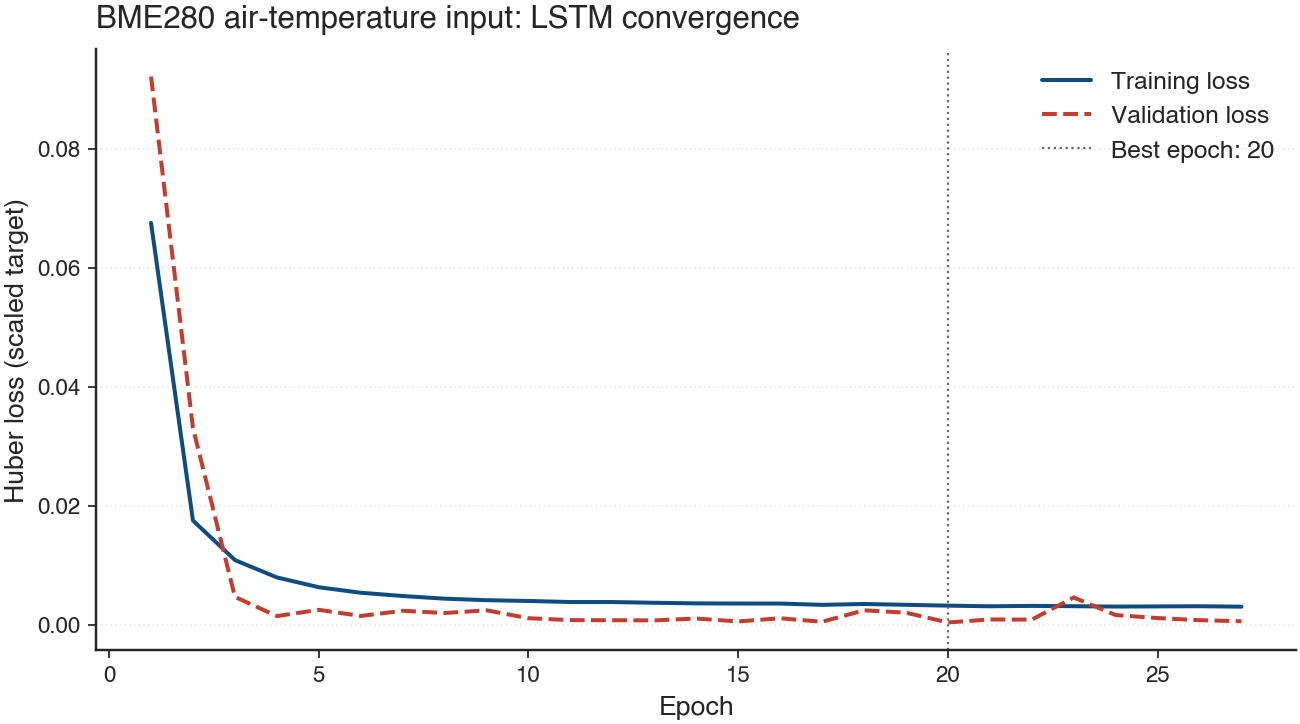


LSTM performance: BME280 air-temperature input
----------------------------------------------------------------------------------------------------------------


E0000 00:00:1790110068.109349 3144772 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


BME280-input LSTM VALIDATION                                     RMSE 0.150 | MAE 0.121 | Bias +0.007 | P95AbsErr 0.287
BME280-input LSTM ORIGINAL_HOLDOUT                               RMSE 0.211 | MAE 0.176 | Bias +0.162 | P95AbsErr 0.401
BME280-input LSTM PROSPECTIVE_CHALLENGE                          RMSE 0.181 | MAE 0.122 | Bias +0.074 | P95AbsErr 0.411
----------------------------------------------------------------------------------------------------------------


E0000 00:00:1790110073.135847 3144772 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,temperature_input,estimator,split,n,rmse,mae,bias,p95_abs_error
0,BME280 air-temperature input,Long short-term memory network,original_holdout,26633,0.211,0.176,0.162,0.401
1,BME280 air-temperature input,Long short-term memory network,prospective_challenge,2785,0.181,0.122,0.074,0.411
2,BME280 air-temperature input,Long short-term memory network,validation,55842,0.150,0.121,0.007,0.287


,temperature_input,estimator,split,cold_reference_excursion_duration_min,cold_excursion_ppv_pct,cold_missed_reference_excursion_duration_min,cold_missed_reference_excursion_pct,cold_false_positive_excursion_duration_min,hot_reference_excursion_duration_min,hot_excursion_ppv_pct,hot_missed_reference_excursion_duration_min,hot_missed_reference_excursion_pct,hot_false_positive_excursion_duration_min
0,BME280 air-temperature input,Long short-term memory network,original_holdout,2507.0,99.87,186.0,7.42,3.0,2168.0,93.78,28.0,1.29,142.0
1,BME280 air-temperature input,Long short-term memory network,prospective_challenge,148.0,99.32,3.0,2.03,1.0,359.0,97.52,5.0,1.39,9.0
2,BME280 air-temperature input,Long short-term memory network,validation,9342.0,94.44,235.0,2.52,536.0,7264.0,98.54,503.0,6.92,100.0


Saved LSTM continuous metrics: repository/outputs/run_artifacts/tables/lstm_continuous_metrics.csv
Saved LSTM excursion metrics: repository/outputs/run_artifacts/tables/lstm_excursion_metrics.csv
Saved input-specific predictions: repository/outputs/run_artifacts/bme280_input/predictions
BME280-input LSTM training audit:


,temperature_input,epochs_completed,best_epoch,best_validation_loss,history_path,figure_pdf_path,figure_png_path
0,BME280 air-temperature input,27,20,0.000373,repository/...,repository/...,repository/...


Saved LSTM hyperparameters: repository/outputs/run_artifacts/tables/lstm_hyperparameters.csv


In [13]:
input_key = "bme280_input"
configuration = TEMPERATURE_INPUTS[input_key]
data = model_data[input_key]

SENSOR_LSTM_UNITS = 110
SENSOR_DENSE_UNITS = 16
SENSOR_DROPOUT_RATE = 0.20
SENSOR_L2_WEIGHT = 1e-5
SENSOR_LEARNING_RATE = 5e-4
SENSOR_BATCH_SIZE = 896
SENSOR_MAX_EPOCHS = 100
SENSOR_EARLY_STOPPING_PATIENCE = 7
SENSOR_LR_PATIENCE = 4
SENSOR_LR_REDUCTION_FACTOR = 0.5
SENSOR_MIN_LEARNING_RATE = 1e-6

n_timesteps = data["X_train_s"].shape[1]
n_features = data["X_train_s"].shape[2]

if n_timesteps != int(configuration["lookback_min"]):
    raise ValueError("BME280-input LSTM history does not match its prescribed lookback.")
if n_features != len(configuration["feature_cols"]):
    raise ValueError("BME280-input LSTM feature count is inconsistent.")

print(f"Training {configuration['lstm_name']}")
print(
    f"Input tensor: [samples, {n_timesteps} observations, "
    f"{n_features} features]"
)
print(f"Locked random seed: {SEED}")
print(f"Batch size: {SENSOR_BATCH_SIZE}")

# Use the single global seed. A favourable seed is not selected from outcomes.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)


def build_bme280_input_lstm(timesteps, feature_count):
    """Build the prespecified BME280-input nonlinear sequence estimator."""
    inputs = layers.Input(
        shape=(int(timesteps), int(feature_count)), name="sensor_history"
    )
    x = layers.LSTM(
        SENSOR_LSTM_UNITS,
        kernel_regularizer=regularizers.l2(SENSOR_L2_WEIGHT),
        name="lstm",
    )(inputs)
    x = layers.BatchNormalization(name="batch_normalization")(x)
    x = layers.Dropout(SENSOR_DROPOUT_RATE, name="dropout")(x)
    x = layers.Dense(
        SENSOR_DENSE_UNITS, activation="relu", name="dense_relu"
    )(x)
    outputs = layers.Dense(1, activation="linear", name="T_P1_scaled")(x)

    model = models.Model(
        inputs=inputs, outputs=outputs, name="bme280_input_lstm"
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=SENSOR_LEARNING_RATE
        ),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


bme280_input_lstm = build_bme280_input_lstm(
    n_timesteps, n_features
)
bme280_input_lstm.summary()

train_dataset = make_tf_dataset(
    data["X_train_s"], data["y_train_s"],
    batch_size=SENSOR_BATCH_SIZE, training=True,
)
validation_dataset = make_tf_dataset(
    data["X_val_s"], data["y_val_s"],
    batch_size=SENSOR_BATCH_SIZE, training=False,
)

checkpoint_path = (
    configuration["checkpoint_dir"] / configuration["checkpoint_name"]
)
training_callbacks = [
    callbacks.TerminateOnNaN(),
    callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=SENSOR_LR_REDUCTION_FACTOR,
        patience=SENSOR_LR_PATIENCE,
        min_lr=SENSOR_MIN_LEARNING_RATE,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=SENSOR_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
]

bme280_lstm_history = bme280_input_lstm.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=SENSOR_MAX_EPOCHS,
    callbacks=training_callbacks,
    verbose=1,
)

training_audit = record_lstm_training(
    input_key, bme280_input_lstm, bme280_lstm_history
)
evaluation_output = evaluate_lstm_model(
    input_key, bme280_input_lstm
)

lstm_hyperparameter_records[input_key] = {
    "input_key": input_key,
    "temperature_input": configuration["label"],
    "random_seed": SEED,
    "lookback_observations": n_timesteps,
    "feature_count": n_features,
    "lstm_units": SENSOR_LSTM_UNITS,
    "dense_units": SENSOR_DENSE_UNITS,
    "dropout_rate": SENSOR_DROPOUT_RATE,
    "l2_weight": SENSOR_L2_WEIGHT,
    "learning_rate": SENSOR_LEARNING_RATE,
    "loss": "Huber(delta=1.0) on standardized T_P1",
    "optimizer": "Adam",
    "batch_size": SENSOR_BATCH_SIZE,
    "maximum_epochs": SENSOR_MAX_EPOCHS,
    "early_stopping_patience": SENSOR_EARLY_STOPPING_PATIENCE,
    "learning_rate_patience": SENSOR_LR_PATIENCE,
    "learning_rate_reduction_factor": SENSOR_LR_REDUCTION_FACTOR,
    "minimum_learning_rate": SENSOR_MIN_LEARNING_RATE,
    "total_parameters": int(bme280_input_lstm.count_params()),
    "trainable_parameters": int(sum(
        np.prod(weight.shape)
        for weight in bme280_input_lstm.trainable_weights
    )),
    "epochs_completed": training_audit["epochs_completed"],
    "best_epoch": training_audit["best_epoch"],
    "best_validation_loss": training_audit["best_validation_loss"],
}
lstm_hyperparameters = pd.DataFrame(
    list(lstm_hyperparameter_records.values())
)
lstm_hyperparameters_path = (
    JOINT_OUTPUT_ROOT / "tables" / "lstm_hyperparameters.csv"
)
lstm_hyperparameters.to_csv(
    lstm_hyperparameters_path, index=False
)

print("BME280-input LSTM training audit:")
display(pd.DataFrame([training_audit]))
print("Saved LSTM hyperparameters:", lstm_hyperparameters_path.resolve())


## 14. Locked Development Comparison and Separate Evaluation Exports

This section consolidates validation, original independent-holdout and prospective operational-challenge predictions for each temperature input. The original holdout and prospective challenge remain separate throughout. The development decision remains based on validation results; neither evaluation dataset is used to select, refit or recalibrate an estimator.

The section also compares the rate of change of each prediction with the rate of change of the aligned glycol-buffered reference. Rate calculations use actual elapsed minutes within continuous source segments and never bridge recording gaps. Separate, clearly named prediction workbooks are exported for both temperature inputs and both evaluation datasets.


In [14]:
# Consolidate saved predictions and record the model-development decision.
COMPARISON_SPLITS = (
    "validation", "original_holdout", "prospective_challenge"
)

COMPARISON_INPUTS = {
    "refrigerator_ble_input": {
        "label": "Refrigerator-reported BLE temperature input",
        "input_signal": T_BLE_COL,
        "prediction_dir": (
            JOINT_OUTPUT_ROOT
            / "refrigerator_ble_input"
            / "predictions"
        ),
    },
    "bme280_input": {
        "label": "BME280 air-temperature input",
        "input_signal": T_280_COL,
        "prediction_dir": (
            JOINT_OUTPUT_ROOT
            / "bme280_input"
            / "predictions"
        ),
    },
}

REFERENCE_PREDICTION_COLUMNS = {
    "direct_input": (
        "Direct input reference",
        "T_P1_hat_direct_input",
    ),
    "instantaneous_affine": (
        "Instantaneous affine model",
        "T_P1_hat_instantaneous_affine",
    ),
    "first_order_thermal": (
        "First-order thermal model",
        "T_P1_hat_first_order_thermal",
    ),
    "ridge_temporal": (
        "Ridge temporal model",
        "T_P1_hat_ridge_temporal",
    ),
}

PRIMARY_CANDIDATE_KEYS = {
    "bme280_input": {"lstm"},
    "refrigerator_ble_input": {"lstm"},
}

ALIGNMENT_COLUMNS = [
    TIME_COL,
    "segment_id",
    "source_segment_id",
    "source_row_id",
    T_P1_COL,
]


def assert_prediction_alignment(reference_frame, candidate_frame, label):
    """Fail if a saved prediction file is not aligned to the reference timeline."""
    if len(reference_frame) != len(candidate_frame):
        raise ValueError(
            f"{label}: row count differs from the aligned reference predictions."
        )

    for column in ALIGNMENT_COLUMNS:
        if column == T_P1_COL:
            aligned = np.allclose(
                reference_frame[column].to_numpy(dtype=float),
                candidate_frame[column].to_numpy(dtype=float),
                rtol=0.0,
                atol=1e-10,
            )
        else:
            aligned = reference_frame[column].equals(
                candidate_frame[column]
            )

        if not aligned:
            raise ValueError(
                f"{label}: alignment failed for {column}."
            )


evaluation_prediction_frames = {}
continuous_comparison_rows = []
excursion_comparison_rows = []
rate_comparison_rows = []

for input_key, configuration in COMPARISON_INPUTS.items():
    for split_name in COMPARISON_SPLITS:
        prediction_dir = configuration["prediction_dir"]

        reference_path = (
            prediction_dir
            / f"reference_predictions_{split_name}.csv"
        )
        lstm_path = (
            prediction_dir
            / f"lstm_predictions_{split_name}.csv"
        )

        for required_path in [reference_path, lstm_path]:
            if not required_path.is_file():
                raise FileNotFoundError(
                    f"Saved prediction file not found: "
                    f"{required_path.resolve()}"
                )

        reference_frame = pd.read_csv(
            reference_path,
            parse_dates=[TIME_COL],
        )
        lstm_frame = pd.read_csv(
            lstm_path,
            parse_dates=[TIME_COL],
        )

        assert_prediction_alignment(
            reference_frame,
            lstm_frame,
            f"{configuration['label']} {split_name} LSTM",
        )

        comparison_frame = reference_frame.copy()
        comparison_frame["T_P1_hat_lstm"] = (
            lstm_frame["T_P1_hat_lstm"].to_numpy()
        )

        estimator_columns = dict(REFERENCE_PREDICTION_COLUMNS)
        estimator_columns["lstm"] = (
            "Long short-term memory network",
            "T_P1_hat_lstm",
        )

        evaluation_prediction_frames[
            (input_key, split_name)
        ] = comparison_frame

        y_true = comparison_frame[T_P1_COL].to_numpy(
            dtype=float
        )
        segment_ids = comparison_frame[
            "source_segment_id"
        ].to_numpy()

        for estimator_key, (
            estimator_label,
            prediction_column,
        ) in estimator_columns.items():

            y_pred = comparison_frame[
                prediction_column
            ].to_numpy(dtype=float)

            common = {
                "input_key": input_key,
                "temperature_input": configuration["label"],
                "input_signal": configuration["input_signal"],
                "split": split_name,
                "estimator_key": estimator_key,
                "estimator": estimator_label,
                "candidate_for_lock": (
                    estimator_key
                    in PRIMARY_CANDIDATE_KEYS[input_key]
                ),
            }

            continuous_comparison_rows.append({
                **common,
                **regression_metrics(y_true, y_pred),
            })

            excursion_comparison_rows.append({
                **common,
                **excursion_metrics(
                    y_true,
                    y_pred,
                    segment_ids,
                ),
            })

            rate_comparison_rows.append({
                **common,
                **rate_of_change_metrics(
                    y_true,
                    y_pred,
                    segment_ids,
                    comparison_frame[TIME_COL],
                ),
            })


development_continuous_comparison = pd.DataFrame(
    continuous_comparison_rows
)
development_excursion_comparison = pd.DataFrame(
    excursion_comparison_rows
)
development_rate_comparison = pd.DataFrame(
    rate_comparison_rows
)


input_order = {
    "refrigerator_ble_input": 0,
    "bme280_input": 1,
}

split_order = {
    "validation": 0,
    "original_holdout": 1,
    "prospective_challenge": 2,
}

estimator_order = {
    "direct_input": 0,
    "instantaneous_affine": 1,
    "first_order_thermal": 2,
    "ridge_temporal": 3,
    "lstm": 4,
}

for comparison_table in [
    development_continuous_comparison,
    development_excursion_comparison,
    development_rate_comparison,
]:
    comparison_table["_input_order"] = (
        comparison_table["input_key"].map(input_order)
    )
    comparison_table["_split_order"] = (
        comparison_table["split"].map(split_order)
    )
    comparison_table["_estimator_order"] = (
        comparison_table["estimator_key"].map(
            estimator_order
        )
    )

    comparison_table.sort_values(
        [
            "_input_order",
            "_estimator_order",
            "_split_order",
        ],
        inplace=True,
    )

    comparison_table.drop(
        columns=[
            "_input_order",
            "_split_order",
            "_estimator_order",
        ],
        inplace=True,
    )

    comparison_table.reset_index(
        drop=True,
        inplace=True,
    )


model_selection_record = pd.DataFrame([
    {
        "temperature_input":
            "Refrigerator-reported BLE temperature input",
        "input_signal": T_BLE_COL,
        "estimator":
            "Long short-term memory network",
        "development_role":
            "Primary estimator",
        "selection_basis": (
            "Strong validation improvement over all "
            "reference estimators."
        ),
        "lock_status":
            "Locked",
        "evaluation_action": (
            "Original holdout and prospective challenge "
            "evaluated separately; no evaluation-data "
            "fitting or recalibration"
        ),
    },
    {
        "temperature_input":
            "BME280 air-temperature input",
        "input_signal": T_280_COL,
        "estimator":
            "Long short-term memory network",
        "development_role":
            "Primary estimator",
        "selection_basis": (
            "Lowest validation error with high agreement "
            "and stable threshold tracking."
        ),
        "lock_status":
            "Locked",
        "evaluation_action": (
            "Original holdout and prospective challenge "
            "evaluated separately; no evaluation-data "
            "fitting or recalibration"
        ),
    },
])


# Save consolidated comparisons and separately named evaluation predictions.
comparison_table_dir = JOINT_OUTPUT_ROOT / "tables"
comparison_prediction_dir = JOINT_OUTPUT_ROOT / "predictions"

comparison_table_dir.mkdir(
    parents=True,
    exist_ok=True,
)
comparison_prediction_dir.mkdir(
    parents=True,
    exist_ok=True,
)

continuous_comparison_path = (
    comparison_table_dir
    / "validation_holdout_prospective_continuous.csv"
)

excursion_comparison_path = (
    comparison_table_dir
    / "validation_holdout_prospective_excursions.csv"
)

rate_comparison_path = (
    comparison_table_dir
    / "validation_holdout_prospective_rates.csv"
)

selection_record_path = (
    comparison_table_dir
    / "locked_model_selection_record.csv"
)

development_continuous_comparison.to_csv(
    continuous_comparison_path,
    index=False,
)
development_excursion_comparison.to_csv(
    excursion_comparison_path,
    index=False,
)
development_rate_comparison.to_csv(
    rate_comparison_path,
    index=False,
)
model_selection_record.to_csv(
    selection_record_path,
    index=False,
)


def build_plotting_prediction_export(
    frame,
    predictor_col,
    predictor_export_name,
    dataset_role,
):
    """Create one model-specific, machine-readable evaluation prediction table."""
    required_columns = [
        TIME_COL,
        "source_segment_id",
        T_P1_COL,
        "T_P1_hat_lstm",
        predictor_col,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Plotting export is missing required columns: "
            f"{missing_columns}"
        )

    export = frame[required_columns].copy()

    export.rename(
        columns={
            T_P1_COL: "T_P1_true_C",
            "T_P1_hat_lstm": "T_P1_predicted_C",
            predictor_col: predictor_export_name,
        },
        inplace=True,
    )

    export.insert(
        0,
        "dataset_role",
        dataset_role,
    )

    export[TIME_COL] = pd.to_datetime(
        export[TIME_COL],
        errors="raise",
    )

    export.sort_values(
        ["source_segment_id", TIME_COL],
        inplace=True,
        ignore_index=True,
    )

    if export.isna().any().any():
        raise ValueError(
            "A missing value entered a plotting export."
        )

    numeric_columns = [
        "T_P1_true_C",
        "T_P1_predicted_C",
        predictor_export_name,
    ]

    if not np.isfinite(
        export[numeric_columns].to_numpy(dtype=float)
    ).all():
        raise ValueError(
            "A non-finite value entered a plotting export."
        )

    return export


EVALUATION_EXPORT_SPECS = {
    "original_holdout": {
        "label": "Original independent holdout",
        "stem": "holdout",
    },
    "prospective_challenge": {
        "label": "Prospective operational challenge",
        "stem": "prospective",
    },
}

INPUT_EXPORT_SPECS = {
    "refrigerator_ble_input": {
        "label":
            "Refrigerator-reported BLE temperature input",
        "predictor_col":
            T_BLE_COL,
        "predictor_export_name":
            "T_BLE_predictor_C",
        "stem":
            "ble",
        "lookback":
            T_BLE_LOOKBACK_MIN,
    },
    "bme280_input": {
        "label":
            "BME280 air-temperature input",
        "predictor_col":
            T_280_COL,
        "predictor_export_name":
            "T_280_predictor_C",
        "stem":
            "bme280",
        "lookback":
            T_280_LOOKBACK_MIN,
    },
}


plotting_export_rows = []

for split_name, dataset_spec in (
    EVALUATION_EXPORT_SPECS.items()
):
    for input_key, input_spec in (
        INPUT_EXPORT_SPECS.items()
    ):
        frame = evaluation_prediction_frames[
            (input_key, split_name)
        ]

        export = build_plotting_prediction_export(
            frame,
            input_spec["predictor_col"],
            input_spec["predictor_export_name"],
            dataset_spec["label"],
        )

        export_path = FINAL_PREDICTION_DIR / (
            f"{dataset_spec['stem']}_"
            f"{input_spec['stem']}_predictions.xlsx"
        )

        export.to_excel(
            export_path,
            sheet_name="Predictions",
            index=False,
            freeze_panes=(1, 0),
        )
        export.to_csv(
            export_path.with_suffix(".csv"), index=False,
            date_format="%Y-%m-%d %H:%M:%S",
        )

        plotting_export_rows.append({
            "dataset_key":
                split_name,
            "dataset":
                dataset_spec["label"],
            "temperature_input":
                input_spec["label"],
            "evaluation_start_observation":
                input_spec["lookback"],
            "rows":
                len(export),
            "start":
                export[TIME_COL].min(),
            "end":
                export[TIME_COL].max(),
            "excel_file":
                str(export_path.resolve()),
        })


plotting_export_manifest = pd.DataFrame(
    plotting_export_rows
)


print(
    "Validation and separate evaluation "
    "continuous comparison:"
)

display(
    development_continuous_comparison[[
        "temperature_input",
        "estimator",
        "split",
        "rmse",
        "mae",
        "bias",
        "p95_abs_error",
    ]].round({
        "rmse": 3,
        "mae": 3,
        "bias": 3,
        "p95_abs_error": 3,
    })
)


print(
    "Excursion comparison for the two locked "
    "LSTM models:"
)

display(
    development_excursion_comparison.loc[
        development_excursion_comparison[
            "candidate_for_lock"
        ],
        [
            "temperature_input",
            "estimator",
            "split",

            "cold_reference_excursion_duration_min",
            "cold_excursion_ppv_pct",
            "cold_missed_reference_excursion_duration_min",
            "cold_missed_reference_excursion_pct",
            "cold_false_positive_excursion_duration_min",

            "hot_reference_excursion_duration_min",
            "hot_excursion_ppv_pct",
            "hot_missed_reference_excursion_duration_min",
            "hot_missed_reference_excursion_pct",
            "hot_false_positive_excursion_duration_min",
        ],
    ].round({
        "cold_reference_excursion_duration_min": 1,
        "cold_excursion_ppv_pct": 2,
        "cold_missed_reference_excursion_duration_min": 1,
        "cold_missed_reference_excursion_pct": 2,
        "cold_false_positive_excursion_duration_min": 1,

        "hot_reference_excursion_duration_min": 1,
        "hot_excursion_ppv_pct": 2,
        "hot_missed_reference_excursion_duration_min": 1,
        "hot_missed_reference_excursion_pct": 2,
        "hot_false_positive_excursion_duration_min": 1,
    })
)


print("LSTM rate-of-change comparison:")

display(
    development_rate_comparison.loc[
        development_rate_comparison[
            "estimator_key"
        ].eq("lstm"),
        [
            "temperature_input",
            "split",
            "rate_n",
            "reference_p95_abs_rate_C_per_min",
            "rate_rmse_C_per_min",
            "rate_mae_C_per_min",
            "rate_p95_abs_error_C_per_min",
            "rate_correlation",
        ],
    ].round(4)
)


print("Locked model-selection record:")
display(model_selection_record)

print("Original independent holdout evaluated: True")
print(
    "Prospective operational challenge "
    "evaluated separately: True"
)

print("Model-specific plotting exports:")
display(plotting_export_manifest)

print(
    "Saved continuous comparison:",
    continuous_comparison_path.resolve(),
)
print(
    "Saved excursion comparison:",
    excursion_comparison_path.resolve(),
)
print(
    "Saved rate comparison:",
    rate_comparison_path.resolve(),
)
print(
    "Saved model-selection record:",
    selection_record_path.resolve(),
)

Validation and separate evaluation continuous comparison:


,temperature_input,estimator,split,rmse,mae,bias,p95_abs_error
0,Refrigerator-reported BLE temperature input,Direct input reference,validation,1.468,1.221,0.000,2.550
1,Refrigerator-reported BLE temperature input,Direct input reference,original_holdout,1.349,1.118,0.101,2.260
2,Refrigerator-reported BLE temperature input,Direct input reference,prospective_challenge,1.600,1.285,-0.055,2.816
3,Refrigerator-reported BLE temperature input,Instantaneous affine model,validation,1.401,1.124,0.430,2.659
4,Refrigerator-reported BLE temperature input,Instantaneous affine model,original_holdout,1.341,1.100,0.476,2.649
5,Refrigerator-reported BLE temperature input,Instantaneous affine model,prospective_challenge,1.586,1.270,0.163,2.997
6,Refrigerator-reported BLE temperature input,First-order thermal model,validation,0.962,0.834,0.788,1.730
7,Refrigerator-reported BLE temperature input,First-order thermal model,original_holdout,1.098,0.997,0.865,1.991
8,Refrigerator-reported BLE temperature input,First-order thermal model,prospective_challenge,1.215,1.090,0.635,1.949
9,Refrigerator-reported BLE temperature input,Ridge temporal model,validation,0.817,0.667,0.542,1.577


Excursion comparison for the two locked LSTM models:


,temperature_input,estimator,split,cold_reference_excursion_duration_min,cold_excursion_ppv_pct,cold_missed_reference_excursion_duration_min,cold_missed_reference_excursion_pct,cold_false_positive_excursion_duration_min,hot_reference_excursion_duration_min,hot_excursion_ppv_pct,hot_missed_reference_excursion_duration_min,hot_missed_reference_excursion_pct,hot_false_positive_excursion_duration_min
12,Refrigerator-reported BLE temperature input,Long short-term memory network,validation,9342.0,83.09,1327.0,14.20,1631.0,7264.0,81.97,1317.0,18.13,1308.0
13,Refrigerator-reported BLE temperature input,Long short-term memory network,original_holdout,2507.0,89.94,156.0,6.22,263.0,2168.0,81.45,126.0,5.81,465.0
14,Refrigerator-reported BLE temperature input,Long short-term memory network,prospective_challenge,148.0,100.00,1.0,0.68,0.0,359.0,97.98,20.0,5.57,7.0
27,BME280 air-temperature input,Long short-term memory network,validation,9342.0,94.44,235.0,2.52,536.0,7264.0,98.54,503.0,6.92,100.0
28,BME280 air-temperature input,Long short-term memory network,original_holdout,2507.0,99.87,186.0,7.42,3.0,2168.0,93.78,28.0,1.29,142.0
29,BME280 air-temperature input,Long short-term memory network,prospective_challenge,148.0,99.32,3.0,2.03,1.0,359.0,97.52,5.0,1.39,9.0


LSTM rate-of-change comparison:


...

Locked model-selection record:


,temperature_input,input_signal,estimator,development_role,selection_basis,lock_status,evaluation_action
0,Refrigerator-reported BLE temperature input,T_BLE,Long short-term memory network,Primary estimator,Strong validation improvement over all referen...,Locked,Original holdout and prospective challenge eva...
1,BME280 air-temperature input,T_280,Long short-term memory network,Primary estimator,Lowest validation error with high agreement an...,Locked,Original holdout and prospective challenge eva...


Original independent holdout evaluated: True
Prospective operational challenge evaluated separately: True
Model-specific plotting exports:


,dataset_key,dataset,temperature_input,evaluation_start_observation,rows,start,end,excel_file
0,original_holdout,Original independent holdout,Refrigerator-reported BLE temperature input,120,26453,2026-07-24 22:27:10,2026-08-12 14:22:46,repository/...
1,original_holdout,Original independent holdout,BME280 air-temperature input,60,26633,2026-07-24 21:27:10,2026-08-12 14:22:46,repository/...
2,prospective_challenge,Prospective operational challenge,Refrigerator-reported BLE temperature input,120,2725,2026-09-01 13:40:09,2026-09-03 11:04:18,repository/...
3,prospective_challenge,Prospective operational challenge,BME280 air-temperature input,60,2785,2026-09-01 12:40:09,2026-09-03 11:04:18,repository/...


Saved continuous comparison: repository/outputs/run_artifacts/tables/validation_holdout_prospective_continuous.csv
Saved excursion comparison: repository/outputs/run_artifacts/tables/validation_holdout_prospective_excursions.csv
Saved rate comparison: repository/outputs/run_artifacts/tables/validation_holdout_prospective_rates.csv
Saved model-selection record: repository/outputs/run_artifacts/tables/locked_model_selection_record.csv


## 15. Original-Holdout and Prospective-Challenge Figures

This section produces the same two publication-oriented figure types separately for the original independent holdout and the prospective operational challenge. Each figure retains the supervisor-requested panel order: **(a)** refrigerator-reported BLE temperature input and **(b)** BME280 air-temperature input. The two raw time axes are never concatenated.

The time-series figures place each coloured LSTM prediction beneath a thinner black glycol-buffered reference trace, keeping both visible where they agree. The model-comparison figures use the same input-specific samples. All calculations use the original one-minute predictions, preserve gaps between source segments and export vector PDF plus 600-dpi PNG files.


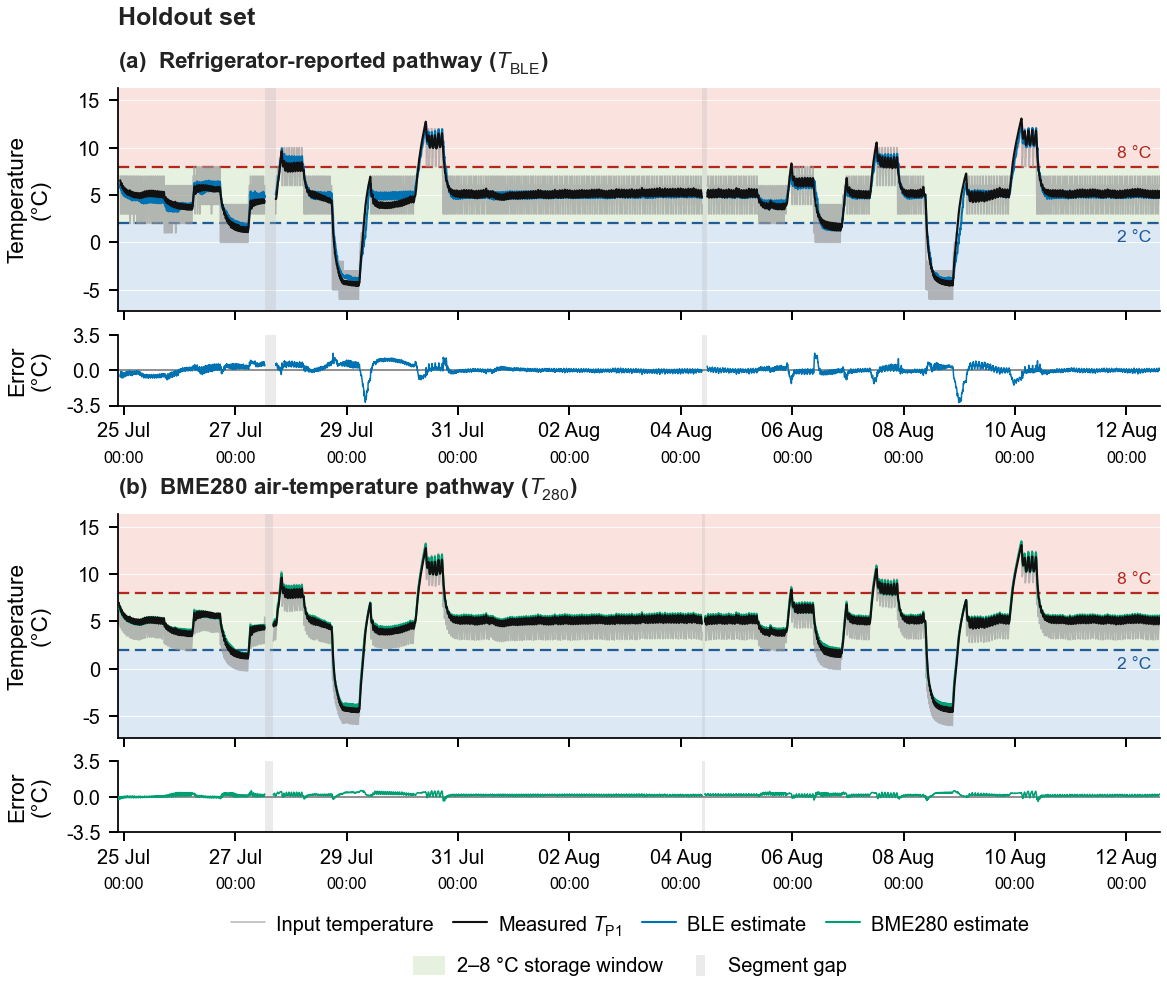

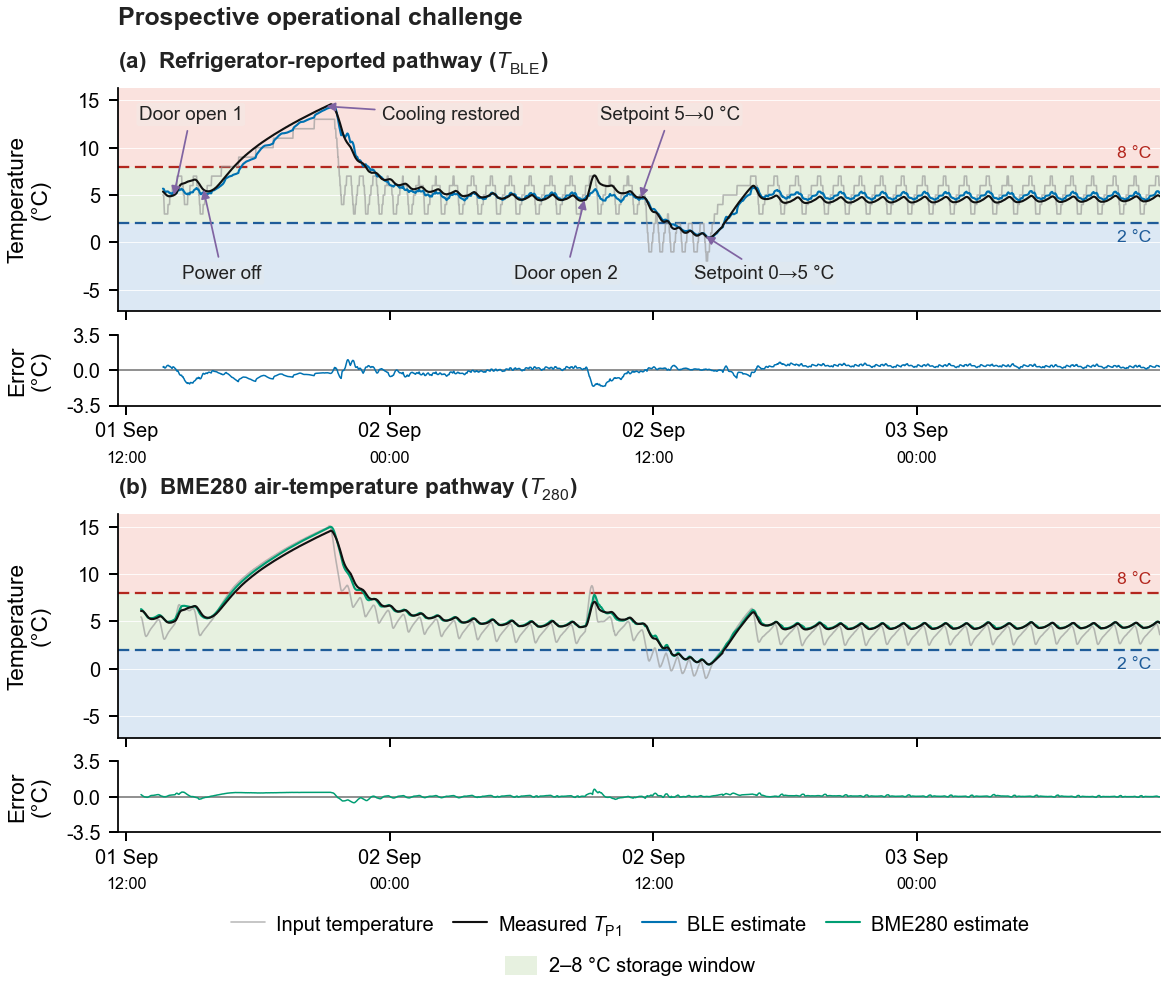

Event origin: 2026-09-01 11:37:00; first raw sample: 2026-09-01 11:41:09
No additional TP1 clock correction or lookback shift applied.
           label               start                 end                                      source     previous_sample  elapsed_min_from_run_start
     Door open 1 2026-09-01 14:10:00 2026-09-01 14:33:00               Experimental notes: t153–t176                 NaT                  153.000000
       Power off 2026-09-01 15:31:00                 NaT                    Experimental notes: t234                 NaT                  234.000000
Cooling restored 2026-09-01 21:07:00                 NaT                    Experimental notes: t570                 NaT                  570.000000
     Door open 2 2026-09-02 08:52:00 2026-09-02 09:12:00  Experimental notes: t1275, duration 20 min                 NaT                 1275.000000
 Setpoint 5→0 °C 2026-09-02 11:26:13                 NaT First raw sample reporting the new setpoint 2026-09-02 11:25:13

In [15]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerPatch

# t denotes elapsed minutes from the experimental-note run start, not row number.
NOTE_RUN_START = "11:37:00"
TRACE_LW = 0.85
ERROR_LW = 0.60
INPUT_LW = 0.65

# Figures are staged with the other publication exports.
SEPARATE_FIGURE_DIR = FINAL_FIGURE_DIR / "manuscript"


def make_separate_publication_figures():
    required = ["evaluation_prediction_frames", "df_prospective_challenge"]
    if any(name not in globals() for name in required):
        raise RuntimeError("Run Sections 2–14 before this cell.")

    # Original, unwindowed prospective dataset.
    raw = (
        df_prospective_challenge.copy()
        .sort_values(TIME_COL)
        .reset_index(drop=True)
    )
    raw[TIME_COL] = pd.to_datetime(raw[TIME_COL], errors="raise")

    if (
        raw.empty
        or raw[TIME_COL].isna().any()
        or raw[TIME_COL].duplicated().any()
    ):
        raise ValueError(
            "Raw prospective timestamps must be nonempty, unique and valid."
        )

    setpoints = pd.to_numeric(raw[SETPOINT_COL], errors="raise")

    if not np.isfinite(setpoints).all():
        raise ValueError(
            "Raw prospective setpoints contain missing/nonfinite values."
        )

    run_start = (
        raw[TIME_COL].iloc[0].normalize()
        + pd.to_timedelta(NOTE_RUN_START)
    )

    if not (
        pd.Timedelta(0)
        <= raw[TIME_COL].iloc[0] - run_start
        < pd.Timedelta(hours=1)
    ):
        raise ValueError(
            "Check NOTE_RUN_START against the raw prospective run date."
        )

    def note_time(minutes):
        return run_start + pd.Timedelta(minutes=minutes)

    # Experimental events referenced to the original prospective timeline.
    events = [
        dict(
            label="Door open 1",
            start=note_time(153),
            end=note_time(176),
            source="Experimental notes: t153–t176",
        ),
        dict(
            label="Power off",
            start=note_time(234),
            end=pd.NaT,
            source="Experimental notes: t234",
        ),
        dict(
            label="Cooling restored",
            start=note_time(570),
            end=pd.NaT,
            source="Experimental notes: t570",
        ),
        dict(
            label="Door open 2",
            start=note_time(1275),
            end=note_time(1295),
            source="Experimental notes: t1275, duration 20 min",
        ),
    ]

    # Identify setpoint transitions from the original prospective dataset.
    for old, new in [(5.0, 0.0), (0.0, 5.0)]:
        positions = np.flatnonzero(
            np.isclose(setpoints.shift(), old)
            & np.isclose(setpoints, new)
        )

        if len(positions) != 1:
            raise ValueError(
                f"Expected one raw {old:g}→{new:g} °C transition; "
                f"found {len(positions)}."
            )

        i = int(positions[0])

        events.append(
            dict(
                label=f"Setpoint {old:g}→{new:g} °C",
                start=raw[TIME_COL].iloc[i],
                end=pd.NaT,
                previous_sample=raw[TIME_COL].iloc[i - 1],
                source="First raw sample reporting the new setpoint",
            )
        )

    for event in events:
        if not (
            raw[TIME_COL].iloc[0]
            <= event["start"]
            <= raw[TIME_COL].iloc[-1]
        ):
            raise ValueError(
                f"Event outside the raw run: {event['label']}"
            )

    event_table = pd.DataFrame(events)
    event_table["elapsed_min_from_run_start"] = (
        event_table["start"] - run_start
    ).dt.total_seconds() / 60

    colors = {
        "true": "#111111",
        "predictor": "#9A9A9A",
        "ble": "#0072B2",
        "bme": "#009E73",
    }

    specs = [
        (
            "original_holdout",
            "refrigerator_ble_input",
            T_BLE_COL,
            colors["ble"],
            r"(a)  Refrigerator-reported pathway ($T_{\mathrm{BLE}}$)",
        ),
        (
            "original_holdout",
            "bme280_input",
            T_280_COL,
            colors["bme"],
            r"(b)  BME280 air-temperature pathway ($T_{280}$)",
        ),
        (
            "prospective_challenge",
            "refrigerator_ble_input",
            T_BLE_COL,
            colors["ble"],
            r"(c)  Refrigerator-reported pathway ($T_{\mathrm{BLE}}$)",
        ),
        (
            "prospective_challenge",
            "bme280_input",
            T_280_COL,
            colors["bme"],
            r"(d)  BME280 air-temperature pathway ($T_{280}$)",
        ),
    ]

    frames = []

    for split, pathway, input_col, color, title in specs:
        frame = evaluation_prediction_frames[(pathway, split)].copy()
        frame[TIME_COL] = pd.to_datetime(
            frame[TIME_COL],
            errors="raise",
        )
        frame = (
            frame.sort_values(TIME_COL)
            .reset_index(drop=True)
        )

        columns = [
            T_P1_COL,
            "T_P1_hat_lstm",
            input_col,
        ]

        if (
            frame.empty
            or frame[TIME_COL].isna().any()
            or frame[TIME_COL].duplicated().any()
        ):
            raise ValueError(
                f"Invalid prediction timestamps: {pathway}, {split}"
            )

        if not np.isfinite(
            frame[columns].to_numpy(dtype=float)
        ).all():
            raise ValueError(
                f"Nonfinite plotted temperatures: {pathway}, {split}"
            )

        if split == "prospective_challenge":
            matched = (
                raw.set_index(TIME_COL)
                .reindex(frame[TIME_COL])
            )

            if not np.allclose(
                matched[T_P1_COL],
                frame[T_P1_COL],
                rtol=0,
                atol=1e-6,
            ):
                raise ValueError(
                    "Prospective predictions do not match "
                    "the raw TP1 timeline."
                )

        frame["error"] = (
            frame["T_P1_hat_lstm"]
            - frame[T_P1_COL]
        )

        frames.append(frame)

    # Shared scales across all panels for direct visual comparison.
    values = np.concatenate(
        [
            frame[
                [T_P1_COL, "T_P1_hat_lstm", spec[2]]
            ].to_numpy(dtype=float).ravel()
            for frame, spec in zip(frames, specs)
        ]
    )

    pad = max(0.6, 0.06 * np.ptp(values))
    ymin = min(values.min() - pad, 1.4)
    ymax = max(values.max() + pad, 8.6)

    error_limit = (
        np.ceil(
            max(
                frame.error.abs().max()
                for frame in frames
            )
            * 1.05
            * 2
        )
        / 2
    )

    holdout_start = min(
        frame[TIME_COL].min()
        for frame in frames[:2]
    )
    holdout_end = max(
        frame[TIME_COL].max()
        for frame in frames[:2]
    )

    style = dict(globals().get("FIGURE_RC", {}))
    style.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Arial",
                "Helvetica",
                "DejaVu Sans",
            ],
            "font.size": 9,
            "font.weight": "normal",
            "axes.titleweight": "normal",
            "mathtext.fontset": "custom",
            "mathtext.rm": "Arial",
            "mathtext.it": "Arial:italic",
            "mathtext.bf": "Arial:bold",
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "axes.linewidth": 0.7,
            "text.color": "#000000",
            "axes.labelcolor": "#000000",
            "axes.edgecolor": "#000000",
            "xtick.color": "#000000",
            "ytick.color": "#000000",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.unicode_minus": False,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
        }
    )

    class OrientedBandHandler(HandlerPatch):
        """Match vertical recording gaps and horizontal storage shading."""

        def __init__(self, vertical=False):
            super().__init__()
            self.vertical = vertical

        def create_artists(
            self,
            legend,
            original,
            xdescent,
            ydescent,
            width,
            height,
            fontsize,
            transform,
        ):
            if self.vertical:
                w, h = height * 0.45, height
            else:
                w, h = width, height * 0.28

            symbol = Rectangle(
                (
                    (width - w) / 2 - xdescent,
                    (height - h) / 2 - ydescent,
                ),
                w,
                h,
                facecolor=original.get_facecolor(),
                edgecolor="none",
                transform=transform,
            )

            return [symbol]

    trace_handles = [
        Line2D(
            [],
            [],
            color=colors["predictor"],
            lw=INPUT_LW,
            alpha=0.68,
            label="Input temperature",
        ),
        Line2D(
            [],
            [],
            color=colors["true"],
            lw=TRACE_LW,
            label=r"Measured $T_{\mathrm{P1}}$",
        ),
        Line2D(
            [],
            [],
            color=colors["ble"],
            lw=TRACE_LW,
            label="BLE estimate",
        ),
        Line2D(
            [],
            [],
            color=colors["bme"],
            lw=TRACE_LW,
            label="BME280 estimate",
        ),
    ]

    gap_key = Patch(
        fc="#BDBDBD",
        alpha=0.30,
        label="Segment gap",
    )

    storage_key = Patch(
        fc="#E7F1E0",
        label="2–8 °C storage window",
    )

    handlers = {
        gap_key: OrientedBandHandler(vertical=True)
    }

    def has_segment_gap(frame):
        dt = (
            frame[TIME_COL]
            .diff()
            .dt.total_seconds()
        )

        breaks = (
            frame.source_segment_id.ne(
                frame.source_segment_id.shift()
            )
            | dt.gt(90)
        )

        return bool(breaks.iloc[1:].any())

    def apply_two_line_datetime_ticks(
        axis,
        start,
        end,
        prospective,
    ):
        """
        Draw the date and time as separate lines.

        Dates use the normal 8-point tick size.
        Times use a smaller 6.5-point font.
        """
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        if prospective:
            # Uniform 12-hour intervals.
            first_tick = start.ceil("12h")
            tick_times = pd.date_range(
                first_tick,
                end.floor("12h"),
                freq="12h",
            )
        else:
            # Uniform two-day intervals, anchored at midnight.
            first_tick = start.normalize()

            if first_tick < start:
                first_tick += pd.Timedelta(days=1)

            tick_times = pd.date_range(
                first_tick,
                end.normalize(),
                freq="2D",
            )

        axis.set_xticks(tick_times)

        # Date line.
        axis.set_xticklabels(
            [
                timestamp.strftime("%d %b")
                for timestamp in tick_times
            ],
            fontsize=8.0,
        )

        axis.tick_params(
            axis="x",
            pad=3.0,
        )

        # Smaller time line.
        for timestamp in tick_times:
            axis.annotate(
                timestamp.strftime("%H:%M"),
                xy=(
                    mdates.date2num(timestamp),
                    0,
                ),
                xycoords=axis.get_xaxis_transform(),
                xytext=(0, -18),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=6.5,
                color="#000000",
                annotation_clip=False,
            )

    def draw_two_panel_figure(
        panel_indices,
        set_heading,
        filename_stem,
    ):
        # 6.77 inches corresponds to the 172 mm IOP double-column width.
        fig = plt.figure(
            figsize=(6.77, 5.55),
            dpi=180,
        )

        outer = fig.add_gridspec(
            3,
            1,
            height_ratios=[3.95, 1.35, 3.95],
            left=0.13,
            right=0.985,
            top=0.895,
            bottom=0.15,
            hspace=0,
        )

        temperature_axes = []
        error_axes = []

        for local_panel, global_panel in enumerate(
            panel_indices
        ):
            frame = frames[global_panel]
            spec = specs[global_panel]

            (
                split,
                pathway,
                input_col,
                color,
                source_title,
            ) = spec

            prospective = (
                split == "prospective_challenge"
            )

            inner = outer[
                2 * local_panel
            ].subgridspec(
                2,
                1,
                height_ratios=[3, 0.95],
                hspace=0.16,
            )

            ax = fig.add_subplot(inner[0])
            err = fig.add_subplot(
                inner[1],
                sharex=ax,
            )

            temperature_axes.append(ax)
            error_axes.append(err)

            if prospective:
                start = run_start
                end = raw[TIME_COL].iloc[-1]
            else:
                start = holdout_start
                end = holdout_end

            ax.set_ylim(ymin, ymax)

            for lo, hi, fill in [
                (ymin, 2, "#DCE8F4"),
                (2, 8, "#E7F1E0"),
                (8, ymax, "#FAE2DE"),
            ]:
                ax.axhspan(
                    lo,
                    hi,
                    color=fill,
                    lw=0,
                    zorder=0,
                )

            for limit, shade in [
                (2, "#1F5C99"),
                (8, "#B3271E"),
            ]:
                ax.axhline(
                    limit,
                    color=shade,
                    lw=0.9,
                    ls=(0, (5, 2.5)),
                    zorder=1,
                )

                ax.annotate(
                    f"{limit} °C",
                    xy=(0.992, limit),
                    xycoords=(
                        "axes fraction",
                        "data",
                    ),
                    xytext=(
                        0,
                        -2.5 if limit == 2 else 2.5,
                    ),
                    textcoords="offset points",
                    ha="right",
                    va=(
                        "top"
                        if limit == 2
                        else "bottom"
                    ),
                    fontsize=7,
                    color=shade,
                    zorder=6,
                )

            err.axhline(
                0,
                color="#6E6E6E",
                lw=0.6,
            )

            dt = (
                frame[TIME_COL]
                .diff()
                .dt.total_seconds()
            )

            breaks = (
                frame.source_segment_id.ne(
                    frame.source_segment_id.shift()
                )
                | dt.gt(90)
            )

            for _, segment in frame.groupby(
                breaks.cumsum(),
                sort=False,
            ):
                t = segment[TIME_COL]

                ax.plot(
                    t,
                    segment[input_col],
                    color=colors["predictor"],
                    lw=INPUT_LW,
                    alpha=0.68,
                    zorder=2,
                )

                ax.plot(
                    t,
                    segment["T_P1_hat_lstm"],
                    color=color,
                    lw=TRACE_LW,
                    alpha=1,
                    zorder=3,
                )

                # Plot measured TP1 last so that it remains visible.
                ax.plot(
                    t,
                    segment[T_P1_COL],
                    color=colors["true"],
                    lw=TRACE_LW,
                    alpha=1,
                    zorder=4,
                )

                err.plot(
                    t,
                    segment.error,
                    color=color,
                    lw=ERROR_LW,
                    zorder=3,
                )

            for i in np.flatnonzero(
                breaks.to_numpy()
            )[1:]:
                for axis in (ax, err):
                    axis.axvspan(
                        frame[TIME_COL].iloc[i - 1],
                        frame[TIME_COL].iloc[i],
                        color="#BDBDBD",
                        alpha=0.30,
                        lw=0,
                        zorder=1.4,
                    )

            ax.set_ylabel(
                "Temperature\n(°C)",
                linespacing=1.18,
            )

            err.set_ylabel(
                "Error\n(°C)",
                linespacing=1.18,
            )

            ax.yaxis.set_label_coords(
                -0.065,
                0.5,
            )

            err.yaxis.set_label_coords(
                -0.065,
                0.5,
            )

            err.set_ylim(
                -error_limit,
                error_limit,
            )

            err.set_yticks(
                [
                    -error_limit,
                    0,
                    error_limit,
                ]
            )

            ax.tick_params(labelbottom=False)

            ax.grid(
                axis="y",
                color="white",
                lw=0.4,
                alpha=0.85,
            )

            for axis in (ax, err):
                axis.set_xlim(start, end)
                axis.minorticks_off()
                axis.tick_params(
                    top=False,
                    right=False,
                    direction="out",
                )

            pathway_title = source_title.split(
                "  ",
                1,
            )[1]

            panel_letter = chr(
                ord("a") + local_panel
            )

            ax.set_title(
                f"({panel_letter})  {pathway_title}",
                loc="left",
                fontweight="bold",
                pad=8,
                color="#222222",
            )

            apply_two_line_datetime_ticks(
                err,
                start,
                end,
                prospective,
            )

            # Event annotations appear only in the refrigerator-reported
            # prospective panel and apply to both prospective pathways.
            if global_panel == 2:
                callouts = [
                    (
                        0,
                        "Door open 1",
                        (0.07, 0.88),
                        True,
                    ),
                    (
                        1,
                        "Power off",
                        (0.10, 0.17),
                        False,
                    ),
                    (
                        2,
                        "Cooling restored",
                        (0.32, 0.88),
                        True,
                    ),
                    (
                        3,
                        "Door open 2",
                        (0.43, 0.17),
                        False,
                    ),
                    (
                        4,
                        "Setpoint 5→0 °C",
                        (0.53, 0.88),
                        True,
                    ),
                    (
                        5,
                        "Setpoint 0→5 °C",
                        (0.62, 0.17),
                        False,
                    ),
                ]

                plot_x = mdates.date2num(
                    frame[TIME_COL]
                )

                plot_y = frame[
                    T_P1_COL
                ].to_numpy(dtype=float)

                for (
                    event_index,
                    label,
                    position,
                    upper,
                ) in callouts:
                    event_x = mdates.date2num(
                        events[event_index]["start"]
                    )

                    event_y = np.interp(
                        event_x,
                        plot_x,
                        plot_y,
                    )

                    ax.annotate(
                        label,
                        xy=(event_x, event_y),
                        xycoords="data",
                        xytext=position,
                        textcoords="axes fraction",
                        ha="center",
                        va="center",
                        fontsize=7.5,
                        color="#222222",
                        linespacing=1.15,
                        zorder=8,
                        bbox=dict(
                            boxstyle="round,pad=0.13",
                            fc=(
                                "#F6E7E3"
                                if upper
                                else "#E0E9F0"
                            ),
                            ec="none",
                            alpha=0.90,
                        ),
                        arrowprops=dict(
                            arrowstyle="-|>",
                            color="#8064A2",
                            lw=0.70,
                            mutation_scale=7,
                            shrinkA=2,
                            shrinkB=0,
                            connectionstyle=(
                                "arc3,rad=0"
                            ),
                        ),
                    )

        first_position = (
            temperature_axes[0]
            .get_position()
        )

        fig.text(
            first_position.x0,
            first_position.y1 + 0.058,
            set_heading,
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="bottom",
            color="#222222",
        )

        figure_has_gap = any(
            has_segment_gap(frames[i])
            for i in panel_indices
        )

        band_handles = [storage_key]

        if figure_has_gap:
            band_handles.append(gap_key)

        # Two legend rows positioned below the smaller time labels.
        for handles, y in [
            (trace_handles, 0.035),
            (band_handles, -0.002),
        ]:
            fig.legend(
                handles=handles,
                loc="lower center",
                bbox_to_anchor=(0.55, y),
                ncol=len(handles),
                frameon=False,
                fontsize=8,
                columnspacing=1.0,
                handlelength=1.7,
                handletextpad=0.55,
                handleheight=1.25,
                handler_map=handlers,
                borderaxespad=0,
            )

        SEPARATE_FIGURE_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )

        pdf_path = (
            SEPARATE_FIGURE_DIR
            / f"{filename_stem}.pdf"
        )
        png_path = (
            SEPARATE_FIGURE_DIR
            / f"{filename_stem}.png"
        )
        preview_path = (
            SEPARATE_FIGURE_DIR
            / f"{filename_stem}_preview.png"
        )

        save_options = dict(
            bbox_inches="tight",
            pad_inches=0.04,
            facecolor="white",
            transparent=False,
        )

        fig.savefig(
            pdf_path,
            format="pdf",
            **save_options,
        )

        fig.savefig(
            png_path,
            format="png",
            dpi=600,
            **save_options,
        )

        fig.savefig(
            preview_path,
            format="png",
            dpi=180,
            **save_options,
        )

        plt.close(fig)

        return {
            "pdf": pdf_path,
            "png": png_path,
            "preview": preview_path,
        }

    with plt.rc_context(style):
        holdout_paths = draw_two_panel_figure(
            [0, 1],
            "Holdout set",
            "figure_4_holdout_temperature_tracking",
        )

        prospective_paths = draw_two_panel_figure(
            [2, 3],
            "Prospective operational challenge",
            "figure_5_prospective_challenge_temperature_tracking",
        )

        try:
            from IPython.display import Image, display
        except ImportError:
            pass
        else:
            display(
                Image(
                    filename=str(
                        holdout_paths["preview"]
                    ),
                    width=900,
                )
            )

            display(
                Image(
                    filename=str(
                        prospective_paths["preview"]
                    ),
                    width=900,
                )
            )

    print(
        f"Event origin: {run_start}; "
        f"first raw sample: {raw[TIME_COL].iloc[0]}"
    )
    print(
        "No additional TP1 clock correction or "
        "lookback shift applied."
    )

    FINAL_TABLE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    event_table.to_csv(
        FINAL_TABLE_DIR
        / "table_s2b_prospective_operational_challenge_timeline.csv",
        index=False,
    )

    print(event_table.to_string(index=False))

    print(
        "Saved holdout figure:",
        holdout_paths["pdf"],
        "and",
        holdout_paths["png"],
    )

    print(
        "Saved prospective figure:",
        prospective_paths["pdf"],
        "and",
        prospective_paths["png"],
    )

    return (
        {
            "holdout": holdout_paths,
            "prospective": prospective_paths,
        },
        event_table,
    )


separate_figures, separate_figure_event_times = (
    make_separate_publication_figures()
)

### Supplementary estimator-comparison figures

This cell reproduces supplementary Figures S4a and S4b from the locked estimator-comparison results. It uses one bright estimator palette across both pathways, identical y-axis limits for matching metrics, vector PDF export and 600-dpi PNG export. Files are staged under `outputs/run_artifacts/publication_outputs/figures/supplementary/` and copied to `outputs/publication/figures/supplementary/` by the final export cell.


In [16]:
# Generate supplementary Figures S4a and S4b from the locked comparison results.
if "development_continuous_comparison" not in globals():
    raise RuntimeError("Run the estimator-comparison section before this cell.")

SUPPLEMENTARY_FIGURE_DIR = FINAL_FIGURE_DIR / "supplementary"
SUPPLEMENTARY_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SUPPLEMENTARY_ESTIMATORS = [
    ("direct_input", "Direct input"),
    ("instantaneous_affine", "Affine"),
    ("first_order_thermal", "First-order"),
    ("ridge_temporal", "Ridge"),
    ("lstm", "LSTM"),
]
SUPPLEMENTARY_DATASETS = [
    ("validation", "Validation"),
    ("original_holdout", "Holdout"),
    ("prospective_challenge", "Prospective"),
]
SUPPLEMENTARY_METRICS = [
    ("rmse", "(a) RMSE"),
    ("mae", "(b) MAE"),
    ("p95_abs_error", "(c) P95 absolute error"),
    ("bias", "(d) Absolute mean bias"),
]
SUPPLEMENTARY_Y_LIMITS = {
    "rmse": 1.75,
    "mae": 1.40,
    "p95_abs_error": 3.20,
    "bias": 0.90,
}
SUPPLEMENTARY_ESTIMATOR_COLORS = [
    "#2A78D6",  # direct input
    "#EB6834",  # affine
    "#1BAF7A",  # first-order
    "#EDA100",  # ridge
    "#E87BA4",  # LSTM
]


def create_supplementary_estimator_figure(input_key, pathway_title, stem):
    subset = development_continuous_comparison.loc[
        development_continuous_comparison["input_key"].eq(input_key)
    ].copy()
    expected = len(SUPPLEMENTARY_ESTIMATORS) * len(SUPPLEMENTARY_DATASETS)
    if len(subset) != expected:
        raise AssertionError(
            f"Expected {expected} comparison rows for {input_key}; found {len(subset)}."
        )
    lookup = subset.set_index(["split", "estimator_key"])
    if not lookup.index.is_unique:
        raise AssertionError(f"Duplicate estimator results for {input_key}.")

    style = dict(globals().get("FIGURE_RC", {}))
    style.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.titleweight": "bold",
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.7,
        "axes.edgecolor": "#1A1A1A",
        "axes.labelcolor": "#1A1A1A",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.unicode_minus": False,
        "grid.color": "#D9D9D9",
        "grid.linewidth": 0.5,
        "grid.alpha": 0.9,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })

    with plt.rc_context(style):
        fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.45))
        x = np.arange(len(SUPPLEMENTARY_DATASETS))
        width = 0.155
        offsets = (np.arange(len(SUPPLEMENTARY_ESTIMATORS)) - 2) * width

        for axis, (metric_key, panel_title) in zip(
            axes.flat, SUPPLEMENTARY_METRICS
        ):
            for estimator_index, (estimator_key, estimator_label) in enumerate(
                SUPPLEMENTARY_ESTIMATORS
            ):
                values = [
                    float(lookup.loc[(split, estimator_key), metric_key])
                    for split, _ in SUPPLEMENTARY_DATASETS
                ]
                if metric_key == "bias":
                    values = [abs(value) for value in values]
                axis.bar(
                    x + offsets[estimator_index],
                    values,
                    width=width,
                    color=SUPPLEMENTARY_ESTIMATOR_COLORS[estimator_index],
                    edgecolor="#1A1A1A",
                    linewidth=0.35,
                    label=estimator_label,
                    zorder=3,
                )
            axis.set_title(panel_title, loc="left", pad=5)
            axis.set_ylabel("Temperature error (°C)")
            axis.set_xticks(x)
            axis.set_xticklabels([label for _, label in SUPPLEMENTARY_DATASETS])
            axis.set_ylim(0, SUPPLEMENTARY_Y_LIMITS[metric_key])
            axis.set_axisbelow(True)
            axis.grid(axis="y")
            axis.margins(x=0.05)

        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=5,
            bbox_to_anchor=(0.5, 0.012),
            columnspacing=1.0,
            handlelength=1.25,
        )
        fig.suptitle(pathway_title, fontsize=10, fontweight="bold", y=0.992)
        fig.subplots_adjust(
            left=0.105,
            right=0.99,
            top=0.925,
            bottom=0.145,
            hspace=0.40,
            wspace=0.27,
        )

        pdf_path = SUPPLEMENTARY_FIGURE_DIR / f"{stem}.pdf"
        png_path = SUPPLEMENTARY_FIGURE_DIR / f"{stem}.png"
        save_options = dict(
            bbox_inches="tight", pad_inches=0.04,
            facecolor="white", transparent=False,
        )
        fig.savefig(pdf_path, format="pdf", **save_options)
        fig.savefig(png_path, format="png", dpi=600, **save_options)
        plt.close(fig)
    return {"pdf": pdf_path, "png": png_path}


supplementary_figures = {
    "Figure S4a": create_supplementary_estimator_figure(
        "refrigerator_ble_input",
        "Refrigerator-reported BLE pathway",
        "figure_s4a_ble_reference_estimator_comparison",
    ),
    "Figure S4b": create_supplementary_estimator_figure(
        "bme280_input",
        "BME280 pathway",
        "figure_s4b_bme280_reference_estimator_comparison",
    ),
}

supplementary_figure_manifest = pd.DataFrame([
    {
        "figure": figure_label,
        "pdf": str((FINAL_OUTPUT_ROOT / "figures/supplementary" / paths["pdf"].name).relative_to(REPO_ROOT)),
        "png": str((FINAL_OUTPUT_ROOT / "figures/supplementary" / paths["png"].name).relative_to(REPO_ROOT)),
    }
    for figure_label, paths in supplementary_figures.items()
])
supplementary_figure_manifest.to_csv(
    SUPPLEMENTARY_FIGURE_DIR / "supplementary_figure_manifest.csv",
    index=False,
)
display(supplementary_figure_manifest)
print("Supplementary figures staged in:", SUPPLEMENTARY_FIGURE_DIR.resolve())


,figure,pdf,png
0,Figure S4a,outputs/publication/figures/supplementary/figu...,outputs/publication/figures/supplementary/figu...
1,Figure S4b,outputs/publication/figures/supplementary/figu...,outputs/publication/figures/supplementary/figu...


Supplementary figures staged in: repository/outputs/run_artifacts/publication_outputs/figures/supplementary


## 16. Manuscript and Supplementary Tables

This section converts the locked analysis outputs into publication-oriented tables. Tables 1–4 contain the main-manuscript dataset, pointwise, excursion and transition-rate results. Supplementary Table S2 contains the programmed temperature schedules and prospective operational-challenge timeline, while Table S3 records the LSTM features and implementation settings. The complete estimator hierarchy is retained as the source data for supplementary Figure S4.

The rate metrics use actual elapsed minutes between consecutive observations within a continuous segment. They do not bridge gaps and do not depend on an arbitrary definition of “fast” or “slow.” The original holdout remains the primary independent test; the prospective operational challenge supplies a separate assessment of realistic transitions and does not replace or augment the original holdout.


In [17]:
# Generate manuscript-ready main and supplementary tables from locked outputs.
required_table_objects = [
    "df_train", "df_val", "df_original_holdout_split",
    "df_prospective_challenge_split", "development_continuous_comparison",
    "development_excursion_comparison", "development_rate_comparison",
    "lstm_hyperparameters", "TEMPERATURE_INPUTS",
    "separate_figure_event_times",
]
missing_table_objects = [
    name for name in required_table_objects if name not in globals()
]
if missing_table_objects:
    raise RuntimeError(
        "Run all preceding notebook sections before generating manuscript tables. "
        f"Missing objects: {missing_table_objects}"
    )

MANUSCRIPT_TABLE_ROOT = FINAL_TABLE_DIR
MAIN_TABLE_DIR = MANUSCRIPT_TABLE_ROOT
SUPPLEMENTARY_TABLE_DIR = MANUSCRIPT_TABLE_ROOT


INPUT_DISPLAY_NAMES = {
    "bme280_input": "BME280 air temperature, T_280",
    "refrigerator_ble_input": (
        "Refrigerator-reported BLE temperature, T_BLE"
    ),
}
INPUT_ORDER = {"refrigerator_ble_input": 0, "bme280_input": 1}
ESTIMATOR_ORDER = {
    "direct_input": 0,
    "instantaneous_affine": 1,
    "first_order_thermal": 2,
    "ridge_temporal": 3,
    "lstm": 4,
}
DATASET_DISPLAY_NAMES = {
    "validation": "Validation",
    "original_holdout": "Original holdout",
    "prospective_challenge": "Prospective operational challenge",
}
EVALUATION_SPLITS = ("original_holdout", "prospective_challenge")
EVALUATION_ORDER = {"original_holdout": 0, "prospective_challenge": 1}


def compact_date_range(start, end):
    """Format one collection period without platform-specific strftime codes."""
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    start_text = f"{start.day} {start.strftime('%b %Y')}"
    end_text = f"{end.day} {end.strftime('%b %Y')}"
    return f"{start_text}–{end_text}"


def latex_escape(value):
    """Escape ordinary table text while restoring the manuscript temperature notation."""
    text = "" if pd.isna(value) else str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    notation = {
        r"T\_280": r"$T_{280}$",
        r"T\_BLE": r"$T_{\mathrm{BLE}}$",
        r"T\_P1": r"$T_{\mathrm{P1}}$",
        "°C": r"$^{\circ}$C",
        "±": r"$\pm$",
        "–": "--",
    }
    for old, new in notation.items():
        text = text.replace(old, new)
    return text


def dataframe_to_iop_latex(
    display_frame,
    caption,
    label,
    alignment,
    note=None,
):
    """Return a simple IOP-compatible LaTeX table with horizontal rules only."""
    lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        rf"\caption{{{latex_escape(caption)}}}",
        rf"\label{{{label}}}",
        r"\small",
        rf"\begin{{tabular}}{{{alignment}}}",
        r"\hline",
        " & ".join(latex_escape(column) for column in display_frame.columns)
        + r" \\",
        r"\hline",
    ]
    for row in display_frame.itertuples(index=False, name=None):
        lines.append(" & ".join(latex_escape(value) for value in row) + r" \\")
    lines.extend([r"\hline", r"\end{tabular}"])
    if note:
        lines.extend([
            r"\par\smallskip",
            r"\begin{minipage}{0.98\textwidth}",
            r"\footnotesize " + latex_escape(note),
            r"\end{minipage}",
        ])
    lines.append(r"\end{table}")
    return "\n".join(lines) + "\n"


def segment_inventory_for_split(frame, dataset_role):
    """Return exact segment counts and durations for one processed split."""
    inventory = (
        frame.groupby(SEG_COL, sort=False)
        .agg(
            observations=(SEG_COL, "size"),
            start=(TIME_COL, "min"),
            end=(TIME_COL, "max"),
        )
        .reset_index()
    )
    # Include the final nominal one-minute observation in the represented duration.
    inventory["duration_h"] = (
        (inventory["end"] - inventory["start"]).dt.total_seconds() / 3600.0
        + 1.0 / 60.0
    )
    inventory.insert(0, "dataset_role", dataset_role)
    return inventory


# Table 1: dataset composition and segment-duration summary.
split_frames = [
    ("Training", df_train),
    ("Validation", df_val),
    ("Original holdout", df_original_holdout_split),
    ("Prospective operational challenge", df_prospective_challenge_split),
]
segment_inventory = pd.concat(
    [segment_inventory_for_split(frame, role) for role, frame in split_frames],
    ignore_index=True,
)
table_1_rows = []
for role, frame in split_frames:
    role_segments = segment_inventory.loc[
        segment_inventory["dataset_role"].eq(role)
    ]
    durations = role_segments["duration_h"]
    table_1_rows.append({
        "Dataset role": role,
        "Collection period": compact_date_range(
            frame[TIME_COL].min(), frame[TIME_COL].max()
        ),
        "Continuous segments, n": int(len(role_segments)),
        "Observations, n": int(len(frame)),
        "Median segment duration, h": float(durations.median()),
        "Minimum segment duration, h": float(durations.min()),
        "Maximum segment duration, h": float(durations.max()),
    })
table_1_raw = pd.DataFrame(table_1_rows)
table_1_display = table_1_raw.loc[:, [
    "Dataset role", "Collection period", "Continuous segments, n",
    "Observations, n",
]].copy()
table_1_display["Segment duration, median (range), h"] = [
    f"{row['Median segment duration, h']:.1f} "
    f"({row['Minimum segment duration, h']:.1f}–"
    f"{row['Maximum segment duration, h']:.1f})"
    for _, row in table_1_raw.iterrows()
]
table_1_display["Observations, n"] = table_1_display[
    "Observations, n"
].map(lambda value: f"{int(value):,}")


# Table 2: pointwise LSTM performance on both separate evaluation datasets.
primary_evaluation_continuous = development_continuous_comparison.loc[
    development_continuous_comparison["split"].isin(EVALUATION_SPLITS)
    & development_continuous_comparison["estimator_key"].eq("lstm")
].copy()
if len(primary_evaluation_continuous) != 4:
    raise AssertionError("Expected two LSTM results for each evaluation dataset.")
primary_evaluation_continuous["_dataset_order"] = (
    primary_evaluation_continuous["split"].map(EVALUATION_ORDER)
)
primary_evaluation_continuous["_input_order"] = (
    primary_evaluation_continuous["input_key"].map(INPUT_ORDER)
)
primary_evaluation_continuous.sort_values(
    ["_dataset_order", "_input_order"], inplace=True
)
table_2_raw = primary_evaluation_continuous.assign(
    **{
        "Dataset": primary_evaluation_continuous["split"].map(
            DATASET_DISPLAY_NAMES
        ),
        "Temperature input": primary_evaluation_continuous["input_key"].map(
            INPUT_DISPLAY_NAMES
        ),
    }
).rename(columns={
    "n": "Predictions, n",
    "rmse": "RMSE, °C",
    "mae": "MAE, °C",
    "bias": "Bias, °C",
    "p95_abs_error": "P95 absolute error, °C",
})[[
    "Dataset", "Temperature input", "Predictions, n", "RMSE, °C",
    "MAE, °C", "Bias, °C", "P95 absolute error, °C",
]].reset_index(drop=True)
table_2_display = table_2_raw.copy()
table_2_display["Predictions, n"] = table_2_display["Predictions, n"].map(
    lambda value: f"{int(value):,}"
)
for column in [
    "RMSE, °C", "MAE, °C", "Bias, °C", "P95 absolute error, °C",
]:
    table_2_display[column] = table_2_display[column].map(
        lambda value: f"{float(value):.3f}"
    )


# Table 3: excursion-classification performance on both evaluation datasets.
primary_evaluation_excursions = development_excursion_comparison.loc[
    development_excursion_comparison["split"].isin(EVALUATION_SPLITS)
    & development_excursion_comparison["estimator_key"].eq("lstm")
].copy()

if len(primary_evaluation_excursions) != 4:
    raise AssertionError("Expected two LSTM results for each evaluation dataset.")

table_3_rows = []
for _, row in primary_evaluation_excursions.iterrows():
    for prefix, state in [
        ("cold", "Cold (<2 °C)"),
        ("hot", "Hot (>8 °C)"),
    ]:
        table_3_rows.append({
            "split": row["split"],
            "input_key": row["input_key"],
            "Dataset": DATASET_DISPLAY_NAMES[row["split"]],
            "Temperature input": INPUT_DISPLAY_NAMES[row["input_key"]],
            "Excursion state": state,
            "Reference excursion duration, min": float(
                row[f"{prefix}_reference_excursion_duration_min"]
            ),
            "Excursion PPV, %": float(
                row[f"{prefix}_excursion_ppv_pct"]
            ),
            "Missed reference-excursion duration, min": float(
                row[f"{prefix}_missed_reference_excursion_duration_min"]
            ),
            "Missed reference-excursion duration, %": float(
                row[f"{prefix}_missed_reference_excursion_pct"]
            ),
            "False-positive excursion duration, min": float(
                row[f"{prefix}_false_positive_excursion_duration_min"]
            ),
        })

table_3_raw = pd.DataFrame(table_3_rows)
table_3_raw["_dataset_order"] = table_3_raw["split"].map(EVALUATION_ORDER)
table_3_raw["_input_order"] = table_3_raw["input_key"].map(INPUT_ORDER)
table_3_raw["_state_order"] = table_3_raw["Excursion state"].map({
    "Cold (<2 °C)": 0,
    "Hot (>8 °C)": 1,
})
table_3_raw.sort_values(
    ["_dataset_order", "_input_order", "_state_order"],
    inplace=True,
)
table_3_raw.drop(
    columns=["_dataset_order", "_input_order", "_state_order"],
    inplace=True,
)
table_3_raw.reset_index(drop=True, inplace=True)

table_3_display = table_3_raw.copy()
table_3_display["Reference excursion duration, min"] = table_3_display[
    "Reference excursion duration, min"
].map(lambda value: f"{float(value):.0f}")
table_3_display["Excursion PPV, %"] = table_3_display[
    "Excursion PPV, %"
].map(lambda value: f"{float(value):.1f}")
table_3_display["Missed reference-excursion duration, min (%)"] = [
    f"{float(duration):.0f} ({float(percent):.1f})"
    for duration, percent in zip(
        table_3_display["Missed reference-excursion duration, min"],
        table_3_display["Missed reference-excursion duration, %"],
    )
]
table_3_display["False-positive excursion duration, min"] = table_3_display[
    "False-positive excursion duration, min"
].map(lambda value: f"{float(value):.0f}")
table_3_display = table_3_display.loc[:, [
    "Dataset",
    "Temperature input",
    "Excursion state",
    "Reference excursion duration, min",
    "Excursion PPV, %",
    "Missed reference-excursion duration, min (%)",
    "False-positive excursion duration, min",
]]


# Table 4: observed transition rates and prediction rate fidelity.
primary_evaluation_rates = development_rate_comparison.loc[
    development_rate_comparison["split"].isin(EVALUATION_SPLITS)
    & development_rate_comparison["estimator_key"].eq("lstm")
].copy()
primary_evaluation_rates["_dataset_order"] = (
    primary_evaluation_rates["split"].map(EVALUATION_ORDER)
)
primary_evaluation_rates["_input_order"] = (
    primary_evaluation_rates["input_key"].map(INPUT_ORDER)
)
primary_evaluation_rates.sort_values(
    ["_dataset_order", "_input_order"], inplace=True
)
table_4_raw = primary_evaluation_rates.assign(
    **{
        "Dataset": primary_evaluation_rates["split"].map(DATASET_DISPLAY_NAMES),
        "Temperature input": primary_evaluation_rates["input_key"].map(
            INPUT_DISPLAY_NAMES
        ),
    }
).rename(columns={
    "rate_n": "Rate pairs, n",
    "reference_p95_abs_rate_C_per_min": "Reference P95 absolute rate, °C/min",
    "reference_max_warming_rate_C_per_min": "Maximum warming rate, °C/min",
    "reference_max_cooling_rate_C_per_min": "Maximum cooling rate, °C/min",
    "rate_rmse_C_per_min": "Rate RMSE, °C/min",
    "rate_mae_C_per_min": "Rate MAE, °C/min",
    "rate_p95_abs_error_C_per_min": "P95 absolute rate error, °C/min",
    "rate_correlation": "Rate correlation",
})[[
    "Dataset", "Temperature input", "Rate pairs, n",
    "Reference P95 absolute rate, °C/min",
    "Maximum warming rate, °C/min", "Maximum cooling rate, °C/min",
    "Rate RMSE, °C/min", "Rate MAE, °C/min",
    "P95 absolute rate error, °C/min", "Rate correlation",
]].reset_index(drop=True)
table_4_display = table_4_raw.copy()
table_4_display["Rate pairs, n"] = table_4_display["Rate pairs, n"].map(
    lambda value: f"{int(value):,}"
)
for column in [
    "Reference P95 absolute rate, °C/min",
    "Maximum warming rate, °C/min", "Maximum cooling rate, °C/min",
    "Rate RMSE, °C/min", "Rate MAE, °C/min",
    "P95 absolute rate error, °C/min",
]:
    table_4_display[column] = table_4_display[column].map(
        lambda value: f"{float(value):.4f}"
    )
table_4_display["Rate correlation"] = table_4_display[
    "Rate correlation"
].map(lambda value: f"{float(value):.3f}")


# Supplementary Figure S4 source data: complete pointwise estimator hierarchy.
figure_s4_source = development_continuous_comparison.copy()
figure_s4_source["_input_order"] = figure_s4_source["input_key"].map(INPUT_ORDER)
figure_s4_source["_estimator_order"] = figure_s4_source["estimator_key"].map(
    ESTIMATOR_ORDER
)
figure_s4_source["_split_order"] = figure_s4_source["split"].map({
    "validation": 0, "original_holdout": 1, "prospective_challenge": 2,
})
figure_s4_source.sort_values(
    ["_input_order", "_split_order", "_estimator_order"], inplace=True
)
figure_s4_source_raw = figure_s4_source.assign(
    **{
        "Temperature input": figure_s4_source["input_key"].map(INPUT_DISPLAY_NAMES),
        "Dataset": figure_s4_source["split"].map(DATASET_DISPLAY_NAMES),
    }
).rename(columns={
    "estimator": "Estimator", "n": "Predictions, n", "rmse": "RMSE, °C",
    "mae": "MAE, °C", "bias": "Bias, °C",
    "p95_abs_error": "P95 absolute error, °C",
})[[
    "Temperature input", "Dataset", "Estimator", "Predictions, n",
    "RMSE, °C", "MAE, °C", "Bias, °C", "P95 absolute error, °C",
]].reset_index(drop=True)
figure_s4_source_display = figure_s4_source_raw.copy()
figure_s4_source_display["Predictions, n"] = figure_s4_source_display[
    "Predictions, n"
].map(lambda value: f"{int(value):,}")
for column in [
    "RMSE, °C", "MAE, °C", "Bias, °C", "P95 absolute error, °C",
]:
    figure_s4_source_display[column] = figure_s4_source_display[column].map(
        lambda value: f"{float(value):.3f}"
    )


# Table S2a: programmed temperature-control schedules.
table_s2a_display = pd.DataFrame([
    {
        "Schedule": "Nominal storage",
        "Setpoint sequence": "+5 °C",
        "Dwell time": "Continuous",
        "Purpose and cycle behaviour": (
            "Characterized routine temperature-control cycling and provided a "
            "baseline for manually imposed challenges."
        ),
    },
    {
        "Schedule": "Ordered sweep",
        "Setpoint sequence": "−20, −15, −10, −5, 0, +5, +10, +15 and +20 °C",
        "Dwell time": (
            "2 h per step (initial scheduler); 1.5–2.5 h per step (later scheduler)"
        ),
        "Purpose and cycle behaviour": (
            "The initial scheduler completed one sweep and then held +20 °C; "
            "the later scheduler repeated the sweep within a multi-mode cycle."
        ),
    },
    {
        "Schedule": "Randomized sweep",
        "Setpoint sequence": (
            "The same nine setpoints from −20 to +20 °C, each used once per cycle "
            "in randomized order"
        ),
        "Dwell time": "1–3 h per step",
        "Purpose and cycle behaviour": (
            "Generated a new setpoint order and dwell time for each cycle."
        ),
    },
    {
        "Schedule": "Alternating extremes",
        "Setpoint sequence": "+20, −20, +15, −15, +10, −10, +5, −5 and 0 °C",
        "Dwell time": "0.75–2 h per step",
        "Purpose and cycle behaviour": (
            "Formed the stress cycle in a repeating ordered → randomized → "
            "randomized → stress plan."
        ),
    },
    {
        "Schedule": "Controlled excursion",
        "Setpoint sequence": "+5 → +20 → +5 → 0 → +5 → −20 → +5 °C",
        "Dwell time": "8, 4, 8, 2, 8, 4 and 8 h, respectively",
        "Purpose and cycle behaviour": (
            "Repeated after the final +5 °C recovery hold."
        ),
    },
])
table_s2a_raw = table_s2a_display.copy()


# Table S2b: prospective operational-challenge timeline.
prospective_raw = df_prospective_challenge.copy().sort_values(TIME_COL)
prospective_run_start = (
    prospective_raw[TIME_COL].iloc[0].normalize()
    + pd.to_timedelta(NOTE_RUN_START)
)
event_lookup = separate_figure_event_times.set_index("label")


def supplementary_elapsed_label(timestamp):
    minutes = (pd.Timestamp(timestamp) - prospective_run_start).total_seconds() / 60
    return f"t{minutes:.0f}" if np.isclose(minutes, round(minutes)) else f"t{minutes:.1f}"


def supplementary_interval_label(start, end):
    return f"{supplementary_elapsed_label(start)}–{supplementary_elapsed_label(end)}"


def supplementary_calendar_label(start, end=None):
    start = pd.Timestamp(start)
    if end is None or pd.isna(end):
        return start.strftime("%-d %b %Y %H:%M:%S").removesuffix(":00")
    end = pd.Timestamp(end)
    if start.date() == end.date():
        return f"{start.strftime('%-d %b %Y %H:%M')}–{end.strftime('%H:%M')}"
    return f"{start.strftime('%-d %b %Y %H:%M')}–{end.strftime('%-d %b %Y %H:%M')}"


door_1 = event_lookup.loc["Door open 1"]
power_off = event_lookup.loc["Power off"]
cooling_restored = event_lookup.loc["Cooling restored"]
door_2 = event_lookup.loc["Door open 2"]
setpoint_down = event_lookup.loc["Setpoint 5→0 °C"]
setpoint_up = event_lookup.loc["Setpoint 0→5 °C"]

table_s2b_display = pd.DataFrame([
    {
        "Event": "Run start", "Elapsed time": "t0",
        "Calendar time (UTC−4)": supplementary_calendar_label(prospective_run_start),
        "Duration": "—", "Notes": "Origin specified in the experimental notes",
    },
    {
        "Event": "First door opening",
        "Elapsed time": supplementary_interval_label(door_1.start, door_1.end),
        "Calendar time (UTC−4)": supplementary_calendar_label(door_1.start, door_1.end),
        "Duration": f"{(door_1.end-door_1.start).total_seconds()/60:.0f} min",
        "Notes": "Door remained open",
    },
    {
        "Event": "Cooling interrupted",
        "Elapsed time": supplementary_elapsed_label(power_off.start),
        "Calendar time (UTC−4)": supplementary_calendar_label(power_off.start),
        "Duration": f"{(cooling_restored.start-power_off.start).total_seconds()/3600:.1f} h",
        "Notes": "Refrigerator power switched off",
    },
    {
        "Event": "Cooling restored",
        "Elapsed time": supplementary_elapsed_label(cooling_restored.start),
        "Calendar time (UTC−4)": supplementary_calendar_label(cooling_restored.start),
        "Duration": "—", "Notes": "Refrigerator power restored",
    },
    {
        "Event": "Second door opening",
        "Elapsed time": supplementary_interval_label(door_2.start, door_2.end),
        "Calendar time (UTC−4)": supplementary_calendar_label(door_2.start, door_2.end),
        "Duration": f"{(door_2.end-door_2.start).total_seconds()/60:.0f} min",
        "Notes": "Door remained open",
    },
    {
        "Event": "Setpoint +5 to 0 °C",
        "Elapsed time": supplementary_elapsed_label(setpoint_down.start),
        "Calendar time (UTC−4)": supplementary_calendar_label(setpoint_down.start),
        "Duration": "—", "Notes": "First raw sample reporting the new setpoint",
    },
    {
        "Event": "Setpoint 0 to +5 °C",
        "Elapsed time": supplementary_elapsed_label(setpoint_up.start),
        "Calendar time (UTC−4)": supplementary_calendar_label(setpoint_up.start),
        "Duration": "—", "Notes": "First raw sample reporting the restored setpoint",
    },
])
table_s2b_raw = table_s2b_display.copy()


# Table S3: input-specific LSTM features and implementation settings.
hyperparameters_by_input = lstm_hyperparameters.set_index("input_key")
if set(hyperparameters_by_input.index) != set(INPUT_DISPLAY_NAMES):
    raise AssertionError("Expected one LSTM hyperparameter record per input.")


def feature_description(input_key):
    clip = f"±{TRANSIENT_DEPARTURE_CLIP_C:g} °C"
    if input_key == "bme280_input":
        return (
            "T_280; 5-min rolling mean; 15-min rolling standard deviation; "
            "exponential moving averages with 5- and 80-min time constants; "
            f"departure from the 80-min exponential moving average clipped to {clip}"
        )
    return (
        "T_BLE; 15- and 30-min rolling means; 15- and 30-min rolling standard "
        "deviations; exponential moving averages with 5- and 80-min time "
        f"constants; departure from the 80-min exponential moving average clipped to {clip}"
    )


table_s3_rows = []
for input_key in ["refrigerator_ble_input", "bme280_input"]:
    row = hyperparameters_by_input.loc[input_key]
    display_name = INPUT_DISPLAY_NAMES[input_key]
    table_s3_rows.extend([
        {
            "Component": "Causal feature set",
            "Temperature input": display_name,
            "Specification": feature_description(input_key),
        },
        {
            "Component": "Sequence and network",
            "Temperature input": display_name,
            "Specification": (
                f"{int(row['lookback_observations'])} observations; "
                f"{int(row['feature_count'])} features; "
                f"LSTM ({int(row['lstm_units'])} units); "
                f"dense layer ({int(row['dense_units'])} units); "
                f"dropout {float(row['dropout_rate']):.2f}; "
                f"{int(row['total_parameters']):,} total parameters"
            ),
        },
    ])

common_row = hyperparameters_by_input.iloc[0]
keras_version = getattr(tf.keras, "__version__", "bundled with TensorFlow")
table_s3_rows.extend([
    {
        "Component": "Feature scaling",
        "Temperature input": "Both temperature inputs",
        "Specification": (
            "Robust scaling using the training median and 10th–90th percentile "
            "range, fitted independently for each input"
        ),
    },
    {
        "Component": "Target scaling",
        "Temperature input": "Both temperature inputs",
        "Specification": (
            "Standard scaling of T_P1 fitted on training targets only; predictions "
            "inverse-transformed to °C"
        ),
    },
    {
        "Component": "Optimization and selection",
        "Temperature input": "Both temperature inputs",
        "Specification": (
            f"{common_row['optimizer']} optimizer; learning rate "
            f"{float(common_row['learning_rate']):.4g}; {common_row['loss']}; "
            f"batch size {int(common_row['batch_size'])}; maximum "
            f"{int(common_row['maximum_epochs'])} epochs; checkpoint selected by "
            "minimum validation loss"
        ),
    },
    {
        "Component": "Training control",
        "Temperature input": "Both temperature inputs",
        "Specification": (
            "Learning rate reduced by one-half after "
            f"{int(common_row['learning_rate_patience'])} epochs without improvement "
            "in validation loss; early stopping after "
            f"{int(common_row['early_stopping_patience'])} epochs without improvement"
        ),
    },
    {
        "Component": "Reproducibility",
        "Temperature input": "Both temperature inputs",
        "Specification": (
            f"Random seed {SEED} for Python, NumPy and TensorFlow; deterministic "
            "TensorFlow operations requested"
        ),
    },
    {
        "Component": "Software environment",
        "Temperature input": "Both temperature inputs",
        "Specification": (
            f"Python {platform.python_version()}; TensorFlow {tf.__version__}; "
            f"Keras {keras_version}; scikit-learn {sklearn.__version__}; "
            f"NumPy {np.__version__}; pandas {pd.__version__}"
        ),
    },
])
table_s3_raw = pd.DataFrame(table_s3_rows)
table_s3_display = table_s3_raw.copy()


table_specs = [
    {
        "id": "Table 1",
        "stem": "table_1_dataset_composition",
        "role": "Main Methods",
        "directory": MAIN_TABLE_DIR,
        "raw": table_1_raw,
        "display": table_1_display,
        "caption": "Dataset composition and chronological partitioning.",
        "label": "tab:dataset-composition",
        "alignment": "llrrr",
        "note": (
            "Observations were nominally one minute apart. Segment duration includes "
            "the final nominal one-minute observation and excludes gaps between "
            "continuous segments."
        ),
    },
    {
        "id": "Table 2",
        "stem": "table_2_evaluation_pointwise_performance",
        "role": "Main Results",
        "directory": MAIN_TABLE_DIR,
        "raw": table_2_raw,
        "display": table_2_display,
        "caption": (
            "Pointwise LSTM performance on the original holdout and prospective operational challenge."
        ),
        "label": "tab:evaluation-pointwise",
        "alignment": "llrrrrrr",
        "note": (
            "Positive bias indicates warm overestimation. P95 is the 95th "
            "percentile of absolute error. Each input is evaluated from its first "
            "complete lookback window."
        ),
    },
    {
        "id": "Table 3",
        "stem": "table_3_evaluation_excursion_performance",
        "role": "Main Results",
        "directory": MAIN_TABLE_DIR,
        "raw": table_3_raw.drop(columns=["input_key"]),
        "display": table_3_display,
        "caption": (
            "Excursion-classification performance of the LSTM estimators for "
            "temperatures below 2 °C and above 8 °C in the original holdout "
            "and prospective operational challenge."
        ),
        "label": "tab:evaluation-excursions",
        "alignment": "lllrrrr",
        "note": (
            "Excursion PPV is the percentage of estimated excursion time during "
            "which the estimate identified the same out-of-range state as the "
            "reference. Missed reference-excursion duration is reported as minutes "
            "and, in parentheses, as a percentage of the corresponding reference "
            "excursion duration. False-positive excursion duration is the time for "
            "which the estimate was in the specified out-of-range state while the "
            "reference was not."
        ),
    },
    {
        "id": "Table 4",
        "stem": "table_4_temperature_rate_performance",
        "role": "Main Results",
        "directory": MAIN_TABLE_DIR,
        "raw": table_4_raw,
        "display": table_4_display,
        "caption": (
            "Observed glycol-buffered temperature-transition rates and LSTM "
            "rate-of-change performance."
        ),
        "label": "tab:temperature-rate-performance",
        "alignment": "llrrrrrrrr",
        "note": (
            "Rates use actual elapsed minutes between consecutive observations "
            "within each continuous segment. Negative values indicate cooling. "
            "Rate correlation is Pearson's correlation between observed and "
            "predicted one-step rates."
        ),
    },
    {
        "id": "Table S2a",
        "stem": "table_s2a_temperature_control_protocols",
        "role": "Supplementary Methods",
        "directory": SUPPLEMENTARY_TABLE_DIR,
        "raw": table_s2a_raw,
        "display": table_s2a_display,
        "caption": (
            "Programmed temperature-control schedules used during model-development data collection."
        ),
        "label": "tab:supp-temperature-protocols",
        "alignment": "llll",
        "note": (
            "The table reports intended scheduler rules. Manual challenges were "
            "applied at experiment-specific times and were not governed by the "
            "automated schedules."
        ),
    },
    {
        "id": "Table S2b",
        "stem": "table_s2b_prospective_operational_challenge_timeline",
        "role": "Supplementary Methods",
        "directory": SUPPLEMENTARY_TABLE_DIR,
        "raw": table_s2b_raw,
        "display": table_s2b_display,
        "caption": "Prospective operational-challenge timeline.",
        "label": "tab:supp-prospective-timeline",
        "alignment": "lllll",
        "note": (
            "Elapsed time is measured from the 11:37 pre-lookback run origin. "
            "Door-opening and cooling-interruption times came from experimental "
            "notes; setpoint times came from the raw prospective data."
        ),
    },
    {
        "id": "Table S3",
        "stem": "table_s3_lstm_features_and_implementation_settings",
        "role": "Supplementary Methods",
        "directory": SUPPLEMENTARY_TABLE_DIR,
        "raw": table_s3_raw,
        "display": table_s3_display,
        "caption": (
            "Input-specific features and implementation settings for the two LSTM estimators."
        ),
        "label": "tab:supp-lstm-specification",
        "alignment": "llp{8.8cm}",
        "note": (
            "All feature calculations were causal and confined to continuous "
            "segments. Scalers were fitted on training data only. Departures from "
            "the 80-min exponential moving average were clipped to ±3 °C for both inputs."
        ),
    },
    {
        "id": "Figure S4 source data",
        "stem": "figure_s4_source_data",
        "role": "Supplementary Results",
        "directory": SUPPLEMENTARY_TABLE_DIR,
        "raw": figure_s4_source_raw,
        "display": figure_s4_source_display,
        "caption": "Source data for the prespecified reference-estimator comparison.",
        "label": "fig:supp-estimator-source-data",
        "alignment": "lllrrrrr",
        "note": (
            "Bias is retained as a signed value in the source data and displayed "
            "as absolute mean bias in Figure S4."
        ),
    },

]


# One editable workbook retains the main tables, supplementary tables and Figure S4 source data.
table_workbook_path = MANUSCRIPT_TABLE_ROOT / "virtual_buffering_tables.xlsx"
with pd.ExcelWriter(table_workbook_path, engine="openpyxl") as writer:
    for spec in table_specs:
        sheet_name = spec["id"].replace(" ", "_")[:31]
        spec["display"].to_excel(
            writer, sheet_name=sheet_name, index=False, startrow=2
        )
        spec["raw"].to_csv(
            MANUSCRIPT_TABLE_ROOT / f"{spec['stem']}.csv", index=False
        )
        worksheet = writer.book[sheet_name]
        worksheet.cell(row=1, column=1, value=f"{spec['id']}. {spec['caption']}")
        worksheet.cell(
            row=len(spec["display"]) + 5,
            column=1,
            value=f"Note. {spec['note']}",
        )
        worksheet.freeze_panes = "A4"
        for column_cells in worksheet.columns:
            values = [str(cell.value) if cell.value is not None else "" for cell in column_cells]
            width = min(max(max(map(len, values)) + 2, 12), 55)
            worksheet.column_dimensions[column_cells[0].column_letter].width = width



# Copy the completed prediction, figure, and table artifacts to the output folder.
shutil.copytree(PUBLICATION_STAGING_ROOT, FINAL_OUTPUT_ROOT, dirs_exist_ok=True)
for input_key in ("refrigerator_ble_input", "bme280_input"):
    for part in ("checkpoints", "scalers", "training"):
        shutil.copytree(
            JOINT_OUTPUT_ROOT / input_key / part,
            OUTPUT_ROOT / "models" / input_key / part,
            dirs_exist_ok=True,
        )
from runpy import run_path
run_path(str(REPO_ROOT / "scripts/refresh_manifest.py"))

print("Manuscript tables generated from locked notebook outputs.")
for spec in table_specs:
    print(f"\n{spec['id']}. {spec['caption']}")
    display(spec["display"])
print("\nCurated publication output folder:", FINAL_OUTPUT_ROOT.resolve())
print("  predictions: four editable Excel workbooks")
print("  manuscript figures: Figure 4 and Figure 5 as PDF and 600-dpi PNG")
print("  supplementary figures: Figures S4a and S4b as PDF and 600-dpi PNG")
print("  tables: consolidated Excel workbook plus numbered CSV source files")


Updated MANIFEST.csv for 147 files (notebook excluded).
Manuscript tables generated from locked notebook outputs.

Table 1. Dataset composition and chronological partitioning.


,Dataset role,Collection period,"Continuous segments, n","Observations, n","Segment duration, median (range), h"
0,Training,12 Oct 2025–9 Jun 2026,86,"224,493",23.3 (0.3–301.8)
1,Validation,15 Jun 2026–24 Jul 2026,4,"56,078",252.9 (96.9–332.1)
2,Original holdout,24 Jul 2026–12 Aug 2026,3,"26,810",185.7 (64.2–197.0)
3,Prospective operational challenge,1 Sep 2026–3 Sep 2026,1,"2,844",47.4 (47.4–47.4)



Table 2. Pointwise LSTM performance on the original holdout and prospective operational challenge.


,Dataset,Temperature input,"Predictions, n","RMSE, °C","MAE, °C","Bias, °C","P95 absolute error, °C"
0,Original holdout,"Refrigerator-reported BLE temperature, T_BLE","26,453",0.471,0.294,0.014,0.973
1,Original holdout,"BME280 air temperature, T_280","26,633",0.211,0.176,0.162,0.401
2,Prospective operational challenge,"Refrigerator-reported BLE temperature, T_BLE","2,725",0.473,0.391,0.028,0.884
3,Prospective operational challenge,"BME280 air temperature, T_280","2,785",0.181,0.122,0.074,0.411



Table 3. Excursion-classification performance of the LSTM estimators for temperatures below 2 °C and above 8 °C in the original holdout and prospective operational challenge.


...


Table S3. Input-specific features and implementation settings for the two LSTM estimators.


,Component,Temperature input,Specification
0,Causal feature set,"Refrigerator-reported BLE temperature, T_BLE",T_BLE; 15- and 30-min rolling means; 15- and 3...
1,Sequence and network,"Refrigerator-reported BLE temperature, T_BLE",120 observations; 8 features; LSTM (110 units)...
2,Causal feature set,"BME280 air temperature, T_280",T_280; 5-min rolling mean; 15-min rolling stan...
3,Sequence and network,"BME280 air temperature, T_280",60 observations; 6 features; LSTM (110 units);...
4,Feature scaling,Both temperature inputs,Robust scaling using the training median and 1...
5,Target scaling,Both temperature inputs,Standard scaling of T_P1 fitted on training ta...
6,Optimization and selection,Both temperature inputs,Adam optimizer; learning rate 0.0005; Huber(de...
7,Training control,Both temperature inputs,Learning rate reduced by one-half after 4 epoc...
8,Reproducibility,Both temperature inputs,"Random seed 42 for Python, NumPy and TensorFlo..."
9,Software environment,Both temperature inputs,Python 3.12.13; TensorFlow 2.21.0; Keras 3.14....



Figure S4 source data. Source data for the prespecified reference-estimator comparison.


,Temperature input,Dataset,Estimator,"Predictions, n","RMSE, °C","MAE, °C","Bias, °C","P95 absolute error, °C"
0,"Refrigerator-reported BLE temperature, T_BLE",Validation,Direct input reference,"55,602",1.468,1.221,0.000,2.550
1,"Refrigerator-reported BLE temperature, T_BLE",Validation,Instantaneous affine model,"55,602",1.401,1.124,0.430,2.659
2,"Refrigerator-reported BLE temperature, T_BLE",Validation,First-order thermal model,"55,602",0.962,0.834,0.788,1.730
3,"Refrigerator-reported BLE temperature, T_BLE",Validation,Ridge temporal model,"55,602",0.817,0.667,0.542,1.577
4,"Refrigerator-reported BLE temperature, T_BLE",Validation,Long short-term memory network,"55,602",0.409,0.320,-0.007,0.795
5,"Refrigerator-reported BLE temperature, T_BLE",Original holdout,Direct input reference,"26,453",1.349,1.118,0.101,2.260
6,"Refrigerator-reported BLE temperature, T_BLE",Original holdout,Instantaneous affine model,"26,453",1.341,1.100,0.476,2.649
7,"Refrigerator-reported BLE temperature, T_BLE",Original holdout,First-order thermal model,"26,453",1.098,0.997,0.865,1.991
8,"Refrigerator-reported BLE temperature, T_BLE",Original holdout,Ridge temporal model,"26,453",1.056,0.930,0.805,1.988
9,"Refrigerator-reported BLE temperature, T_BLE",Original holdout,Long short-term memory network,"26,453",0.471,0.294,0.014,0.973



Curated publication output folder: repository/outputs/publication
  predictions: four editable Excel workbooks
  manuscript figures: Figure 4 and Figure 5 as PDF and 600-dpi PNG
  supplementary figures: Figures S4a and S4b as PDF and 600-dpi PNG
  tables: consolidated Excel workbook plus numbered CSV source files
